# Prediction de la variation journaliere des prix a terme de l'electricite
### Master 2 IEF - Data Science 2025/2026
---

## 1. Problematique et approche

Ce projet predit la **variation journaliere des prix a terme d'electricite** (TARGET) pour la France et l'Allemagne. La metrique imposee est le **coefficient de correlation de Spearman**.

Les prix sont determines par le **merit order**. Les facteurs cles : mix de production, meteo, prix des matieres premieres (gaz, charbon, carbone), echanges transfrontaliers.

Une explication plus detaille est a retrouver dans le README.

**Approche** : deux modeles separes pour la France et l'Allemagne, testes sur les variations brutes vs rangs normalises (valeurs qui collent plus a la metrique d'evaluation).

## 2. Import librairies

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb  
import warnings
import subprocess
import sys
import os
from pathlib import Path
import json
import shap
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from itertools import combinations

# Fixer la graine pour la reproductibilite
SEED = 42
np.random.seed(SEED)

# Definition des chemins et parametres globaux
ROOT_DIR      = os.path.abspath("")
DATA_DIR      = os.path.join(ROOT_DIR, "data/")
PROCESSED_DIR = os.path.join(ROOT_DIR, "data/processed/")
N_ITER = 30

## 3. Importation des donnees et creation des fonctions utilitaires

### 3.1 Import des donnees

Le traitement des donnnes est fait dans un fichier a part pour eviter de surcharger le notebook

In [75]:
# Suppression des fichiers traites precedemment pour eviter les conflits
for f in ['x_train_pr.csv', 'x_test_pr.csv', 'y_train_pr.csv']:
    path = PROCESSED_DIR + f
    if os.path.exists(path):
        os.remove(path)

# Execution du script de preparation des donnees
print('Running data_prep.py...')
subprocess.run([sys.executable, 'data_prep.py'], check=True, cwd=ROOT_DIR)

# Chargement des donnees traitees
x_train_pr = pd.read_csv(PROCESSED_DIR + 'x_train_pr.csv', index_col='ID')
x_test_pr  = pd.read_csv(PROCESSED_DIR + 'x_test_pr.csv',  index_col='ID')
y_train_pr = pd.read_csv(PROCESSED_DIR + 'y_train_pr.csv', index_col='ID')

Running data_prep.py...
X_train : (1494, 35)
y_train : (1494, 2)
X_test  : (654, 35)
Features colinéaires à supprimer (corr = 1): ['FR_NET_IMPORT', 'DE_NET_IMPORT', 'FR_DE_EXCHANGE']

── Construction des features économiques ──
Features éco construites : MARGINAL_GAS, MARGINAL_COAL
GAS_RET, COAL_RET, CARBON_RET supprimées

── Imputation (médiane globale, params du train) ──
Valeurs manquantes train : 0
Valeurs manquantes test  : 0

── Standardisation globale (params du train) ──
  28 features standardisées (train : 1494 obs, test : 654 obs)

── Construction de y_train_pr ──
y_train_pr : (1494, 2) | colonnes : ['values', 'rank']
x_train_pr : (1494, 28)
x_test_pr  : (654, 28)

 Fichiers exportés dans /Users/marcjehannin/Desktop/MASTER/M2/COURS/S2/ML/explaining-electricity-prices/data/processed/
   x_train_pr.csv | x_test_pr.csv | y_train_pr.csv


#### 3.1.1 Split par pays et creation des datasets

In [76]:
# IDs par pays depuis les fichiers bruts (x_train_pr n'a plus COUNTRY)
x_train_raw = pd.read_csv(DATA_DIR + 'X_train.csv').set_index('ID')
x_test_raw  = pd.read_csv(DATA_DIR + 'X_test.csv').set_index('ID')

# Recuperation des indices par pays pour aligner les donnees traitees avec les pays d'origine
ids_fr_train = x_train_raw[x_train_raw['COUNTRY'] == 'FR'].index
ids_de_train = x_train_raw[x_train_raw['COUNTRY'] == 'DE'].index
IDS_FR       = x_test_raw[x_test_raw['COUNTRY']  == 'FR'].index
IDS_DE       = x_test_raw[x_test_raw['COUNTRY']  == 'DE'].index

# Affichage des tailles de chaque dataset par pays
print(f"Train FR : {len(ids_fr_train)} | Train DE : {len(ids_de_train)}")
print(f"Test  FR : {len(IDS_FR)}       | Test  DE : {len(IDS_DE)}")

# Creation de sous-ensembles alignes par pays
x_train_fr = x_train_pr.loc[ids_fr_train].sort_index()
x_train_de = x_train_pr.loc[ids_de_train].sort_index()
x_test_fr  = x_test_pr.loc[IDS_FR]
x_test_de  = x_test_pr.loc[IDS_DE]

y_fr_values = y_train_pr.loc[ids_fr_train, 'values'].sort_index()
y_de_values = y_train_pr.loc[ids_de_train, 'values'].sort_index()

y_fr_rank   = y_train_pr.loc[ids_fr_train, 'rank'].sort_index()
y_de_rank   = y_train_pr.loc[ids_de_train, 'rank'].sort_index()

X_full        = x_train_pr
X_test_full   = x_test_pr
y_full_values = y_train_pr['values']
y_full_rank   = y_train_pr['rank']

assert (x_train_fr.index == y_fr_values.index).all(), "Index FR non aligne"
assert (x_train_de.index == y_de_values.index).all(), "Index DE non aligne"
print("Index alignes OK")
os.makedirs('submissions', exist_ok=True)

# Dictionnaire centralise des resultats
# results[modele][scope_target] = {score_cv, score_train, model, params, ...}
results = {}

Train FR : 851 | Train DE : 643
Test  FR : 365       | Test  DE : 289
Index alignes OK


### 3.2 Fonctions utilitaires

In [77]:
# On definit une metrique Spearman compatible avec l'API sklearn pour pouvoir
# l'utiliser dans cross_val_score et les grilles de recherche d'hyperparametres
def spearman_scorer(y_true, y_pred):
    corr, _ = spearmanr(y_true, y_pred)
    return corr

spearman_metric = make_scorer(spearman_scorer)

# Le KFold est defini une seule fois et reutilise dans toutes les fonctions
# pour garantir la reproductibilite et la coherence des evaluations
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)


def fit_eval(model, X_tr, y_tr, label=''):
    """
    Entraine un modele et evalue ses performances en cross-validation Spearman.
    On calcule egalement le score sur le train pour mesurer le gap d'overfitting.
    Un gap superieur a 0.15 est considere comme un signe d'overfit problematique.
    Retourne (score_cv, score_train, gap).
    """
    # Evaluation en cross-validation d'abord, sans fitter sur tout le train
    s_cv = cross_val_score(model, X_tr, y_tr, cv=cv, scoring=spearman_metric).mean()

    # Puis fit sur l'ensemble du train pour avoir le score train et les predictions finales
    model.fit(X_tr, y_tr)
    s_train = spearmanr(y_tr, model.predict(X_tr)).correlation
    gap     = s_train - s_cv
    diag    = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')

    print(f"  {label:50s} | CV={s_cv:.4f} | Train={s_train:.4f} | Gap={gap:.4f} [{diag}]")
    return s_cv, s_train, gap


def elbow_threshold(values):
    """
    Identifie l'indice du coude dans une courbe de scores par la methode
    de la distance maximale a la droite reliant le premier et le dernier point.

    L'idee est geometrique : on trace la droite entre le premier et le dernier
    point de la courbe, et on cherche le point le plus eloigne de cette droite.
    Ce point correspond au coude, c'est-a-dire au moment ou les gains marginaux
    deviennent negligeables. Cette methode est aussi connue sous le nom de
    methode de Kneedle.

    Retourne l'indice du coude dans le tableau values.
    """
    n = len(values)
    x = np.arange(n)
    y = np.array(values)

    # On normalise les deux axes pour que la comparaison soit independante
    # de l'echelle des scores et du nombre de points de la grille
    x_norm = x / (n - 1)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-10)

    # La droite de reference relie (0, 0) a (1, 1) dans l'espace normalise,
    # ce qui correspond a l'equation x - y = 0. La distance d'un point
    # a cette droite est |x_norm - y_norm| / sqrt(2).
    distances = np.abs(x_norm - y_norm) / np.sqrt(2)

    return int(np.argmax(distances))

RESULTS_CACHE = 'results.json'

def load_results_cache():
    """
    Charge le fichier JSON des resultats si il existe, sinon retourne un
    dictionnaire vide. Ce fichier centralise tous les scores CV et parametres
    de tous les modeles entraines au fil du notebook.
    """
    if Path(RESULTS_CACHE).exists():
        with open(RESULTS_CACHE, 'r') as f:
            return json.load(f)
    return {}

def save_results_cache(cache):
    """
    Sauvegarde le dictionnaire de resultats dans le fichier JSON.
    On ecrase le fichier existant a chaque appel — le dictionnaire en memoire
    est toujours la version la plus a jour.
    """
    def convert(obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, (np.ndarray,)):
            return obj.tolist()
        raise TypeError(f'Object of type {obj.__class__.__name__} is not JSON serializable')

    with open(RESULTS_CACHE, 'w') as f:
        json.dump(cache, f, indent=2, default=convert)

def is_cached(cache, model_name, country, target_type, methode):
    """
    Verifie si un resultat est deja present dans le cache JSON.
    Retourne True si le resultat existe, False sinon.
    """
    return (model_name in cache and
            country in cache[model_name] and
            target_type in cache[model_name][country] and
            methode in cache[model_name][country][target_type])

def get_cached(cache, model_name, country, target_type, methode):
    """
    Recupere un resultat depuis le cache JSON.
    Retourne le dictionnaire de resultats pour cette combinaison.
    """
    return cache[model_name][country][target_type][methode]

def set_cached(cache, model_name, country, target_type, methode, score_cv,
               score_train, params):
    """
    Enregistre un resultat dans le cache JSON en memoire.
    On ne stocke pas le modele lui-meme (non serialisable) ni les predictions
    (trop volumineuses) — uniquement les scores et les parametres.
    Il faut appeler save_results_cache() pour persister sur disque.
    """
    if model_name not in cache:
        cache[model_name] = {}
    if country not in cache[model_name]:
        cache[model_name][country] = {}
    if target_type not in cache[model_name][country]:
        cache[model_name][country][target_type] = {}

    cache[model_name][country][target_type][methode] = {
        'score_cv':    score_cv,
        'score_train': score_train,
        'params':      params,
    }

## 4. Creation des differentes features

Le choix des features depend etroitement du type de modele utilise. En effet, les modeles lineaires et les modeles ensemblistes n'ont pas les memes exigences : un modele lineaire est sensible a la multicolinearite entre les variables et necessite souvent une selection rigoureuse des features, tandis qu'un modele ensembliste (Random Forest, Gradient Boosting, etc.) est naturellement robuste a ce probleme et peut tirer parti d'un plus grand nombre de variables, y compris redondantes. Nous allons donc construire deux ensembles de features distincts, adaptes a chacune de ces familles de modeles.

### 4.1 Methode de selection des features

#### 4.1.1 VIF — Variance Inflation Factor

Le VIF est une methode specifiquement concue pour detecter et eliminer la multicolinearite entre
les variables explicatives, ce qui est une condition necessaire pour les modeles lineaires. Pour
chaque variable Xi, on effectue une regression lineaire de Xi sur toutes les autres variables du
modele et on recupere le R² de cette regression. Le VIF est alors defini comme :

$$VIF_i = \frac{1}{1 - R_i^2}$$

Si R² est proche de 1, Xi est quasiment entierement expliquee par les autres variables — elle est
donc fortement colineaire et son VIF sera tres eleve. A l'inverse, si R² est proche de 0, Xi est
independante des autres variables et son VIF sera proche de 1. On supprime iterativement la
variable avec le VIF le plus eleve, on recalcule les VIF sur les variables restantes, et on
recommence jusqu'a ce que toutes les variables passent sous un seuil donne. Ce seuil est calibre
par methode du coude sur la correlation de Spearman en cross-validation.

In [78]:
VIF_THRESHOLDS = np.arange(5, 20, 1)

def compute_vif(X):
    """Calcule le VIF pour chaque variable de X."""
    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    )
    return vif

def select_features_vif(X, y, thresholds=VIF_THRESHOLDS, label=''):
    """
    Selectionne les features en eliminant iterativement les variables
    dont le VIF depasse un seuil donne.
    Seuil optimal par methode du coude sur Spearman CV (sans leakage).
    Retourne (seuil optimal, liste des features).
    """
    # Validation croisee pour chaque seuil de VIF
    kf     = KFold(n_splits=5, shuffle=True, random_state=SEED)

    # Creation d'une liste pour stocker les resultats de chaque seuil
    res_cv = []

    # Iteration sur les seuils de VIF
    for thresh in thresholds:

        # Validation croisee pour ce seuil : suppression iteratives des features avec VIF > seuil, puis evaluation Spearman CV d'un Ridge
        sp_folds = []

        # Iteration sur les folds de la validation croisee
        for tr_idx, val_idx in kf.split(X):
            
            # Separation des donnees en train et validation pour ce fold
            Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
            ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

            cols = list(Xtr.columns)

            # Suppression iteratives des features avec VIF > seuil
            while True:
                vif = compute_vif(Xtr[cols])
                if vif.max() <= thresh:
                    break
                cols.remove(vif.idxmax())

            # Evaluation Spearman CV d'un Ridge sur les features retenues
            ridge_cv = Ridge()
            ridge_cv.fit(Xtr[cols], ytr)

            # Stockage du score de Spearman pour ce fold
            sp_folds.append(spearmanr(yval, ridge_cv.predict(Xval[cols])).correlation)

        # Stockage du score moyen de Spearman pour ce seuil
        res_cv.append({'threshold': thresh, 'spearman_mean': np.mean(sp_folds)})

    # Selection du seuil optimal par methode du coude sur les scores de Spearman CV
    res_df = pd.DataFrame(res_cv)
    opt_t  = res_df['threshold'].iloc[elbow_threshold(res_df['spearman_mean'].values)]

    # Retrait iteratif des features avec VIF > seuil optimal sur l'ensemble des donnees
    cols = list(X.columns)
    while True:
        vif = compute_vif(X[cols])
        if vif.max() <= opt_t:
            break
        cols.remove(vif.idxmax())

    print(f"  {label} | seuil VIF={opt_t:.0f} | {len(cols)} features retenues : {cols}")
    return opt_t, cols

#### 4.1.2 MDI - Mean Decrese Importance

Le MDI mesure l'importance de chaque variable a partir d'une foret aleatoire. A chaque fois qu'une
variable est utilisee pour effectuer un split dans un arbre, on mesure de combien ce split reduit
l'impurete du noeud — la variance dans le cas de la regression. Le MDI d'une variable est la
moyenne de ces reductions d'impurete sur l'ensemble des arbres de la foret, ponderee par le nombre
d'echantillons qui passent par chaque noeud. Une variable avec un MDI eleve contribue fortement a
la reduction de la variance et est donc consideree comme importante.

On trie les variables par MDI decroissant et on calcule la courbe d'importance cumulee normalisee.
Le seuil optimal — c'est-a-dire la proportion d'importance cumulee a conserver — est determine par
methode du coude sur la correlation de Spearman en cross-validation sans leakage : pour chaque
seuil candidate, on selectionne les features correspondantes sur le fold d'entrainement, on
entraine un modele sur ce sous-ensemble et on evalue sur le fold de validation.

In [79]:
THRESHOLDS_MDI = np.arange(0.50, 1.00, 0.05)

def select_features_mdi(X, y, thresholds=THRESHOLDS_MDI, label=''):
    """
    Selectionne les features par importance MDI cumulative.
    Pour chaque seuil de la grille, on entraine une RF sur le fold train,
    on calcule l'importance MDI, on selectionne les features dont l'importance
    cumulee depasse le seuil, et on evalue en Spearman sur le fold validation.
    Le seuil optimal est identifie par methode du coude.
    Retourne (seuil optimal, liste des features, serie d'importances).
    """
    kf     = KFold(n_splits=5, shuffle=True, random_state=SEED)
    res_cv = []

    for thresh in thresholds:
        sp_folds = []
        for tr_idx, val_idx in kf.split(X):
            Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
            ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

            # On entraine une RF sur le fold train et on calcule les importances MDI
            rf_s = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
            rf_s.fit(Xtr, ytr)
            imp  = pd.Series(rf_s.feature_importances_, index=X.columns).sort_values(ascending=False)

            # On selectionne les features dont l'importance cumulee couvre le seuil
            cum  = imp.cumsum() / imp.sum()
            ns   = min((cum <= thresh).sum() + 1, len(imp))
            cols = imp[imp >= imp.values[ns-1]].index.tolist()

            # On evalue ce sous-ensemble en Spearman sur le fold de validation
            rf_cv = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
            rf_cv.fit(Xtr[cols], ytr)
            sp_folds.append(spearmanr(yval, rf_cv.predict(Xval[cols])).correlation)

        res_cv.append({'threshold': thresh, 'spearman_mean': np.mean(sp_folds)})

    # Le coude identifie le seuil a partir duquel ajouter plus de features
    # n'ameliore plus le score de maniere significative
    res_df = pd.DataFrame(res_cv)
    opt_t  = res_df['threshold'].iloc[elbow_threshold(res_df['spearman_mean'].values)]

    # Fit final sur l'ensemble du dataset avec le seuil optimal pour obtenir
    # la liste definitive des features et les importances a visualiser
    rf_full = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
    rf_full.fit(X, y)
    imp   = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False)
    cum   = imp.cumsum() / imp.sum()
    ns    = min((cum <= opt_t).sum() + 1, len(imp))
    feats = imp[imp >= imp.values[ns-1]].index.tolist()

    print(f"  {label} | seuil={opt_t:.2f} | {len(feats)} features retenues : {feats}")
    return opt_t, feats, imp

#### 4.1.3 Permutation Importance

La permutation importance corrige un biais connu du MDI : ce dernier tend a surestimer l'importance
des variables a haute cardinalite ou a forte variance, car elles offrent mecaniquement plus de
points de coupure possibles dans les arbres. La permutation importance evalue quant a elle
l'importance d'une variable de maniere plus directe et plus fiable : on permute aleatoirement les
valeurs d'une variable dans le jeu de validation, et on mesure la degradation du score du modele.
Si le score se degrade fortement, la variable est importante ; si le score reste stable, la variable
est peu informative voire redondante.

L'avantage majeur de cette methode est qu'elle est model-agnostic : elle peut etre appliquee avec
n'importe quel estimateur, ce qui nous permet de l'utiliser aussi bien avec un Ridge (pour les
modeles lineaires) qu'avec une foret aleatoire (pour les modeles ensemblistes). Le seuil d'importance
minimale est calibre par methode du coude sur la correlation de Spearman en cross-validation.


In [80]:
THRESHOLDS_PERM = np.arange(0.0, 0.1, 0.01)

def select_features_permutation(X, y, estimator, thresholds=THRESHOLDS_PERM, label=''):
    """
    Selectionne les features par permutation importance calculee en CV.
    On permute aleatoirement chaque variable sur le fold de validation et on
    mesure la degradation du score — une variable importante fait beaucoup baisser
    le score quand on la permute.

    Pour accelerer le calcul on utilise n_repeats=3 et n_estimators=50 en CV,
    et on reserve n_repeats=5 et l'estimateur complet pour le fit final uniquement.

    Compatible avec tout estimateur sklearn via clone().
    Retourne (seuil optimal, liste des features, serie d'importances).
    """
    kf     = KFold(n_splits=5, shuffle=True, random_state=SEED)
    res_cv = []

    for thresh in thresholds:
        sp_folds = []
        for tr_idx, val_idx in kf.split(X):
            Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
            ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

            # En CV on utilise un estimateur allege pour reduire le temps de calcul
            # sans perdre trop de precision sur la selection
            est = clone(estimator)
            if hasattr(est, 'n_estimators'):
                est.n_estimators = 50
            est.fit(Xtr, ytr)

            # n_repeats=3 en CV est suffisant pour estimer l'importance relative
            perm = permutation_importance(est, Xval, yval, n_repeats=3,
                                          random_state=SEED, n_jobs=-1)
            imp  = pd.Series(perm.importances_mean, index=X.columns)
            cols = imp[imp >= thresh].index.tolist()

            # On s'assure de ne jamais retourner un ensemble vide
            if len(cols) == 0:
                cols = [imp.idxmax()]

            est_cv = clone(estimator)
            if hasattr(est_cv, 'n_estimators'):
                est_cv.n_estimators = 50
            est_cv.fit(Xtr[cols], ytr)
            sp_folds.append(spearmanr(yval, est_cv.predict(Xval[cols])).correlation)

        res_cv.append({'threshold': thresh, 'spearman_mean': np.mean(sp_folds)})

    res_df = pd.DataFrame(res_cv)
    opt_t  = res_df['threshold'].iloc[elbow_threshold(res_df['spearman_mean'].values)]

    # Fit final avec l'estimateur complet et plus de repetitions pour une
    # estimation stable des importances sur l'ensemble du dataset
    est_full = clone(estimator)
    est_full.fit(X, y)
    perm_full = permutation_importance(est_full, X, y, n_repeats=5,
                                       random_state=SEED, n_jobs=-1)
    imp   = pd.Series(perm_full.importances_mean, index=X.columns)
    feats = imp[imp >= opt_t].index.tolist()
    if len(feats) == 0:
        feats = [imp.idxmax()]

    print(f"  {label} | seuil={opt_t:.3f} | {len(feats)} features retenues : {feats}")
    return opt_t, feats, imp

#### 4.1.4 SHAP — SHapley Additive exPlanations

SHAP est une methode d'interpretation issue de la theorie des jeux cooperatifs. L'idee centrale est
d'attribuer a chaque variable une contribution marginale a la prediction, en moyennant cette
contribution sur toutes les coalitions possibles de variables. Formellement, la valeur SHAP d'une
variable i pour une prediction donnee est definie comme :

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

ou F est l'ensemble des features, S est une coalition de features ne contenant pas i, et f(S) est
la prediction du modele entraine sur la coalition S. En pratique, on calcule les valeurs SHAP
absolues moyennes sur l'ensemble des observations pour obtenir une mesure d'importance globale
par variable.

SHAP dispose d'explainers dedies selon le type de modele : `LinearExplainer` pour les modeles
lineaires, qui exploite la structure analytique du modele pour calculer les valeurs SHAP exactes
de facon tres rapide, et `Explainer` generique pour les modeles a base d'arbres. Le seuil
d'importance minimale est calibre par methode du coude sur la correlation de Spearman en
cross-validation sans leakage.


In [81]:
THRESHOLDS_SHAP = np.arange(0.0, 0.05, 0.005)

SHAP_MAX_SAMPLES = 200


def select_features_shap(X, y, estimator, thresholds=THRESHOLDS_SHAP, label=''):
    """
    Selectionne les features par valeurs SHAP moyennes absolues calculees en CV.
    SHAP attribue a chaque variable sa contribution marginale moyenne a la prediction
    en s'appuyant sur la theorie des jeux cooperatifs (valeurs de Shapley).

    Deux optimisations majeures pour reduire le temps de calcul :
    - TreeExplainer au lieu de l'Explainer generique : il exploite la structure
      des arbres pour calculer les valeurs SHAP exactes beaucoup plus rapidement.
    - Sous-echantillonnage du fold de validation a SHAP_MAX_SAMPLES observations
      pour le calcul en CV, ce qui reduit le temps sans degrader la selection.

    Pour les modeles lineaires on utilise LinearExplainer qui est encore plus rapide.
    Retourne (seuil optimal, liste des features, serie d'importances).
    """
    is_linear = isinstance(estimator, (Ridge, Lasso, ElasticNet, LinearRegression))
    kf        = KFold(n_splits=5, shuffle=True, random_state=SEED)
    res_cv    = []

    for thresh in thresholds:
        sp_folds = []
        for tr_idx, val_idx in kf.split(X):
            Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
            ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

            est = clone(estimator)
            est.fit(Xtr, ytr)

            # On sous-echantillonne le fold de validation pour le calcul SHAP
            # afin d'eviter que cette etape ne devienne le goulot d'etranglement
            if len(Xval) > SHAP_MAX_SAMPLES:
                idx       = np.random.RandomState(SEED).choice(len(Xval),
                                SHAP_MAX_SAMPLES, replace=False)
                Xval_shap = Xval.iloc[idx]
            else:
                Xval_shap = Xval

            # On choisit l'explainer adapte au type de modele
            if is_linear:
                explainer = shap.LinearExplainer(est, Xtr)
            else:
                explainer = shap.TreeExplainer(est)

            shap_vals = explainer.shap_values(Xval_shap)
            imp       = pd.Series(np.abs(shap_vals).mean(axis=0), index=X.columns)
            cols      = imp[imp >= thresh].index.tolist()
            if len(cols) == 0:
                cols = [imp.idxmax()]

            est_cv = clone(estimator)
            est_cv.fit(Xtr[cols], ytr)
            sp_folds.append(spearmanr(yval, est_cv.predict(Xval[cols])).correlation)

        res_cv.append({'threshold': thresh, 'spearman_mean': np.mean(sp_folds)})

    res_df = pd.DataFrame(res_cv)
    opt_t  = res_df['threshold'].iloc[elbow_threshold(res_df['spearman_mean'].values)]

    # Fit final sur l'ensemble du dataset sans sous-echantillonnage
    # pour une estimation SHAP complete et precise
    est_full = clone(estimator)
    est_full.fit(X, y)

    if is_linear:
        explainer = shap.LinearExplainer(est_full, X)
    else:
        explainer = shap.TreeExplainer(est_full)

    shap_vals = explainer.shap_values(X)
    imp       = pd.Series(np.abs(shap_vals).mean(axis=0), index=X.columns)
    feats     = imp[imp >= opt_t].index.tolist()
    if len(feats) == 0:
        feats = [imp.idxmax()]

    print(f"  {label} | seuil={opt_t:.4f} | {len(feats)} features retenues : {feats}")
    return opt_t, feats, imp

#### 4.1.5 RFE — Recursive Feature Elimination

La RFE est une methode de selection enveloppante (wrapper) : contrairement aux methodes precedentes
qui evaluent l'importance des variables independamment du modele final, la RFE selectionne les
features en entrainant iterativement le modele cible lui-meme. Le principe est le suivant : on
entraine le modele sur l'ensemble des features, on identifie la variable la moins importante selon
le critere interne du modele (coefficient pour Ridge, importance MDI pour RF et GB), on la supprime,
puis on recommence jusqu'a atteindre le nombre de features cible.

L'hyperparametre a calibrer est la proportion de features a conserver par rapport au nombre total
de variables disponibles. Cette proportion est optimisee par methode du coude sur la correlation
de Spearman en cross-validation. Nous utilisons plusieurs estimateurs de base selon le contexte :
Ridge pour les modeles lineaires, Random Forest et Gradient Boosting pour les modeles ensemblistes,
ce qui permet d'adapter la selection aux specificites de chaque famille de modeles.

In [82]:
THRESHOLDS_RFE = np.arange(0.3, 1.0, 0.05)

def select_features_rfe(X, y, estimator, thresholds=THRESHOLDS_RFE, label=''):
    """
    Selectionne les features par RFE (Recursive Feature Elimination).
    A chaque iteration on entraine le modele, on identifie la variable la moins
    importante selon le critere interne du modele (coefficient pour Ridge,
    importance MDI pour RF) et on la supprime, jusqu'a atteindre la proportion
    cible de features.

    Pour les modeles Gradient Boosting on substitue automatiquement
    HistGradientBoostingRegressor qui est environ 10x plus rapide sur nos donnees
    sans degrader significativement la qualite de la selection.

    L'hyperparametre calibre est la proportion de features a conserver.
    Retourne (seuil optimal, liste des features).
    """
    # Substitution automatique de GB par HistGB pour accelerer le calcul
    if isinstance(estimator, GradientBoostingRegressor):
        estimator = HistGradientBoostingRegressor(random_state=SEED)

    kf     = KFold(n_splits=5, shuffle=True, random_state=SEED)
    res_cv = []

    for thresh in thresholds:
        n_features = max(1, int(thresh * X.shape[1]))
        sp_folds   = []

        for tr_idx, val_idx in kf.split(X):
            Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
            ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

            # RFE entraine le modele iterativement en eliminant la variable
            # la moins importante a chaque etape
            rfe  = RFE(estimator=clone(estimator), n_features_to_select=n_features)
            rfe.fit(Xtr, ytr)
            cols = X.columns[rfe.support_].tolist()

            # On evalue le sous-ensemble retenu en Spearman sur le fold de validation
            est_cv = clone(estimator)
            est_cv.fit(Xtr[cols], ytr)
            sp_folds.append(spearmanr(yval, est_cv.predict(Xval[cols])).correlation)

        res_cv.append({'threshold': thresh, 'spearman_mean': np.mean(sp_folds)})

    res_df  = pd.DataFrame(res_cv)
    opt_t   = res_df['threshold'].iloc[elbow_threshold(res_df['spearman_mean'].values)]
    n_final = max(1, int(opt_t * X.shape[1]))

    # Fit final sur l'ensemble du dataset avec la proportion optimale de features
    rfe_final = RFE(estimator=clone(estimator), n_features_to_select=n_final)
    rfe_final.fit(X, y)
    feats = X.columns[rfe_final.support_].tolist()

    print(f"  {label} | seuil={opt_t:.2f} ({n_final} features) | retenues : {feats}")
    return opt_t, feats

### 4.2 Creation des dictionnaire de features

#### 4.2.1 Dictionnaire lineaire

In [83]:
LINEAR_CACHE = 'selected_features_linear.json'

# Estimateurs de base pour les methodes lineaires
ridge_est = Ridge()
rf_est    = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
gb_est    = GradientBoostingRegressor(n_estimators=100, random_state=SEED)

if os.path.exists(LINEAR_CACHE):
    with open(LINEAR_CACHE, 'r') as f:
        selected_features_linear = json.load(f)
    print(f"Features lineaires chargees depuis le cache : {LINEAR_CACHE}")

else:
    selected_features_linear = {}

    print("=" * 80)
    print(" SELECTION DES FEATURES — MODELES LINEAIRES")
    print("=" * 80)

    for country, X_tr, configs in [
        ('FR', x_train_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
        ('DE', x_train_de, [('values', y_de_values), ('rank', y_de_rank)]),
    ]:
        selected_features_linear[country] = {}

        for target_type, y_tr in configs:
            label = f"{country}_{target_type}"
            print(f"\n{'─'*60}\n {label}\n{'─'*60}")
            d = {}

            #  Only methods
            _, d['vif']        = select_features_vif(X_tr, y_tr,
                                     label=f"{label} | VIF only")

            _, d['mdi'], _     = select_features_mdi(X_tr, y_tr,
                                     label=f"{label} | MDI only")

            _, d['perm'], _    = select_features_permutation(X_tr, y_tr, ridge_est,
                                     label=f"{label} | Permutation only")

            _, d['shap'], _    = select_features_shap(X_tr, y_tr, ridge_est,
                                     label=f"{label} | SHAP only")

            _, d['rfe_ridge']  = select_features_rfe(X_tr, y_tr, ridge_est,
                                     label=f"{label} | RFE Ridge only")

            # ── VIF + methods ─────────────────────────────────────────────
            X_vif = X_tr[d['vif']]  # sous-ensemble apres VIF

            _, d['vif_mdi'], _ = select_features_mdi(X_vif, y_tr,
                                     label=f"{label} | VIF + MDI")

            _, d['vif_perm'], _ = select_features_permutation(X_vif, y_tr, ridge_est,
                                     label=f"{label} | VIF + Permutation")

            _, d['vif_shap'], _ = select_features_shap(X_vif, y_tr, ridge_est,
                                     label=f"{label} | VIF + SHAP")

            _, d['vif_rfe_ridge'] = select_features_rfe(X_vif, y_tr, ridge_est,
                                     label=f"{label} | VIF + RFE Ridge")

            selected_features_linear[country][target_type] = d

            # Recap
            for methode, feats in d.items():
                print(f"  {methode:15s} : {len(feats):2d} features")

    with open(LINEAR_CACHE, 'w') as f:
        json.dump(selected_features_linear, f, indent=2)
    print(f"\nFeatures lineaires sauvegardees dans : {LINEAR_CACHE}")

Features lineaires chargees depuis le cache : selected_features_linear.json


#### 4.2.2 Dictionnaire ensembliste

In [84]:
ENSEMBLE_CACHE = 'selected_features_ensemble.json'

# On utilise Ridge comme estimateur de base pour Permutation, SHAP et RFE —
# sur des donnees tabulaires normalisees, Ridge donne des selections equivalentes
# a RF pour un cout de calcul bien moindre. On garde RF uniquement pour MDI
# car c'est sa metrique native qui n'a pas de sens avec un modele lineaire.
ridge_est = Ridge()
rf_est    = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)

if os.path.exists(ENSEMBLE_CACHE):
    with open(ENSEMBLE_CACHE, 'r') as f:
        selected_features_ensemble = json.load(f)
    print(f"Features ensemblistes chargees depuis le cache : {ENSEMBLE_CACHE}")

else:
    selected_features_ensemble = {}

    print("=" * 80)
    print(" SELECTION DES FEATURES — MODELES ENSEMBLISTES")
    print("=" * 80)

    for country, X_tr, configs in [
        ('FR', x_train_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
        ('DE', x_train_de, [('values', y_de_values), ('rank', y_de_rank)]),
    ]:
        selected_features_ensemble[country] = {}

        for target_type, y_tr in configs:
            label = f"{country}_{target_type}"
            print(f"\n{'='*80}\n {label}\n{'='*80}")
            d = {}

            # MDI — RF uniquement car c'est sa metrique native
            _, d['mdi'], _ = select_features_mdi(X_tr, y_tr, label=f"{label} | MDI")

            # Permutation — Ridge pour la rapidite
            _, d['perm'], _ = select_features_permutation(X_tr, y_tr, ridge_est,
                                  label=f"{label} | Permutation")

            # SHAP — LinearExplainer avec Ridge, beaucoup plus rapide que TreeExplainer
            _, d['shap'], _ = select_features_shap(X_tr, y_tr, ridge_est,
                                  label=f"{label} | SHAP")

            # RFE — Ridge comme estimateur de base
            _, d['rfe'] = select_features_rfe(X_tr, y_tr, ridge_est,
                              label=f"{label} | RFE")

            selected_features_ensemble[country][target_type] = d

            for methode, feats in d.items():
                print(f"  {methode:12s} : {len(feats):2d} features")

    with open(ENSEMBLE_CACHE, 'w') as f:
        json.dump(selected_features_ensemble, f, indent=2)
    print(f"\nFeatures ensemblistes sauvegardees dans : {ENSEMBLE_CACHE}")

Features ensemblistes chargees depuis le cache : selected_features_ensemble.json


Quelles que soient la methode de selection (VIF, MDI, VIF+MDI), certaines features ressortent
systematiquement comme indispensables. On distingue ici les resultats par target (rank et values)
car les deux objectifs de prediction ne font pas ressortir exactement les memes signaux.

Rappel sur la construction des deux targets :
- **values** : la variation brute du prix spot (TARGET brute)
- **rank** : le rang normalise de la TARGET dans [0, 1], calcule PAR PAYS sur le train uniquement.
  Pour la France, rank=0.9 signifie que ce jour a un prix parmi les 10% les plus eleves de
  l'historique francais — independamment du niveau de prix allemand.


### Target : Rank

**FR (16 features communes)** : `DE_COAL`, `DE_FR_EXCHANGE`, `DE_GAS`, `DE_HYDRO`, `DE_LIGNITE`,
`DE_NUCLEAR`, `DE_RAIN`, `FR_COAL`, `FR_GAS`, `FR_HYDRO`, `FR_RAIN`, `FR_TEMP`, `FR_WIND`,
`FR_WINDPOW`, `MARGINAL_COAL`, `MARGINAL_GAS`

**DE (7 features communes)** : `DE_FR_EXCHANGE`, `DE_HYDRO`, `DE_NET_EXPORT`, `DE_RAIN`,
`DE_SOLAR`, `DE_WIND`, `MARGINAL_GAS`

Le modele rank francais retient deux fois plus de features que le modele allemand (16 vs 7). Cela
peut refleter une plus grande complexite du marche francais, dont le prix depend d'un mix energetique
plus diversifie (nucleaire, gaz, charbon, hydro, eolien) et donc plus difficile a modeliser avec
peu de variables. On peut aussi penser au fait que le reseau francais est aussi impacter directement 
par l'etat des reseaux de ses voisins etant donne son role d'exportateur en Europe. 

Cote France, la richesse de la selection s'explique feature par feature :
- `MARGINAL_GAS` et `MARGINAL_COAL` : fondamentaux de cout qui fixent le prix de reference du marche.
- `FR_GAS`, `FR_COAL`, `FR_HYDRO`, `FR_WIND`, `FR_WINDPOW` : chaque source de production francaise
  contribue a definir l'equilibre offre/demande du jour et donc la position du prix dans l'historique.
- `FR_TEMP` et `FR_RAIN` : la temperature pilote la demande de chauffage, les precipitations
  conditionnent la production hydroelectrique — deux leviers directs sur le prix francais. La France ayant 
  electrifie beaucoup d'usage, le reseau est tres thermosensible.
- `DE_GAS`, `DE_COAL`, `DE_LIGNITE`, `DE_NUCLEAR`, `DE_HYDRO` : le mix de production allemand
  determine le volume d'electricite disponible a l'exportation vers la France. Un surplus allemand
  tire le prix francais vers le bas ; un deficit le pousse vers le haut.
- `DE_FR_EXCHANGE` et `DE_RAIN` : capturent directement ce flux physique franco-allemand et les
  conditions meteo qui le conditionnent.

Cote Allemagne, le modele est plus parcimonieux car l'Allemagne est structurellement dependante de ses voisins 
et son prix est principalement pilote par sa propre production renouvelable (`DE_WIND`,
`DE_SOLAR`, `DE_HYDRO`) et ses exportations nettes (`DE_NET_EXPORT`). Le signal est donc plus
concentre et plus simple a capturer.


### Target : Values

**FR (13 features communes)** : `DE_CONSUMPTION`, `DE_FR_EXCHANGE`, `DE_GAS`, `DE_NET_EXPORT`,
`DE_RAIN`, `DE_SOLAR`, `FR_GAS`, `FR_NUCLEAR`, `FR_SOLAR`, `FR_TEMP`, `FR_WINDPOW`,
`MARGINAL_COAL`, `MARGINAL_GAS`

**DE (10 features communes)** : `DE_FR_EXCHANGE`, `DE_GAS`, `DE_HYDRO`, `DE_NET_EXPORT`,
`DE_RAIN`, `DE_SOLAR`, `DE_WIND`, `FR_GAS`, `MARGINAL_COAL`, `MARGINAL_GAS`

Sur la target values, l'ecart entre les deux pays se resserre (13 vs 10). Les deux modeles
partagent un socle commun fort : `MARGINAL_GAS`, `MARGINAL_COAL`, `DE_FR_EXCHANGE`,
`DE_GAS`, `DE_NET_EXPORT`, `DE_RAIN`, `DE_SOLAR` — ce qui confirme que la valeur absolue
du prix est avant tout determinee par les couts marginaux des fossiles et les flux d'echange
entre les deux pays.

Les features specifiques a chaque pays revelent leurs particularites :
- `FR_NUCLEAR` apparait uniquement dans le modele francais : le nucleaire represente environ
  70% de la production francaise, et ses indisponibilites (maintenance, canicule) font monter
  mecaniquement le prix spot francais.
- `DE_CONSUMPTION` est specifique au modele francais : une forte/faible demande allemande reduit/augmente les
  besoins en importations depuis la France, ce qui peut contraindre la France a +/- exporter vers l'Allemagne.
- `FR_GAS` apparait dans le modele allemand : la production gaziere francaise influence le prix
  allemand via les flux d'echange inverses, temoignant de l'integration profonde des deux marches.
- `DE_HYDRO` et `DE_WIND` sont specifiques au modele allemand : ces deux sources sont les
  principaux leviers de la production bas-carbone allemande et conditionnent directement son
  niveau de prix.


### Conclusion

`MARGINAL_GAS` est presente dans les quatre combinaisons pays x target, confirmant le role
central du gaz comme energie de reference sur le marche europeen. `DE_FR_EXCHANGE` et `DE_RAIN`
sont egalement tres robustes, refletant l'importance structurelle des interconnexions physiques
et des conditions hydrologiques.

L'asymetrie du nombre de features entre la France et l'Allemagne — plus marquee sur la target
rank — suggere que le marche francais est intrinsequement plus complexe a modeliser, son prix
dependant d'un mix energetique plus diversifie et plus sensible aux aleas meteorologiques et
aux decisions de production de son voisin allemand.

## 5. Modèle Linéaires

### 5.1 OLS / RIDGE / LASSO / ElasticNet

Nous allons mettre en place plusieurs modeles lineaires, avec calibration des parametres pas methode du coude. Nous essayerons ensuite de les tuner. 

On va ensuite comparer les resultats en cross validation et garder le meilleur modele par pays et par type de target et les sauvegarder dans un CSV best linear. 

On va aussi tester sur chaque modele de fitter sur la variations brutes ou sur le rang pour voir si on a une amelioration du score de cross validation.

In [85]:
os.makedirs('submissions/linear/OLS', exist_ok=True)
os.makedirs('submissions/linear/Ridge', exist_ok=True)
os.makedirs('submissions/linear/Lasso', exist_ok=True)
os.makedirs('submissions/linear/ElasticNet', exist_ok=True)

L1_RATIOS = np.linspace(0.1, 0.9, 9)

results['OLS']        = {}
results['Ridge']      = {}
results['Lasso']      = {}
results['ElasticNet'] = {}

best_linear = {
    'FR': {'values': {'score': -np.inf, 'model': None, 'methode': None, 'preds': None},
           'rank':   {'score': -np.inf, 'model': None, 'methode': None, 'preds': None}},
    'DE': {'values': {'score': -np.inf, 'model': None, 'methode': None, 'preds': None},
           'rank':   {'score': -np.inf, 'model': None, 'methode': None, 'preds': None}},
}

# On charge le cache JSON au debut de la cellule — il contient tous les resultats
# des runs precedents et permet d'eviter de refaire tourner les modeles deja calcules
cache = load_results_cache()

print("=" * 80)
print(" MODELES LINEAIRES - PAR PAYS x TARGET x METHODE DE SELECTION")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    for model_name in ['OLS', 'Ridge', 'Lasso', 'ElasticNet']:
        results[model_name][country] = {}

    for target_type, y_tr in configs:
        for model_name in ['OLS', 'Ridge', 'Lasso', 'ElasticNet']:
            results[model_name][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode, feats in selected_features_linear[country][target_type].items():

            print(f"\n  >> Methode de selection : {methode} ({len(feats)} features)")

            X_tr_m = X_tr[feats]
            X_te_m = X_te[feats]

            # ── OLS ───────────────────────────────────────────────────────
            if is_cached(cache, 'OLS', country, target_type, methode):
                # On recupere les resultats du cache sans refaire tourner le modele
                cached = get_cached(cache, 'OLS', country, target_type, methode)
                s_cv   = cached['score_cv']
                s_tr   = cached['score_train']
                print(f"     OLS        | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model  = LinearRegression()
                model.fit(X_tr_m, y_tr)
            else:
                model         = LinearRegression()
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"OLS {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'OLS', country, target_type, methode,
                           s_cv, s_tr, {})
                save_results_cache(cache)
                print(f"     OLS        | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['OLS'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats, 'params': {}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/OLS/OLS_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'OLS', 'methode': methode, 'preds': preds})

            # ── Ridge ─────────────────────────────────────────────────────
            if is_cached(cache, 'Ridge', country, target_type, methode):
                cached    = get_cached(cache, 'Ridge', country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Ridge      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Ridge(alpha=opt_alpha)
                model.fit(X_tr_m, y_tr)
            else:
                ridge_cv  = RidgeCV(alphas=np.logspace(-6, 6, 200), cv=5,
                                    scoring=spearman_metric)
                ridge_cv.fit(X_tr_m, y_tr)
                opt_alpha     = ridge_cv.alpha_
                model         = Ridge(alpha=opt_alpha)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Ridge {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'Ridge', country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Ridge      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Ridge'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats, 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Ridge/Ridge_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Ridge', 'methode': methode, 'preds': preds})

            # ── Lasso ─────────────────────────────────────────────────────
            if is_cached(cache, 'Lasso', country, target_type, methode):
                cached    = get_cached(cache, 'Lasso', country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Lasso      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Lasso(alpha=opt_alpha, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                lasso_cv  = LassoCV(cv=5, max_iter=10000, random_state=SEED, n_jobs=-1)
                lasso_cv.fit(X_tr_m, y_tr)
                opt_alpha     = lasso_cv.alpha_
                model         = Lasso(alpha=opt_alpha, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Lasso {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'Lasso', country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Lasso      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Lasso'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats, 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Lasso/Lasso_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Lasso', 'methode': methode, 'preds': preds})

            # ── ElasticNet ────────────────────────────────────────────────
            if is_cached(cache, 'ElasticNet', country, target_type, methode):
                cached    = get_cached(cache, 'ElasticNet', country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                opt_l1    = cached['params']['l1_ratio']
                print(f"     ElasticNet | [CACHE] alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                enet_cv   = ElasticNetCV(l1_ratio=L1_RATIOS, cv=5,
                                         max_iter=10000, random_state=SEED, n_jobs=-1)
                enet_cv.fit(X_tr_m, y_tr)
                opt_alpha     = enet_cv.alpha_
                opt_l1        = enet_cv.l1_ratio_
                model         = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"ElasticNet {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'ElasticNet', country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha, 'l1_ratio': opt_l1})
                save_results_cache(cache)
                print(f"     ElasticNet | alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['ElasticNet'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats,
                'params': {'alpha': opt_alpha, 'l1_ratio': opt_l1}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/ElasticNet/ElasticNet_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'ElasticNet', 'methode': methode, 'preds': preds})

print(f"\n{'='*80}")
print(" BEST LINEAR - PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_linear[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/linear/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:12s} | "
              f"methode={best['methode']:20s} | CV={best['score']:.4f}")

 MODELES LINEAIRES - PAR PAYS x TARGET x METHODE DE SELECTION

 FR | values

  >> Methode de selection : vif (22 features)
     OLS        | [CACHE] CV=0.1672 | Train=0.2232
     Ridge      | [CACHE] alpha=27049.5973 | CV=0.1415 | Train=0.1906
     Lasso      | [CACHE] alpha=0.0503 | CV=0.1268 | Train=0.1727
     ElasticNet | [CACHE] alpha=0.3807 | l1=0.10 | CV=0.1217 | Train=0.1805

  >> Methode de selection : mdi (22 features)
     OLS        | [CACHE] CV=0.1575 | Train=0.2281
     Ridge      | [CACHE] alpha=731.6807 | CV=0.1687 | Train=0.2233
     Lasso      | [CACHE] alpha=0.0438 | CV=0.1253 | Train=0.1779
     ElasticNet | [CACHE] alpha=0.2505 | l1=0.10 | CV=0.1440 | Train=0.1966

  >> Methode de selection : perm (5 features)
     OLS        | [CACHE] CV=0.0904 | Train=0.1175
     Ridge      | [CACHE] alpha=0.0667 | CV=0.0903 | Train=0.1175
     Lasso      | [CACHE] alpha=0.0140 | CV=0.0876 | Train=0.1246
     ElasticNet | [CACHE] alpha=0.0800 | l1=0.10 | CV=0.0900 | Train=0.1248


### 5.2 Tentative d'amélioration des modèles

#### Interactions polynomiales — pourquoi c'est le seul levier restant

A ce stade, nos modeles lineaires sont deja fortement optimises : les donnees sont normalisees
en amont dans `data_prep.py`, les hyperparametres (alpha, l1_ratio) sont calibres par methode
du coude, et neuf strategies de selection de features ont ete testees pour chaque combinaison
pays x target. Les gains faciles ont donc deja ete captures.

La limite fondamentale d'un modele lineaire est structurelle : il suppose que la relation entre
les features et la target est une combinaison lineaire additive des variables. Autrement dit, il
suppose que l'effet de `MARGINAL_GAS` sur le prix est constant, independamment du niveau de
production eolienne, de la temperature ou des flux d'echange entre pays. Or cette hypothese est
economiquement fausse sur un marche electrique.

En realite, les effets sont multiplicatifs et conditionnels :

- L'impact du cout marginal du gaz sur le prix spot depend du niveau de production eolienne —
  quand `FR_WINDPOW` est eleve, le gaz est peu appele et son cout marginal pese peu sur le prix.
  Quand `FR_WINDPOW` est faible, le gaz devient la technologie marginale et son cout se repercute
  directement sur le prix. Un modele lineaire ne peut pas capturer cette interaction sans qu'on
  la lui fournisse explicitement sous la forme `MARGINAL_GAS * FR_WINDPOW`.

- De meme, l'effet de la temperature sur la demande de chauffage est amplifie ou reduit selon
  le niveau de production gaziere disponible — d'ou l'interaction `FR_TEMP * FR_GAS`.

- Les flux d'echange franco-allemands dependent simultanement du cout marginal et du niveau de
  production renouvelable disponible a l'export — d'ou les interactions de degre 3 comme
  `MARGINAL_GAS * DE_WINDPOW * DE_FR_EXCHANGE`.

En ajoutant ces interactions manuellement, on permet au modele lineaire de capturer ces effets
conditionnels sans changer de famille de modeles. C'est la seule transformation du jeu de features
qui peut encore ameliorer le score, car toutes les autres optimisations possibles dans le cadre
lineaire ont deja ete exploitees.

Il faut neanmoins rester prudent : chaque interaction ajoutee est une nouvelle feature, ce qui
augmente le risque d'overfitting. C'est pourquoi on s'appuie sur des interactions
economiquement justifiees plutot que sur une expansion polynomiale automatique, et pourquoi
les modeles regularises (Ridge, Lasso, ElasticNet) sont particulierement bien adaptes a ce
contexte — leur penalite contracte ou annule les coefficients des interactions les moins
pertinentes et protege contre l'overfitting.

#### 5.2.1 Ajout d'interactions entre les colonnes

In [86]:
INTERACTIONS = [

    # ── Degre 2 : prix x production (effet de substitution) ──────────────────
    # Quand la production renouvelable est elevee, le gaz et le charbon sont
    # moins appeles, ce qui reduit l'impact de leur cout marginal sur le prix

    ('MARGINAL_GAS',  'FR_WINDPOW'),
    ('MARGINAL_GAS',  'DE_WINDPOW'),
    ('MARGINAL_GAS',  'FR_SOLAR'),
    ('MARGINAL_GAS',  'DE_SOLAR'),
    ('MARGINAL_COAL', 'FR_WINDPOW'),
    ('MARGINAL_COAL', 'DE_WINDPOW'),
    ('MARGINAL_COAL', 'FR_SOLAR'),
    ('MARGINAL_COAL', 'DE_SOLAR'),

    # ── Degre 2 : meteo x production (effet physique) ─────────────────────────
    # Les conditions meteorologiques amplifient ou reduisent la production
    # des energies fatales dont la puissance depend directement de la meteo

    ('FR_RAIN', 'FR_HYDRO'),
    ('DE_RAIN', 'DE_HYDRO'),
    ('FR_WIND', 'FR_WINDPOW'),
    ('DE_WIND', 'DE_WINDPOW'),
    ('FR_TEMP', 'FR_GAS'),
    ('DE_TEMP', 'DE_GAS'),

    # ── Degre 2 : echange x production (effet de flux) ────────────────────────
    # Les flux d'echange entre pays dependent du cout marginal de production
    # et du niveau de production renouvelable disponible a l'export

    ('DE_FR_EXCHANGE', 'MARGINAL_GAS'),
    ('DE_FR_EXCHANGE', 'FR_WINDPOW'),
    ('DE_FR_EXCHANGE', 'DE_WINDPOW'),
    ('DE_NET_EXPORT',  'MARGINAL_GAS'),

    # ── Degre 3 : effets croises complexes ───────────────────────────────────
    # Ces interactions capturent des mecanismes a trois variables : l'impact
    # du gaz depend simultanement du vent et de la temperature, et l'effet
    # du vent sur le prix passe par les flux d'echange entre pays

    ('MARGINAL_GAS', 'FR_WINDPOW', 'FR_TEMP'),
    ('MARGINAL_GAS', 'DE_WINDPOW', 'DE_TEMP'),
    ('MARGINAL_GAS', 'FR_WINDPOW', 'DE_FR_EXCHANGE'),
    ('MARGINAL_GAS', 'DE_WINDPOW', 'DE_FR_EXCHANGE'),
    ('FR_RAIN', 'FR_HYDRO', 'FR_TEMP'),
    ('DE_RAIN', 'DE_HYDRO', 'DE_TEMP'),
]


def add_interactions(X, interactions=INTERACTIONS):
    """
    Ajoute les interactions polynomiales definies dans INTERACTIONS au dataframe X.
    Chaque interaction est calculee comme le produit des colonnes qui la composent.
    Les colonnes absentes de X sont ignorees silencieusement pour que la fonction
    reste compatible avec des sous-ensembles de features.
    Retourne un nouveau dataframe avec les colonnes originales et les interactions.
    """
    X_out = X.copy()

    for cols in interactions:
        # On ne calcule l'interaction que si toutes les colonnes sont presentes
        # dans X — certaines methodes de selection peuvent avoir elimine l'une d'elles
        cols_present = [c for c in cols if c in X.columns]
        if len(cols_present) < len(cols):
            continue

        # Le nom de l'interaction est la concatenation des colonnes avec un separateur
        name = '__x__'.join(cols_present)

        # Le produit element par element des colonnes donne l'interaction
        X_out[name] = X[list(cols_present)].prod(axis=1)

    return X_out


# On etend les datasets d'entrainement et de test avec les interactions
# pour chaque pays. On applique la meme transformation sur train et test
# pour garantir la coherence des features entre les deux datasets.
x_train_fr_poly = add_interactions(x_train_fr)
x_train_de_poly = add_interactions(x_train_de)
x_test_fr_poly  = add_interactions(x_test_fr)
x_test_de_poly  = add_interactions(x_test_de)

# Verification du nombre de features ajoutees
n_interactions = x_train_fr_poly.shape[1] - x_train_fr.shape[1]
print(f"Features originales : {x_train_fr.shape[1]}")
print(f"Interactions ajoutees : {n_interactions}")
print(f"Total features apres interactions : {x_train_fr_poly.shape[1]}")
print(f"\nInteractions creees :")
new_cols = [c for c in x_train_fr_poly.columns if '__x__' in c]
for col in new_cols:
    print(f"  {col}")

Features originales : 28
Interactions ajoutees : 24
Total features apres interactions : 52

Interactions creees :
  MARGINAL_GAS__x__FR_WINDPOW
  MARGINAL_GAS__x__DE_WINDPOW
  MARGINAL_GAS__x__FR_SOLAR
  MARGINAL_GAS__x__DE_SOLAR
  MARGINAL_COAL__x__FR_WINDPOW
  MARGINAL_COAL__x__DE_WINDPOW
  MARGINAL_COAL__x__FR_SOLAR
  MARGINAL_COAL__x__DE_SOLAR
  FR_RAIN__x__FR_HYDRO
  DE_RAIN__x__DE_HYDRO
  FR_WIND__x__FR_WINDPOW
  DE_WIND__x__DE_WINDPOW
  FR_TEMP__x__FR_GAS
  DE_TEMP__x__DE_GAS
  DE_FR_EXCHANGE__x__MARGINAL_GAS
  DE_FR_EXCHANGE__x__FR_WINDPOW
  DE_FR_EXCHANGE__x__DE_WINDPOW
  DE_NET_EXPORT__x__MARGINAL_GAS
  MARGINAL_GAS__x__FR_WINDPOW__x__FR_TEMP
  MARGINAL_GAS__x__DE_WINDPOW__x__DE_TEMP
  MARGINAL_GAS__x__FR_WINDPOW__x__DE_FR_EXCHANGE
  MARGINAL_GAS__x__DE_WINDPOW__x__DE_FR_EXCHANGE
  FR_RAIN__x__FR_HYDRO__x__FR_TEMP
  DE_RAIN__x__DE_HYDRO__x__DE_TEMP


In [87]:
results['OLS_poly']        = {}
results['Ridge_poly']      = {}
results['Lasso_poly']      = {}
results['ElasticNet_poly'] = {}

L1_RATIOS = np.linspace(0.1, 0.9, 9)

# On charge le meme cache global — les resultats poly seront ajoutes dedans
# sous les cles OLS_poly, Ridge_poly, Lasso_poly, ElasticNet_poly
cache = load_results_cache()

print("=" * 80)
print(" MODELES LINEAIRES AVEC INTERACTIONS — PAR PAYS x TARGET x METHODE DE SELECTION")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr_poly, x_test_fr_poly, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de_poly, x_test_de_poly, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    for model_name in ['OLS_poly', 'Ridge_poly', 'Lasso_poly', 'ElasticNet_poly']:
        results[model_name][country] = {}

    for target_type, y_tr in configs:
        for model_name in ['OLS_poly', 'Ridge_poly', 'Lasso_poly', 'ElasticNet_poly']:
            results[model_name][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode, feats in selected_features_linear[country][target_type].items():

            feats_poly = [c for c in X_tr.columns
                          if c in feats or
                          (('__x__' in c) and all(f in feats for f in c.split('__x__')))]

            print(f"\n  >> Methode de selection : {methode} "
                  f"({len(feats)} features originales + "
                  f"{len(feats_poly) - len(feats)} interactions)")

            X_tr_m = X_tr[feats_poly]
            X_te_m = X_te[feats_poly]

            # ── OLS poly ──────────────────────────────────────────────────
            if is_cached(cache, 'OLS_poly', country, target_type, methode):
                cached = get_cached(cache, 'OLS_poly', country, target_type, methode)
                s_cv   = cached['score_cv']
                s_tr   = cached['score_train']
                print(f"     OLS        | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model  = LinearRegression()
                model.fit(X_tr_m, y_tr)
            else:
                model         = LinearRegression()
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"OLS_poly {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'OLS_poly', country, target_type, methode,
                           s_cv, s_tr, {})
                save_results_cache(cache)
                print(f"     OLS        | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['OLS_poly'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats_poly, 'params': {}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/OLS/OLS_poly_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'OLS_poly', 'methode': methode, 'preds': preds})

            # ── Ridge poly ────────────────────────────────────────────────
            if is_cached(cache, 'Ridge_poly', country, target_type, methode):
                cached    = get_cached(cache, 'Ridge_poly', country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Ridge      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Ridge(alpha=opt_alpha)
                model.fit(X_tr_m, y_tr)
            else:
                ridge_cv  = RidgeCV(alphas=np.logspace(-6, 6, 200), cv=5,
                                    scoring=spearman_metric)
                ridge_cv.fit(X_tr_m, y_tr)
                opt_alpha     = ridge_cv.alpha_
                model         = Ridge(alpha=opt_alpha)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Ridge_poly {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'Ridge_poly', country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Ridge      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Ridge_poly'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats_poly, 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Ridge/Ridge_poly_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Ridge_poly', 'methode': methode, 'preds': preds})

            # ── Lasso poly ────────────────────────────────────────────────
            if is_cached(cache, 'Lasso_poly', country, target_type, methode):
                cached    = get_cached(cache, 'Lasso_poly', country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Lasso      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Lasso(alpha=opt_alpha, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                lasso_cv  = LassoCV(cv=5, max_iter=10000, random_state=SEED, n_jobs=-1)
                lasso_cv.fit(X_tr_m, y_tr)
                opt_alpha     = lasso_cv.alpha_
                model         = Lasso(alpha=opt_alpha, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Lasso_poly {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'Lasso_poly', country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Lasso      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Lasso_poly'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats_poly, 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Lasso/Lasso_poly_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Lasso_poly', 'methode': methode, 'preds': preds})

            # ── ElasticNet poly ───────────────────────────────────────────
            if is_cached(cache, 'ElasticNet_poly', country, target_type, methode):
                cached    = get_cached(cache, 'ElasticNet_poly', country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                opt_l1    = cached['params']['l1_ratio']
                print(f"     ElasticNet | [CACHE] alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                enet_cv   = ElasticNetCV(l1_ratio=L1_RATIOS, cv=5,
                                         max_iter=10000, random_state=SEED, n_jobs=-1)
                enet_cv.fit(X_tr_m, y_tr)
                opt_alpha     = enet_cv.alpha_
                opt_l1        = enet_cv.l1_ratio_
                model         = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"ElasticNet_poly {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, 'ElasticNet_poly', country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha, 'l1_ratio': opt_l1})
                save_results_cache(cache)
                print(f"     ElasticNet | alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['ElasticNet_poly'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats_poly,
                'params': {'alpha': opt_alpha, 'l1_ratio': opt_l1}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/ElasticNet/ElasticNet_poly_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'ElasticNet_poly', 'methode': methode, 'preds': preds})

print(f"\n{'='*80}")
print(" BEST LINEAR (SIMPLE + POLY) - PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr_poly), ('DE', x_test_de_poly)]:
    for target_type in ['values', 'rank']:
        best = best_linear[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/linear/BEST_{country}_{target_type}.csv', index=False)
        is_poly = 'poly' in best['model']
        print(f"  BEST {country} {target_type:6s} | model={best['model']:20s} | "
              f"methode={best['methode']:20s} | CV={best['score']:.4f} "
              f"| {'[POLY]' if is_poly else '[BASE]'}")

 MODELES LINEAIRES AVEC INTERACTIONS — PAR PAYS x TARGET x METHODE DE SELECTION

 FR | values

  >> Methode de selection : vif (22 features originales + 18 interactions)
     OLS        | [CACHE] CV=0.1332 | Train=0.2318
     Ridge      | [CACHE] alpha=217111.7946 | CV=0.1030 | Train=0.1995
     Lasso      | [CACHE] alpha=0.0633 | CV=0.0576 | Train=0.0738
     ElasticNet | [CACHE] alpha=0.5136 | l1=0.10 | CV=0.0734 | Train=0.1140

  >> Methode de selection : mdi (22 features originales + 14 interactions)
     OLS        | [CACHE] CV=0.1312 | Train=0.2338
     Ridge      | [CACHE] alpha=1109.7525 | CV=0.1249 | Train=0.2214
     Lasso      | [CACHE] alpha=0.0514 | CV=0.0764 | Train=0.1055
     ElasticNet | [CACHE] alpha=0.3885 | l1=0.10 | CV=0.0906 | Train=0.1532

  >> Methode de selection : perm (5 features originales + 0 interactions)
     OLS        | [CACHE] CV=0.0904 | Train=0.1175
     Ridge      | [CACHE] alpha=0.0667 | CV=0.0903 | Train=0.1175
     Lasso      | [CACHE] alpha=0.01

## 6. Clustering / K-Means

#### Pourquoi mettre en place un clustering ?

Un modele lineaire, meme bien regularise et equipe d'interactions polynomiales, reste contraint
par son hypothese fondamentale : la relation entre les features et la target est la meme pour
toutes les observations. Or sur un marche electrique, cette hypothese est rarement verifiee.
Le prix de l'electricite ne se forme pas de la meme maniere un jour d'hiver a forte demande,
un jour d'ete a forte production solaire, ou un jour de tempete avec un surplus massif d'eolien.
Ces situations correspondent a des regimes energetiques distincts, avec des dynamiques de
formation de prix fondamentalement differentes.

L'idee du clustering est de capturer ces regimes implicitement. En appliquant un K-Means sur
les features d'entrainement, on identifie des groupes d'observations qui se ressemblent —
par exemple un regime "forte production renouvelable / prix bas", un regime "hiver froid /
forte demande / prix eleve", ou un regime "export massif allemand". Le label de cluster
assigne a chaque observation resume en une seule variable categorielle une combinaison
complexe de conditions energetiques et meteorologiques que le modele lineaire ne pourrait
pas deduire seul. Encode en one-hot, il permet au modele d'apprendre un intercept different
par regime, ce qui revient a autoriser une certaine non-linearite dans la relation
features-target sans sortir du cadre lineaire.

---

#### Pourquoi ne pas predire la target par la moyenne du cluster ?

Une approche naive consisterait a predire la target de chaque observation par la moyenne
de la target observee dans son cluster sur le train. Cette approche est inutilisable dans
notre contexte pour deux raisons fondamentales.

La premiere est une question de metrique. Notre competition est evaluee sur la correlation
de Spearman, qui mesure la qualite du classement des predictions et non leur valeur absolue.
Predire la moyenne du cluster produirait un grand nombre d'observations avec exactement la
meme valeur predicted — toutes les observations d'un meme cluster auraient la meme prediction.
Or Spearman ne peut pas distinguer des observations ex-aequo, ce qui degraderait mecaniquement
le score.

La seconde est une question de generalisation. Sur le jeu de test, on ne connait pas la target
— on ne peut donc pas calculer la moyenne de la target par cluster sur le test. On pourrait
utiliser la moyenne calculee sur le train et l'assigner aux observations du test selon leur
cluster, mais cela reviendrait a supposer que la distribution de la target est stationnaire
entre le train et le test, ce qui est une hypothese forte et souvent fausse sur des donnees
de marche.

Le clustering est donc utilise uniquement comme feature additionnelle : on apprend la
partition sur le train, on assigne chaque observation train et test a son cluster le plus
proche, et on encode ce label en one-hot pour l'ajouter aux features existantes. C'est
le modele lineaire qui apprend ensuite comment utiliser cette information de regime pour
ameliorer ses predictions.

---

#### Calibration du nombre de clusters K

Nous testons deux approches de calibration de K :

- **Methode du coude sur l'inertie** : on fait varier K et on regarde a partir de quel point
  l'inertie (somme des distances de chaque point a son centroide) cesse de diminuer
  significativement. Cette methode est rapide mais optimise la qualite geometrique du
  clustering sans tenir compte de son utilite pour la prediction.

- **Methode du coude sur le score CV** : on fait varier K, on entraine un modele lineaire
  avec la feature cluster pour chaque K en cross-validation leakage-free (le K-Means est
  recalcule sur chaque fold train et les clusters du fold validation sont assignes par
  proximite au centroide), et on regarde le Spearman CV. Cette methode est plus lente mais
  optimise directement l'utilite du clustering pour notre objectif de prediction.

Nous comparons les deux approches et regardons leurs resultats en CV sur chaque modele
lineaire pour determiner laquelle produit le clustering le plus utile.

### 6.1 Clustering par inertie 

In [88]:
# Grille de valeurs de K a tester — on teste de 2 a 20 clusters
K_RANGE = np.arange(2, 11, 1)

def get_cluster_features_inertie(X_tr, X_te, k):
    """
    Entraine un K-Means avec k clusters sur X_tr et assigne les clusters
    a X_tr et X_te. Retourne les deux datasets etendus avec les colonnes
    one-hot du cluster.
    """
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_tr)

    # On encode les labels en one-hot pour que le modele lineaire puisse
    # apprendre un coefficient distinct par regime energetique
    ohe_tr = pd.get_dummies(km.labels_, prefix='cluster').astype(float)
    ohe_te = pd.get_dummies(km.predict(X_te), prefix='cluster').astype(float)

    # On s'assure que train et test ont exactement les memes colonnes cluster
    # au cas ou certains clusters ne sont pas representes dans le test
    ohe_tr, ohe_te = ohe_tr.align(ohe_te, join='left', axis=1, fill_value=0)

    ohe_tr.index = X_tr.index
    ohe_te.index = X_te.index

    return (pd.concat([X_tr, ohe_tr], axis=1),
            pd.concat([X_te, ohe_te], axis=1))


def calibrate_k_inertie(X_tr, k_range=K_RANGE):
    """
    Calibre le nombre de clusters K par methode du coude sur l'inertie.
    L'inertie mesure la somme des distances de chaque point a son centroide.
    On cherche le coude de la courbe inertie = f(K), c'est-a-dire le point
    a partir duquel augmenter K n'apporte plus de gain geometrique significatif.
    Retourne le K optimal.
    """
    inerties = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        km.fit(X_tr)
        inerties.append(km.inertia_)

    # On reutilise elbow_threshold sur la courbe d'inertie inversee car
    # l'inertie decroit — on cherche le coude de la decroissance
    opt_idx = elbow_threshold(np.array(inerties))
    opt_k   = k_range[opt_idx]
    return opt_k, inerties

 CLUSTERING K-MEANS — CALIBRATION PAR INERTIE — ETAPE 1 : CHOIX DU K


  FR | values — K optimal = 10
  FR | rank — K optimal = 10
  DE | values — K optimal = 10
  DE | rank — K optimal = 10


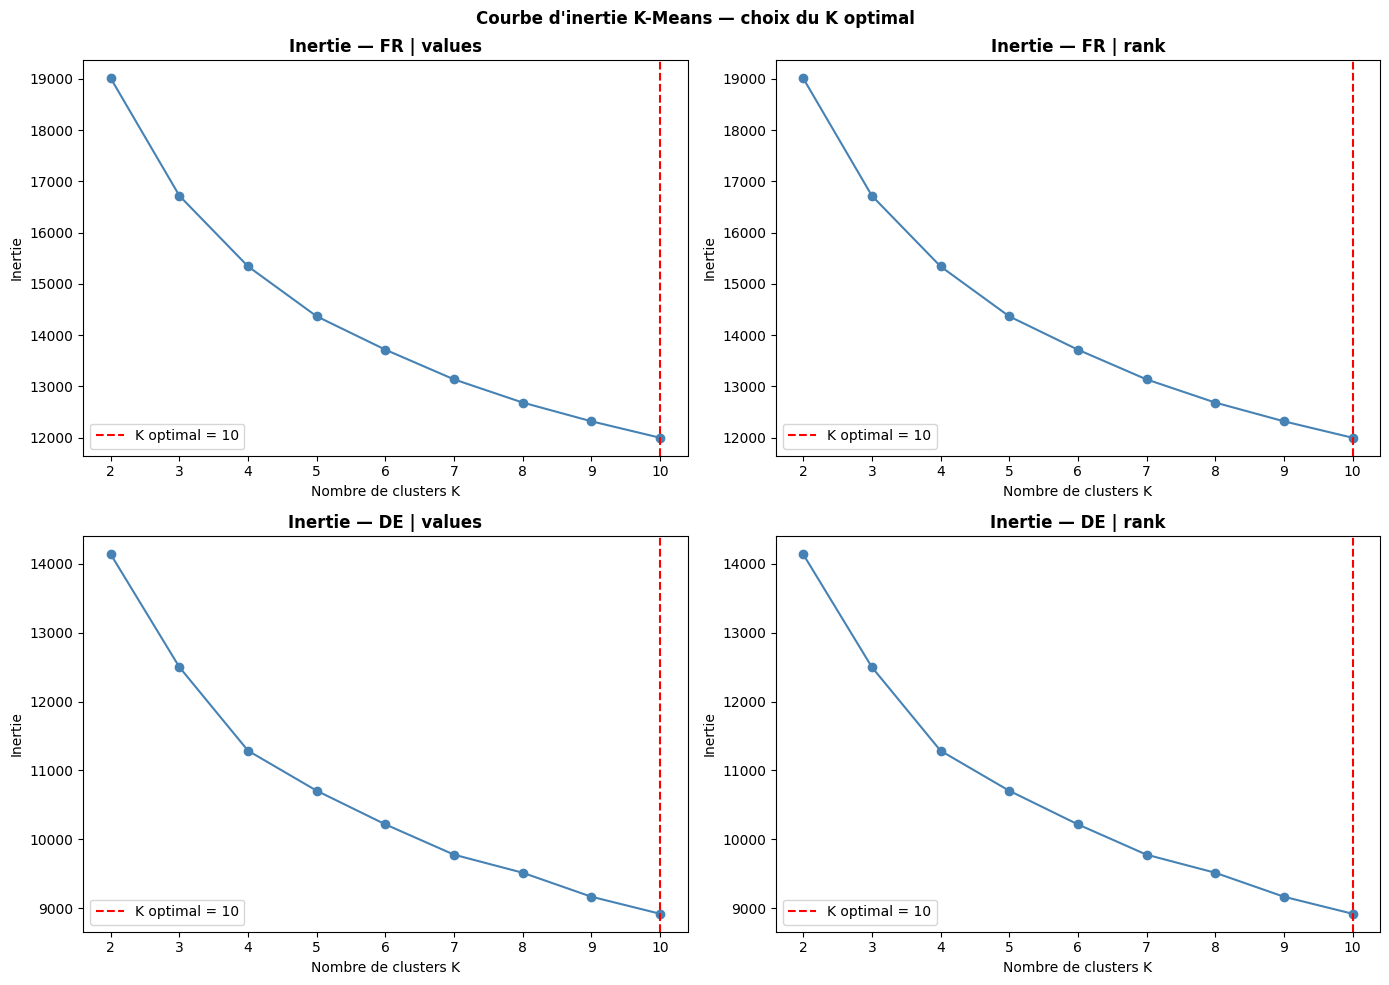


 RECAP DES K OPTIMAUX PAR PAYS x TARGET
  FR | values — K = 10
  FR | rank   — K = 10
  DE | values — K = 10
  DE | rank   — K = 10


In [89]:
# CLUSTERING K-MEANS — CALIBRATION PAR INERTIE

print("=" * 80)
print(" CLUSTERING K-MEANS — CALIBRATION PAR INERTIE — ETAPE 1 : CHOIX DU K")
print("=" * 80)

# On commence par calibrer K et visualiser les courbes d'inertie pour tous les
# pays x target avant de lancer les regressions. Cela permet de valider le K
# optimal visuellement avant de lancer un calcul potentiellement long.
results_clustering_inertie = {}
optimal_k_inertie          = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Courbe d'inertie K-Means — choix du K optimal", fontweight='bold')

for row, (country, X_tr, X_te, configs) in enumerate([
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]):
    optimal_k_inertie[country] = {}

    for col, (target_type, y_tr) in enumerate(configs):

        # On calibre K sur l'ensemble des features originales du pays pour
        # capturer la structure globale des donnees et non une vue partielle
        # liee a une methode de selection particuliere
        opt_k, inerties = calibrate_k_inertie(X_tr)
        optimal_k_inertie[country][target_type] = opt_k

        print(f"  {country} | {target_type} — K optimal = {opt_k}")

        # Visualisation de la courbe d'inertie avec le coude identifie
        ax = axes[row][col]
        ax.plot(K_RANGE, inerties, marker='o', color='steelblue')
        ax.axvline(opt_k, color='red', linestyle='--', label=f'K optimal = {opt_k}')
        ax.set_title(f'Inertie — {country} | {target_type}', fontweight='bold')
        ax.set_xlabel('Nombre de clusters K')
        ax.set_ylabel('Inertie')
        ax.legend()

plt.tight_layout()
plt.show()

# On affiche un recap des K optimaux avant de lancer les regressions pour
# permettre a l'utilisateur de valider les choix avant le calcul long
print(f"\n{'='*80}")
print(" RECAP DES K OPTIMAUX PAR PAYS x TARGET")
print(f"{'='*80}")
for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        print(f"  {country} | {target_type:6s} — K = {optimal_k_inertie[country][target_type]}")

### 6.2 Clustering par silhouette

In [90]:
from sklearn.metrics import silhouette_score

def calibrate_k_silhouette(X_tr, k_range=K_RANGE):
    """
    Calibre le nombre de clusters K par maximisation du score de silhouette.
    Contrairement a l'inertie qui decroit toujours, le score de silhouette
    a un maximum naturel qui identifie le K optimal sans ambiguïte.
    Un score eleve signifie que les clusters sont denses et bien separes.
    Retourne le K optimal et la courbe de scores de silhouette.
    """
    silhouette_scores = []

    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = km.fit_predict(X_tr)

        # Le score de silhouette necessite au moins 2 clusters et que
        # chaque cluster contienne au moins un point
        score = silhouette_score(X_tr, labels, metric='euclidean',
                                 sample_size=min(500, len(X_tr)),
                                 random_state=SEED)
        silhouette_scores.append(score)
        print(f"  K={k:2d} | silhouette={score:.4f}")

    opt_idx = int(np.argmax(silhouette_scores))
    opt_k   = k_range[opt_idx]

    return opt_k, silhouette_scores

 CLUSTERING K-MEANS — CALIBRATION PAR SILHOUETTE — ETAPE 1 : CHOIX DU K

 FR | values
  K= 2 | silhouette=0.1923
  K= 3 | silhouette=0.1958
  K= 4 | silhouette=0.1688
  K= 5 | silhouette=0.1442
  K= 6 | silhouette=0.1507
  K= 7 | silhouette=0.1363
  K= 8 | silhouette=0.1374
  K= 9 | silhouette=0.1390
  K=10 | silhouette=0.1380

  K optimal = 3 (silhouette=0.1958)

 FR | rank
  K= 2 | silhouette=0.1923
  K= 3 | silhouette=0.1958
  K= 4 | silhouette=0.1688
  K= 5 | silhouette=0.1442
  K= 6 | silhouette=0.1507
  K= 7 | silhouette=0.1363
  K= 8 | silhouette=0.1374
  K= 9 | silhouette=0.1390
  K=10 | silhouette=0.1380

  K optimal = 3 (silhouette=0.1958)

 DE | values
  K= 2 | silhouette=0.1948
  K= 3 | silhouette=0.1933
  K= 4 | silhouette=0.1658
  K= 5 | silhouette=0.1649
  K= 6 | silhouette=0.1611
  K= 7 | silhouette=0.1401
  K= 8 | silhouette=0.1267
  K= 9 | silhouette=0.1367
  K=10 | silhouette=0.1266

  K optimal = 2 (silhouette=0.1948)

 DE | rank
  K= 2 | silhouette=0.1948
  K= 3 | 

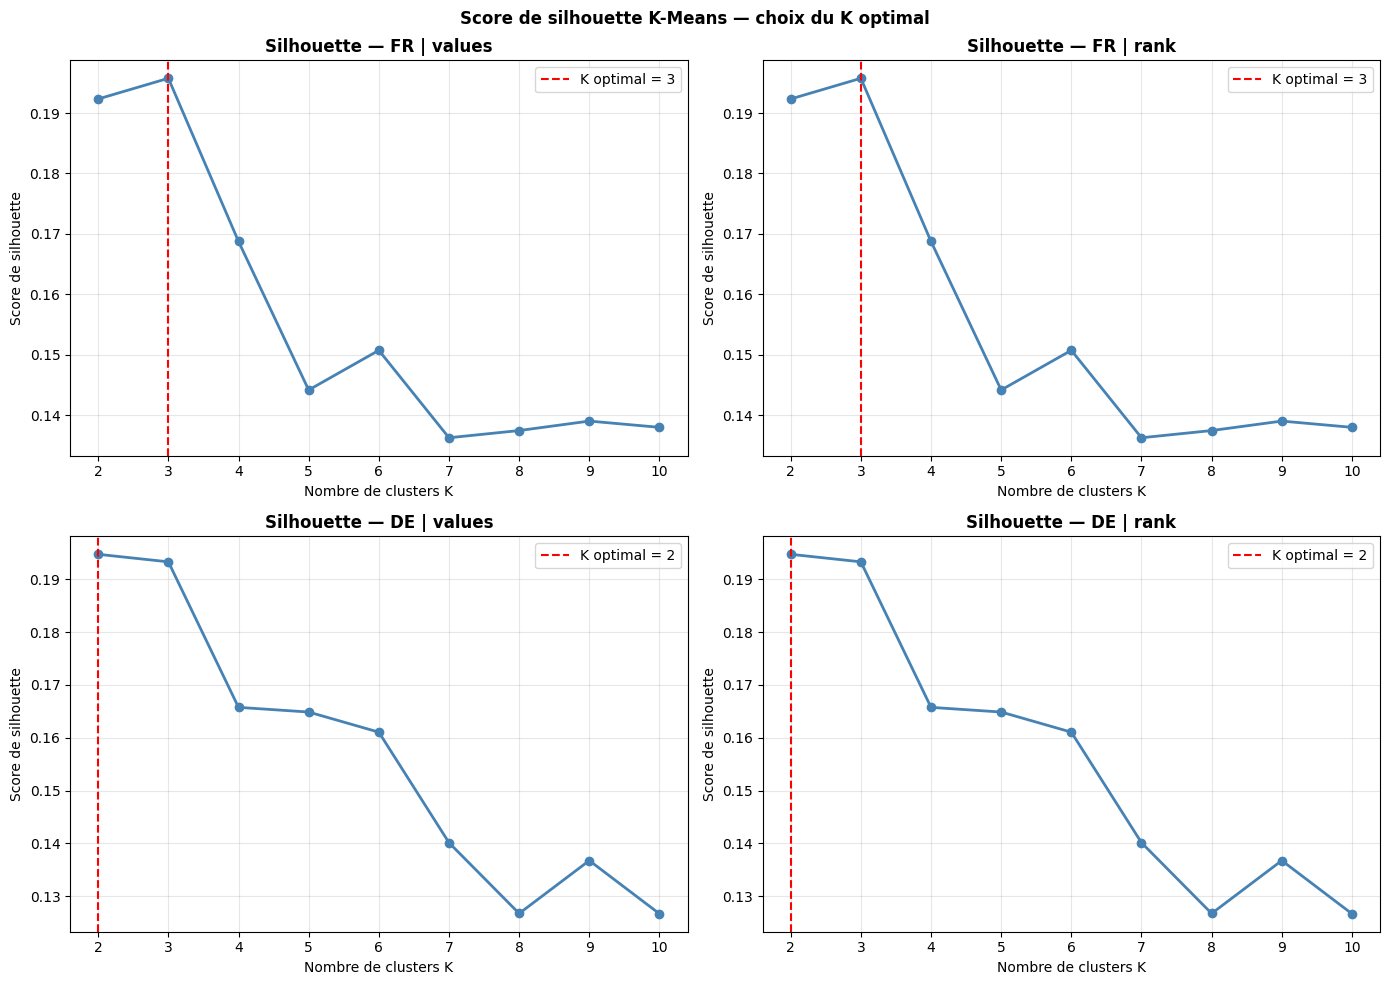


 RECAP DES K OPTIMAUX PAR PAYS x TARGET
  FR | values — K = 3
  FR | rank   — K = 3
  DE | values — K = 2
  DE | rank   — K = 2


In [91]:
print("=" * 80)
print(" CLUSTERING K-MEANS — CALIBRATION PAR SILHOUETTE — ETAPE 1 : CHOIX DU K")
print("=" * 80)

optimal_k_silhouette = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Score de silhouette K-Means — choix du K optimal", fontweight='bold')

for row, (country, X_tr, X_te, configs) in enumerate([
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]):
    optimal_k_silhouette[country] = {}

    for col, (target_type, y_tr) in enumerate(configs):

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        opt_k, sil_scores = calibrate_k_silhouette(X_tr)
        optimal_k_silhouette[country][target_type] = opt_k

        print(f"\n  K optimal = {opt_k} (silhouette={sil_scores[opt_k - K_RANGE[0]]:.4f})")

        ax = axes[row][col]
        ax.plot(K_RANGE, sil_scores, marker='o', color='steelblue', linewidth=2)
        ax.axvline(opt_k, color='red', linestyle='--',
                   label=f'K optimal = {opt_k}')
        ax.set_title(f'Silhouette — {country} | {target_type}', fontweight='bold')
        ax.set_xlabel('Nombre de clusters K')
        ax.set_ylabel('Score de silhouette')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(" RECAP DES K OPTIMAUX PAR PAYS x TARGET")
print(f"{'='*80}")
for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        print(f"  {country} | {target_type:6s} — K = {optimal_k_silhouette[country][target_type]}")

### 6.3 Clustering par cross validation

In [92]:
def calibrate_k_cv(X_tr, y_tr, k_range=K_RANGE):
    """
    Calibre le nombre de clusters K par methode du coude sur le Spearman CV.
    On calibre sur l'ensemble des features du pays — le clustering capture
    la structure globale des donnees et non une vue partielle liee a une
    methode de selection particuliere.
    Pour chaque K on recalcule le K-Means sur chaque fold train et on assigne
    les clusters du fold validation par proximite au centroide.
    Retourne le K optimal et la courbe de scores CV.
    """
    kf     = KFold(n_splits=3, shuffle=True, random_state=SEED)
    res_cv = []

    for k in k_range:
        sp_folds = []
        for tr_idx, val_idx in kf.split(X_tr):
            Xtr_fold  = X_tr.iloc[tr_idx]
            Xval_fold = X_tr.iloc[val_idx]
            ytr_fold  = y_tr.iloc[tr_idx]
            yval_fold = y_tr.iloc[val_idx]

            # On recalcule le K-Means sur le fold train uniquement pour eviter
            # le leakage — les centroides du fold train sont utilises pour
            # assigner les clusters du fold validation
            km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
            km.fit(Xtr_fold)

            ohe_tr  = pd.get_dummies(km.labels_, prefix='cluster').astype(float)
            ohe_val = pd.get_dummies(km.predict(Xval_fold), prefix='cluster').astype(float)
            ohe_tr, ohe_val = ohe_tr.align(ohe_val, join='left', axis=1, fill_value=0)

            ohe_tr.index  = Xtr_fold.index
            ohe_val.index = Xval_fold.index

            # On evalue l'utilite du clustering en ajoutant le one-hot cluster
            # a toutes les features et en entrainant un Ridge dessus
            Xtr_clust  = pd.concat([Xtr_fold, ohe_tr], axis=1)
            Xval_clust = pd.concat([Xval_fold, ohe_val], axis=1)

            ridge_cv = RidgeCV(alphas=np.logspace(-6, 6, 50), cv=3,
                               scoring=spearman_metric)
            ridge_cv.fit(Xtr_clust, ytr_fold)
            ridge = Ridge(alpha=ridge_cv.alpha_)
            ridge.fit(Xtr_clust, ytr_fold)
            sp_folds.append(spearmanr(yval_fold, ridge.predict(Xval_clust)).correlation)

        res_cv.append({'k': k, 'spearman_mean': np.mean(sp_folds)})

    res_df  = pd.DataFrame(res_cv)
    opt_idx = elbow_threshold(res_df['spearman_mean'].values)
    opt_k   = res_df['k'].iloc[opt_idx]

    return opt_k, res_df['spearman_mean'].values

 CLUSTERING K-MEANS — CALIBRATION PAR SCORE CV — ETAPE 1 : CHOIX DU K

  FR | values — calibration K par score CV
  K optimal = 2

  FR | rank — calibration K par score CV
  K optimal = 10

  DE | values — calibration K par score CV
  K optimal = 10

  DE | rank — calibration K par score CV
  K optimal = 9


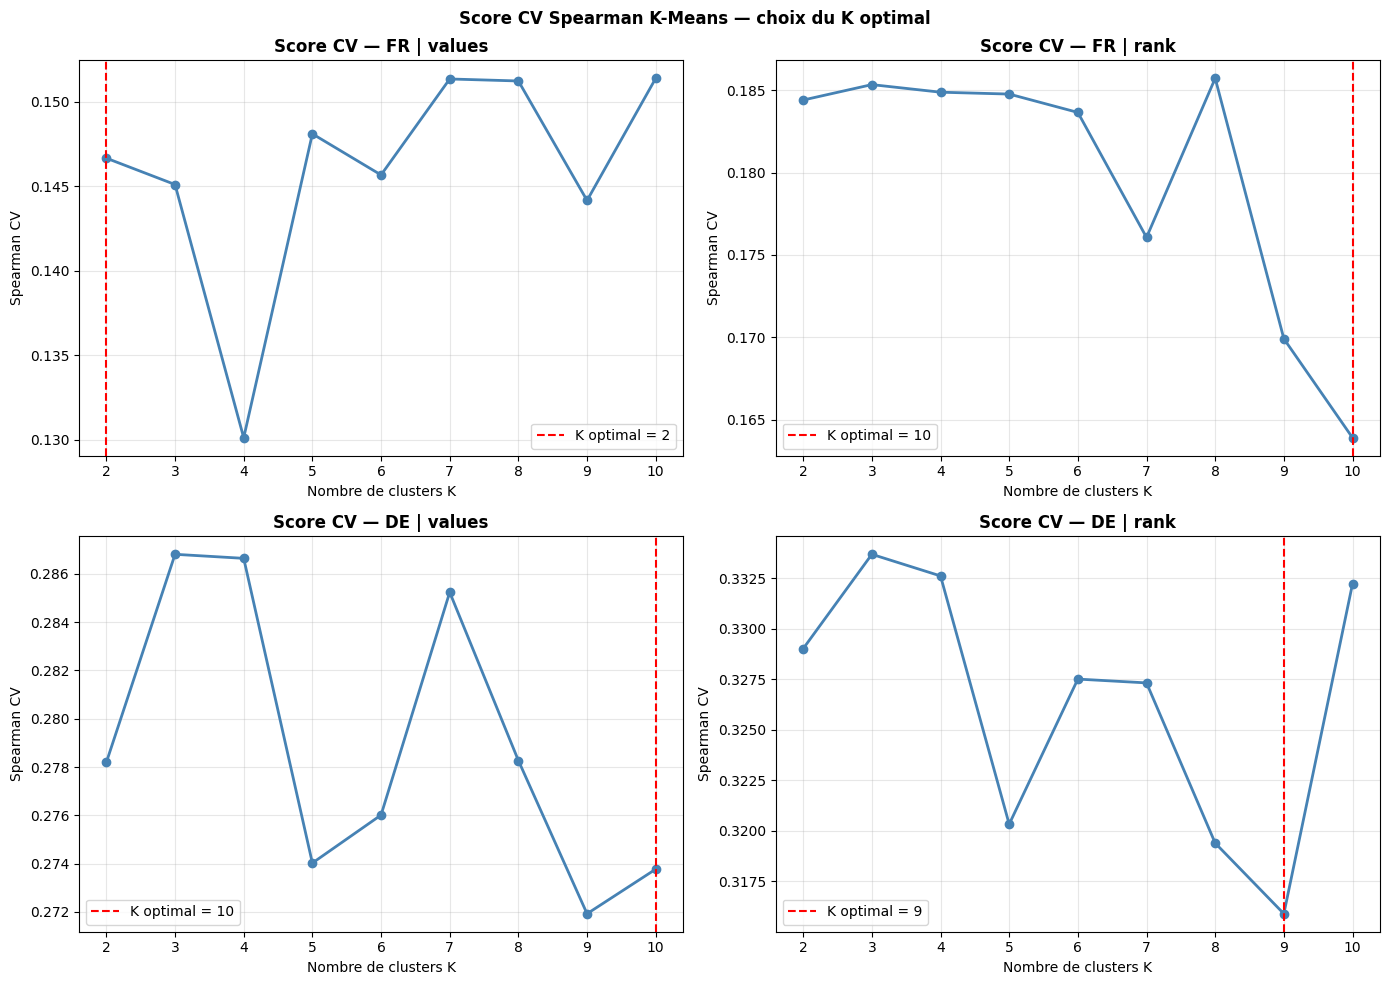


 RECAP DES K OPTIMAUX PAR PAYS x TARGET
  FR | values — K = 2
  FR | rank   — K = 10
  DE | values — K = 10
  DE | rank   — K = 9


In [93]:
print("=" * 80)
print(" CLUSTERING K-MEANS — CALIBRATION PAR SCORE CV — ETAPE 1 : CHOIX DU K")
print("=" * 80)

optimal_k_cv          = {}
scores_cv_by_country  = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Score CV Spearman K-Means — choix du K optimal", fontweight='bold')

for row, (country, X_tr, configs) in enumerate([
    ('FR', x_train_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, [('values', y_de_values), ('rank', y_de_rank)]),
]):
    optimal_k_cv[country]         = {}
    scores_cv_by_country[country] = {}

    for col, (target_type, y_tr) in enumerate(configs):

        print(f"\n  {country} | {target_type} — calibration K par score CV")

        # On calibre sur l'ensemble des features du pays — une seule calibration
        # par pays x target reutilisee pour toutes les methodes de selection
        opt_k, cv_scores = calibrate_k_cv(X_tr, y_tr)
        optimal_k_cv[country][target_type]         = opt_k
        scores_cv_by_country[country][target_type] = cv_scores

        print(f"  K optimal = {opt_k}")

        ax = axes[row][col]
        ax.plot(K_RANGE, cv_scores, marker='o', color='steelblue', linewidth=2)
        ax.axvline(opt_k, color='red', linestyle='--', label=f'K optimal = {opt_k}')
        ax.set_title(f'Score CV — {country} | {target_type}', fontweight='bold')
        ax.set_xlabel('Nombre de clusters K')
        ax.set_ylabel('Spearman CV')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(" RECAP DES K OPTIMAUX PAR PAYS x TARGET")
print(f"{'='*80}")
for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        print(f"  {country} | {target_type:6s} — K = {optimal_k_cv[country][target_type]}")

### 6.4 Choix final du nombre de clusters 

#### Strategie de clustering — exploration exhaustive de K=2 a 5

##### Pourquoi la calibration automatique du K est difficile ici

Comme le montrent les graphiques precedents, les trois methodes classiques de calibration
du nombre de clusters se heurtent chacune a des limitations sur nos donnees :

- **L'inertie** decroit de maniere reguliere et continue sans jamais presenter de coude net,
  quelle que soit la plage de K testee. La methode de Kneedle identifie systematiquement
  le dernier point de la grille comme optimal, ce qui n'est pas exploitable.

- **Le score de silhouette** donne un signal plus clair (K=3 pour la France, K=2 pour
  l'Allemagne) mais reste modere en valeur absolue (autour de 0.19-0.20), ce qui indique
  que les clusters ne sont pas tres bien separes. Les frontieres entre regimes energetiques
  sont floues, ce qui est attendu sur des donnees de marche.

- **La calibration par score CV** produit des courbes trop bruitees pour etre fiables —
  avec seulement 3 folds et environ 250 observations par fold, la variance entre folds
  est trop elevee pour identifier un K optimal stable.

Ces difficultes ne sont pas surprenantes : nos donnees ne presentent pas de structure en
clusters bien definie et bien separee. Les regimes energetiques se chevauchent et evoluent
graduellement, sans rupture franche. Dans ce contexte, chercher un K optimal theorique
est une question mal posee.

---

##### Approche retenue : exploration exhaustive et selection par CV

Plutot que de chercher le K optimal de maniere theorique, on adopte une approche empirique
et exhaustive : on teste tous les K de 2 a 5 et on laisse la cross-validation choisir.

Pour chaque valeur de K on entraine un K-Means sur les donnees d'entrainement, on encode
les labels de cluster en one-hot et on les ajoute aux features selectionnees par chaque
methode de selection. On entraine ensuite les quatre modeles lineaires (OLS, Ridge, Lasso,
ElasticNet) sur chaque combinaison pays x target x methode de selection, ce qui represente
au total :

$$4 \text{ (valeurs de K)} \times 4 \text{ (modeles)} \times 9 \text{ (methodes)} \times 4 \text{ (pays x target)} = 576 \text{ modeles}$$

Pour chaque K et chaque pays x target, on retient le meilleur score CV obtenu toutes
methodes et tous modeles confondus. Le K optimal retenu est celui qui maximise ce meilleur
score CV — c'est-a-dire le K pour lequel le clustering est le plus utile pour la prediction,
independamment du modele ou de la methode de selection utilisee.

Cette approche presente plusieurs avantages par rapport a la calibration theorique :

- Elle optimise directement l'objectif final (le score Spearman en CV) plutot qu'un
  critere geometrique (inertie, silhouette) qui peut etre deconnecte de la performance
  predictive.
- Elle est robuste au bruit — meme si un K particulier donne un mauvais score pour
  certaines methodes de selection, il sera penalise dans la comparaison finale.
- Elle est entierement reproductible grace au cache JSON qui evite de recalculer les
  modeles deja entraines lors d'une nouvelle execution du notebook.

Le K retenu est ensuite utilise pour mettre a jour le dictionnaire `best_linear` global,
qui suit le meilleur modele toutes variantes confondues (simple, poly, cluster) pour
chaque pays x target.

In [94]:
# On charge le cache pour eviter de refaire tourner les modeles deja calcules
cache = load_results_cache()

K_RANGE_CLUSTER = range(2, 6)  # K de 2 a 5

print("=" * 80)
print(" CLUSTERING K-MEANS — EXPLORATION K=2 A 5")
print("=" * 80)

# Ce dictionnaire stocke pour chaque K x pays x target x methode x modele
# le score CV obtenu — on s'en servira ensuite pour identifier le meilleur K
scores_by_k = {}

# Ce dictionnaire stocke les predictions test pour chaque combinaison
# afin de pouvoir sauvegarder la soumission du meilleur K sans recalculer
preds_by_k = {}

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    scores_by_k[country] = {}
    preds_by_k[country]  = {}

    for target_type, y_tr in configs:
        scores_by_k[country][target_type] = {}
        preds_by_k[country][target_type]  = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for k in K_RANGE_CLUSTER:
            scores_by_k[country][target_type][k] = {}
            preds_by_k[country][target_type][k]  = {}

            print(f"\n  >> K = {k}")

            for methode, feats in selected_features_linear[country][target_type].items():

                # On entraine le K-Means sur l'ensemble du train pour ce K
                # et on ajoute le one-hot cluster aux features selectionnees
                X_tr_clust, X_te_clust = get_cluster_features_inertie(
                    X_tr[feats], X_te[feats], k)

                scores_by_k[country][target_type][k][methode] = {}
                preds_by_k[country][target_type][k][methode]  = {}

                # ── OLS ───────────────────────────────────────────────────
                cache_key = f'OLS_cluster_k{k}'
                if is_cached(cache, cache_key, country, target_type, methode):
                    cached        = get_cached(cache, cache_key, country, target_type, methode)
                    s_cv, s_tr    = cached['score_cv'], cached['score_train']
                    model         = LinearRegression()
                    model.fit(X_tr_clust, y_tr)
                    print(f"     OLS   | K={k} | {methode:20s} | [CACHE] CV={s_cv:.4f}")
                else:
                    model         = LinearRegression()
                    s_cv, s_tr, _ = fit_eval(model, X_tr_clust, y_tr,
                                             f"OLS K={k} {country} {target_type} | {methode}")
                    model.fit(X_tr_clust, y_tr)
                    set_cached(cache, cache_key, country, target_type, methode,
                               s_cv, s_tr, {})
                    save_results_cache(cache)

                scores_by_k[country][target_type][k][methode]['OLS'] = s_cv
                preds_by_k[country][target_type][k][methode]['OLS']  = model.predict(X_te_clust)

                pd.DataFrame({'ID': X_te.index, 'TARGET': model.predict(X_te_clust)}).to_csv(
                    f'submissions/linear/OLS/OLS_cluster_k{k}_{country}_{target_type}_{methode}.csv',
                    index=False)

                # ── Ridge ─────────────────────────────────────────────────
                cache_key = f'Ridge_cluster_k{k}'
                if is_cached(cache, cache_key, country, target_type, methode):
                    cached        = get_cached(cache, cache_key, country, target_type, methode)
                    s_cv, s_tr    = cached['score_cv'], cached['score_train']
                    opt_alpha     = cached['params']['alpha']
                    model         = Ridge(alpha=opt_alpha)
                    model.fit(X_tr_clust, y_tr)
                    print(f"     Ridge | K={k} | {methode:20s} | [CACHE] CV={s_cv:.4f}")
                else:
                    ridge_cv  = RidgeCV(alphas=np.logspace(-6, 6, 200), cv=5,
                                        scoring=spearman_metric)
                    ridge_cv.fit(X_tr_clust, y_tr)
                    opt_alpha     = ridge_cv.alpha_
                    model         = Ridge(alpha=opt_alpha)
                    s_cv, s_tr, _ = fit_eval(model, X_tr_clust, y_tr,
                                             f"Ridge K={k} {country} {target_type} | {methode}")
                    model.fit(X_tr_clust, y_tr)
                    set_cached(cache, cache_key, country, target_type, methode,
                               s_cv, s_tr, {'alpha': opt_alpha})
                    save_results_cache(cache)

                scores_by_k[country][target_type][k][methode]['Ridge'] = s_cv
                preds_by_k[country][target_type][k][methode]['Ridge']  = model.predict(X_te_clust)

                pd.DataFrame({'ID': X_te.index, 'TARGET': model.predict(X_te_clust)}).to_csv(
                    f'submissions/linear/Ridge/Ridge_cluster_k{k}_{country}_{target_type}_{methode}.csv',
                    index=False)

                # ── Lasso ─────────────────────────────────────────────────
                cache_key = f'Lasso_cluster_k{k}'
                if is_cached(cache, cache_key, country, target_type, methode):
                    cached        = get_cached(cache, cache_key, country, target_type, methode)
                    s_cv, s_tr    = cached['score_cv'], cached['score_train']
                    opt_alpha     = cached['params']['alpha']
                    model         = Lasso(alpha=opt_alpha, max_iter=10000)
                    model.fit(X_tr_clust, y_tr)
                    print(f"     Lasso | K={k} | {methode:20s} | [CACHE] CV={s_cv:.4f}")
                else:
                    lasso_cv  = LassoCV(cv=5, max_iter=10000, random_state=SEED, n_jobs=-1)
                    lasso_cv.fit(X_tr_clust, y_tr)
                    opt_alpha     = lasso_cv.alpha_
                    model         = Lasso(alpha=opt_alpha, max_iter=10000)
                    s_cv, s_tr, _ = fit_eval(model, X_tr_clust, y_tr,
                                             f"Lasso K={k} {country} {target_type} | {methode}")
                    model.fit(X_tr_clust, y_tr)
                    set_cached(cache, cache_key, country, target_type, methode,
                               s_cv, s_tr, {'alpha': opt_alpha})
                    save_results_cache(cache)

                scores_by_k[country][target_type][k][methode]['Lasso'] = s_cv
                preds_by_k[country][target_type][k][methode]['Lasso']  = model.predict(X_te_clust)

                pd.DataFrame({'ID': X_te.index, 'TARGET': model.predict(X_te_clust)}).to_csv(
                    f'submissions/linear/Lasso/Lasso_cluster_k{k}_{country}_{target_type}_{methode}.csv',
                    index=False)

                # ── ElasticNet ────────────────────────────────────────────
                cache_key = f'ElasticNet_cluster_k{k}'
                if is_cached(cache, cache_key, country, target_type, methode):
                    cached        = get_cached(cache, cache_key, country, target_type, methode)
                    s_cv, s_tr    = cached['score_cv'], cached['score_train']
                    opt_alpha     = cached['params']['alpha']
                    opt_l1        = cached['params']['l1_ratio']
                    model         = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                    model.fit(X_tr_clust, y_tr)
                    print(f"     EN   | K={k} | {methode:20s} | [CACHE] CV={s_cv:.4f}")
                else:
                    enet_cv   = ElasticNetCV(l1_ratio=L1_RATIOS, cv=5,
                                             max_iter=10000, random_state=SEED, n_jobs=-1)
                    enet_cv.fit(X_tr_clust, y_tr)
                    opt_alpha     = enet_cv.alpha_
                    opt_l1        = enet_cv.l1_ratio_
                    model         = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                    s_cv, s_tr, _ = fit_eval(model, X_tr_clust, y_tr,
                                             f"ElasticNet K={k} {country} {target_type} | {methode}")
                    model.fit(X_tr_clust, y_tr)
                    set_cached(cache, cache_key, country, target_type, methode,
                               s_cv, s_tr, {'alpha': opt_alpha, 'l1_ratio': opt_l1})
                    save_results_cache(cache)

                scores_by_k[country][target_type][k][methode]['ElasticNet'] = s_cv
                preds_by_k[country][target_type][k][methode]['ElasticNet']  = model.predict(X_te_clust)

                pd.DataFrame({'ID': X_te.index, 'TARGET': model.predict(X_te_clust)}).to_csv(
                    f'submissions/linear/ElasticNet/ElasticNet_cluster_k{k}_{country}_{target_type}_{methode}.csv',
                    index=False)

# ── Selection du meilleur K par pays x target ─────────────────────────────────
# Pour chaque K on prend le meilleur score CV parmi tous les modeles x methodes
# et on retient le K qui maximise ce meilleur score
print(f"\n{'='*80}")
print(" SELECTION DU MEILLEUR K PAR PAYS x TARGET")
print(f"{'='*80}")

optimal_k_cluster = {}

for country in ['FR', 'DE']:
    optimal_k_cluster[country] = {}
    for target_type in ['values', 'rank']:
        print(f"\n  {country} | {target_type}")

        best_score_by_k = {}
        for k in K_RANGE_CLUSTER:
            # On prend le meilleur score CV toutes methodes x modeles confondus
            # pour ce K — c'est ce meilleur score qui caracterise la qualite du K
            scores_k = [
                scores_by_k[country][target_type][k][methode][model_name]
                for methode in selected_features_linear[country][target_type].keys()
                for model_name in ['OLS', 'Ridge', 'Lasso', 'ElasticNet']
            ]
            best_score_by_k[k] = max(scores_k)
            print(f"    K={k} | meilleur score CV = {best_score_by_k[k]:.4f}")

        opt_k = max(best_score_by_k, key=best_score_by_k.get)
        optimal_k_cluster[country][target_type] = opt_k
        print(f"  => K optimal retenu = {opt_k} (score={best_score_by_k[opt_k]:.4f})")

# ── Mise a jour du best_linear avec le meilleur K retenu ─────────────────────
# On parcourt toutes les combinaisons du K optimal et on met a jour best_linear
print(f"\n{'='*80}")
print(" MISE A JOUR DU BEST LINEAR AVEC LE MEILLEUR CLUSTER")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        opt_k = optimal_k_cluster[country][target_type]

        for methode in selected_features_linear[country][target_type].keys():
            for model_name in ['OLS', 'Ridge', 'Lasso', 'ElasticNet']:
                s_cv  = scores_by_k[country][target_type][opt_k][methode][model_name]
                preds = preds_by_k[country][target_type][opt_k][methode][model_name]

                if s_cv > best_linear[country][target_type]['score']:
                    best_linear[country][target_type].update({
                        'score':   s_cv,
                        'model':   f'{model_name}_cluster_k{opt_k}',
                        'methode': methode,
                        'preds':   preds
                    })

        best = best_linear[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/linear/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:30s} | "
              f"methode={best['methode']:20s} | CV={best['score']:.4f}")

 CLUSTERING K-MEANS — EXPLORATION K=2 A 5

 FR | values

  >> K = 2
     OLS   | K=2 | vif                  | [CACHE] CV=0.1771
     Ridge | K=2 | vif                  | [CACHE] CV=0.1476
     Lasso | K=2 | vif                  | [CACHE] CV=0.1268
     EN   | K=2 | vif                  | [CACHE] CV=0.1217
     OLS   | K=2 | mdi                  | [CACHE] CV=0.1569
     Ridge | K=2 | mdi                  | [CACHE] CV=0.1702
     Lasso | K=2 | mdi                  | [CACHE] CV=0.1253
     EN   | K=2 | mdi                  | [CACHE] CV=0.1440
     OLS   | K=2 | perm                 | [CACHE] CV=0.0866
     Ridge | K=2 | perm                 | [CACHE] CV=0.0867
     Lasso | K=2 | perm                 | [CACHE] CV=0.0873
     EN   | K=2 | perm                 | [CACHE] CV=0.0878
     OLS   | K=2 | shap                 | [CACHE] CV=0.1770
     Ridge | K=2 | shap                 | [CACHE] CV=0.1860
     Lasso | K=2 | shap                 | [CACHE] CV=0.1259
     EN   | K=2 | shap             

#### 6.4.1 Affichage des parametres des modeles retenus

In [95]:
print("=" * 80)
print(" PARAMETRES DES MEILLEURS MODELES LINEAIRES")
print("=" * 80)

for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        best      = best_linear[country][target_type]
        model_key = best['model'].split('_cluster')[0] if 'cluster' in best['model'] else best['model']
        methode   = best['methode']

        print(f"\n  {country} | {target_type}")
        print(f"    Modele  : {best['model']}")
        print(f"    Methode : {methode}")
        print(f"    Score   : {best['score']:.4f}")

        if model_key in results and country in results.get(model_key, {}):
            entry  = results[model_key][country][target_type][methode]
            params = entry.get('params', {})
            feats  = entry.get('features', [])
            print(f"    Params  : {params}")
            print(f"    Nb features : {len(feats)}")
            print(f"    Features : {feats}")
        else:
            # Le modele est un cluster — on recupere depuis le cache JSON
            cached = get_cached(cache, best['model'], country, target_type, methode)
            if cached:
                print(f"    Params  : {cached.get('params', {})}")
            print(f"    [modele avec cluster — features dans preds_by_k]")

 PARAMETRES DES MEILLEURS MODELES LINEAIRES

  FR | values
    Modele  : ElasticNet
    Methode : shap
    Score   : 0.1900
    Params  : {'alpha': 0.021786990590891946, 'l1_ratio': 0.1}
    Nb features : 18
    Features : ['DE_CONSUMPTION', 'FR_CONSUMPTION', 'DE_FR_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT', 'FR_GAS', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR', 'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'FR_WIND', 'MARGINAL_GAS']

  FR | rank
    Modele  : Ridge_cluster_k5
    Methode : rfe_ridge
    Score   : 0.2253
    Params  : {'alpha': 138.26221737646534}
    Nb features : 18
    Features : ['DE_CONSUMPTION', 'FR_CONSUMPTION', 'DE_FR_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT', 'DE_GAS', 'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR', 'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_WIND', 'MARGINAL_GAS', 'MARGINAL_COAL']

  DE | values
    Modele  : Ridge_cluster_k4
    Methode : vif_rfe_ridge
    Sc

### 6.5 Amelioration des modeles lineaires

#### 6.5.1 Ajout de feature comme des bruits 

In [96]:
# FEATURE ENGINEERING — FEATURES NON SELECTIONNEES AVEC BRUIT

# On ajoute les features eliminees par la selection en les bruitant avec un
# bruit gaussien calibre. L'intensite du bruit est alpha * std(feature).
# Un alpha trop faible laisse trop de signal dans les features eliminees,
# un alpha trop fort les rend inutilisables. On calibre alpha par methode
# du coude sur Spearman CV pour trouver le bon compromis.

ALPHAS_BRUIT = np.arange(0.1, 2.1, 0.1)  # on teste de 0.1 a 2.0

def add_noisy_features(X_tr, X_te, feats_selected, all_feats, alpha, seed=SEED):
    """
    Ajoute les features non selectionnees avec un bruit gaussien calibre.
    Le bruit est ajoute uniquement sur X_tr — sur X_te on ajoute aussi le bruit
    car le modele doit generaliser avec ces features bruitees.
    L'ecart-type du bruit est alpha * std(feature) calcule sur X_tr uniquement
    pour eviter le leakage.
    Retourne (X_tr_enrichi, X_te_enrichi).
    """
    feats_non_selectionnees = [f for f in all_feats if f not in feats_selected]

    if len(feats_non_selectionnees) == 0:
        return X_tr[feats_selected].copy(), X_te[feats_selected].copy()

    rng = np.random.RandomState(seed)

    X_tr_out = X_tr[feats_selected].copy()
    X_te_out = X_te[feats_selected].copy()

    for feat in feats_non_selectionnees:
        # On calcule l'ecart-type sur le train uniquement pour eviter le leakage
        sigma = alpha * X_tr[feat].std()

        # On ajoute le bruit sur train et test
        noise_tr = rng.normal(0, sigma, size=len(X_tr))
        noise_te = rng.normal(0, sigma, size=len(X_te))

        X_tr_out[f'{feat}_noisy'] = X_tr[feat].values + noise_tr
        X_te_out[f'{feat}_noisy'] = X_te[feat].values + noise_te

    return X_tr_out, X_te_out


def calibrate_alpha_bruit(X_tr, y_tr, feats_selected, all_feats,
                           estimator, alphas=ALPHAS_BRUIT, label=''):
    """
    Calibre l'intensite du bruit alpha par methode du coude sur Spearman CV.
    Pour chaque alpha on genere les features bruitees et on evalue en CV.
    Le coude de la courbe Spearman = f(alpha) donne l'alpha optimal.
    Retourne l'alpha optimal et la courbe de scores CV.
    """
    from sklearn.base import clone

    kf     = KFold(n_splits=5, shuffle=True, random_state=SEED)
    res_cv = []

    for alpha in alphas:
        sp_folds = []
        for tr_idx, val_idx in kf.split(X_tr):
            Xtr_fold = X_tr.iloc[tr_idx]
            Xval_fold = X_tr.iloc[val_idx]
            ytr_fold  = y_tr.iloc[tr_idx]
            yval_fold = y_tr.iloc[val_idx]

            # On genere les features bruitees sur le fold train uniquement
            # pour eviter le leakage — le bruit du val est genere separement
            Xtr_noisy, Xval_noisy = add_noisy_features(
                Xtr_fold, Xval_fold, feats_selected, all_feats, alpha)

            try:
                m = clone(estimator)
                m.fit(Xtr_noisy, ytr_fold)
                sp = spearmanr(yval_fold, m.predict(Xval_noisy)).correlation
                if not np.isnan(sp):
                    sp_folds.append(sp)
            except Exception:
                pass

        if len(sp_folds) > 0:
            res_cv.append({'alpha': alpha, 'spearman_mean': np.mean(sp_folds)})
        else:
            res_cv.append({'alpha': alpha, 'spearman_mean': -np.inf})

    res_df  = pd.DataFrame(res_cv)
    opt_idx = elbow_threshold(res_df['spearman_mean'].values)
    opt_a   = res_df['alpha'].iloc[opt_idx]

    if label:
        print(f"     Alpha optimal = {opt_a:.1f} | "
              f"Score CV = {res_df['spearman_mean'].iloc[opt_idx]:.4f}")

    return opt_a, res_df['spearman_mean'].values


# ── Toutes les features disponibles par pays ──────────────────────────────────
# Ce sont les features originales avant toute selection
all_feats_fr = list(x_train_fr.columns)
all_feats_de = list(x_train_de.columns)

# ── Calibration de alpha et generation des datasets enrichis ──────────────────
print("=" * 80)
print(" CALIBRATION DE L'INTENSITE DU BRUIT PAR PAYS x TARGET x METHODE")
print("=" * 80)

# On stocke les datasets enrichis et les alphas optimaux
X_train_noisy_linear   = {}
X_test_noisy_linear    = {}
X_train_noisy_ensemble = {}
X_test_noisy_ensemble  = {}
optimal_alpha_bruit    = {}

for country, X_tr, X_te, configs, all_feats in [
    ('FR', x_train_fr, x_test_fr,
     [('values', y_fr_values), ('rank', y_fr_rank)], all_feats_fr),
    ('DE', x_train_de, x_test_de,
     [('values', y_de_values), ('rank', y_de_rank)], all_feats_de),
]:
    X_train_noisy_linear[country]   = {}
    X_test_noisy_linear[country]    = {}
    X_train_noisy_ensemble[country] = {}
    X_test_noisy_ensemble[country]  = {}
    optimal_alpha_bruit[country]    = {}

    for target_type, y_tr in configs:
        X_train_noisy_linear[country][target_type]   = {}
        X_test_noisy_linear[country][target_type]    = {}
        X_train_noisy_ensemble[country][target_type] = {}
        X_test_noisy_ensemble[country][target_type]  = {}
        optimal_alpha_bruit[country][target_type]    = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        # ── Calibration pour les modeles lineaires ────────────────────────
        print(f"\n  -- Modeles lineaires --")
        for methode, feats in selected_features_linear[country][target_type].items():
            feats_non_sel = [f for f in all_feats if f not in feats]
            if len(feats_non_sel) == 0:
                print(f"  {methode:20s} | Aucune feature non selectionnee")
                continue

            print(f"\n  {methode:20s} | {len(feats)} selectionnees | "
                  f"{len(feats_non_sel)} non selectionnees")

            # On utilise Ridge comme estimateur de reference pour la calibration
            # car c'est le modele lineaire le plus stable
            opt_alpha, _ = calibrate_alpha_bruit(
                X_tr, y_tr, feats, all_feats,
                estimator=Ridge(),
                label=f"  {country} | {target_type} | {methode} | lineaire"
            )

            optimal_alpha_bruit[country][target_type][f'linear_{methode}'] = float(opt_alpha)

            # Generation du dataset enrichi avec l'alpha optimal
            X_tr_noisy, X_te_noisy = add_noisy_features(
                X_tr, X_te, feats, all_feats, opt_alpha)

            X_train_noisy_linear[country][target_type][methode] = X_tr_noisy
            X_test_noisy_linear[country][target_type][methode]  = X_te_noisy

            print(f"     {len(feats)} features originales + "
                  f"{X_tr_noisy.shape[1] - len(feats)} features bruitees = "
                  f"{X_tr_noisy.shape[1]} total")

        # ── Calibration pour les modeles ensemblistes ─────────────────────
        print(f"\n  -- Modeles ensemblistes --")
        for methode, feats in selected_features_ensemble[country][target_type].items():
            feats_non_sel = [f for f in all_feats if f not in feats]
            if len(feats_non_sel) == 0:
                print(f"  {methode:20s} | Aucune feature non selectionnee")
                continue

            print(f"\n  {methode:20s} | {len(feats)} selectionnees | "
                  f"{len(feats_non_sel)} non selectionnees")

            # On utilise LightGBM MAE comme estimateur de reference
            opt_alpha, _ = calibrate_alpha_bruit(
                X_tr, y_tr, feats, all_feats,
                estimator=lgb.LGBMRegressor(
                    n_estimators=100, objective='regression_l1',
                    random_state=SEED, verbosity=-1, n_jobs=1),
                label=f"  {country} | {target_type} | {methode} | ensemble"
            )

            optimal_alpha_bruit[country][target_type][f'ensemble_{methode}'] = float(opt_alpha)

            X_tr_noisy, X_te_noisy = add_noisy_features(
                X_tr, X_te, feats, all_feats, opt_alpha)

            X_train_noisy_ensemble[country][target_type][methode] = X_tr_noisy
            X_test_noisy_ensemble[country][target_type][methode]  = X_te_noisy

            print(f"     {len(feats)} features originales + "
                  f"{X_tr_noisy.shape[1] - len(feats)} features bruitees = "
                  f"{X_tr_noisy.shape[1]} total")

# ── Recap des alphas optimaux ─────────────────────────────────────────────────
print(f"\n{'='*80}")
print(" RECAP DES ALPHAS OPTIMAUX PAR PAYS x TARGET x METHODE")
print(f"{'='*80}")
for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        print(f"\n  {country} | {target_type}")
        for key, alpha in optimal_alpha_bruit[country][target_type].items():
            print(f"    {key:35s} | alpha = {alpha:.1f}")


 CALIBRATION DE L'INTENSITE DU BRUIT PAR PAYS x TARGET x METHODE

 FR | values

  -- Modeles lineaires --

  vif                  | 22 selectionnees | 6 non selectionnees
     Alpha optimal = 2.0 | Score CV = 0.1394
     22 features originales + 6 features bruitees = 28 total

  mdi                  | 22 selectionnees | 6 non selectionnees
     Alpha optimal = 0.1 | Score CV = 0.1503
     22 features originales + 6 features bruitees = 28 total

  perm                 | 5 selectionnees | 23 non selectionnees
     Alpha optimal = 2.0 | Score CV = 0.0872
     5 features originales + 23 features bruitees = 28 total

  shap                 | 18 selectionnees | 10 non selectionnees
     Alpha optimal = 2.0 | Score CV = 0.1342
     18 features originales + 10 features bruitees = 28 total

  rfe_ridge            | 16 selectionnees | 12 non selectionnees
     Alpha optimal = 2.0 | Score CV = 0.1278
     16 features originales + 12 features bruitees = 28 total

  vif_mdi              | 13 selec

##### 6.5.1.1 Estimation des modeles

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELES LINEAIRES AVEC FEATURES BRUITEES
# ══════════════════════════════════════════════════════════════════════════════

cache = load_results_cache()

L1_RATIOS = np.linspace(0.1, 0.9, 9)

results['OLS_noisy']        = {}
results['Ridge_noisy']      = {}
results['Lasso_noisy']      = {}
results['ElasticNet_noisy'] = {}

print("=" * 80)
print(" MODELES LINEAIRES + FEATURES BRUITEES — PAR PAYS x TARGET x METHODE")
print("=" * 80)

for country, X_te, configs in [
    ('FR', x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    for model_name in ['OLS_noisy', 'Ridge_noisy', 'Lasso_noisy', 'ElasticNet_noisy']:
        results[model_name][country] = {}

    for target_type, y_tr in configs:
        for model_name in ['OLS_noisy', 'Ridge_noisy', 'Lasso_noisy', 'ElasticNet_noisy']:
            results[model_name][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode in selected_features_linear[country][target_type].keys():

            if methode not in X_train_noisy_linear[country][target_type]:
                print(f"\n  >> {methode} — pas de features non selectionnees, on passe")
                continue

            print(f"\n  >> Methode : {methode}")

            X_tr_m = X_train_noisy_linear[country][target_type][methode]
            X_te_m = X_test_noisy_linear[country][target_type][methode]

            # ── OLS ───────────────────────────────────────────────────────
            cache_key = 'OLS_noisy'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached = get_cached(cache, cache_key, country, target_type, methode)
                s_cv   = cached['score_cv']
                s_tr   = cached['score_train']
                print(f"     OLS        | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model  = LinearRegression()
                model.fit(X_tr_m, y_tr)
            else:
                model         = LinearRegression()
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"OLS_noisy {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {})
                save_results_cache(cache)
                print(f"     OLS        | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['OLS_noisy'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns), 'params': {}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/OLS/OLS_noisy_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'OLS_noisy', 'methode': methode, 'preds': preds})

            # ── Ridge ─────────────────────────────────────────────────────
            cache_key = 'Ridge_noisy'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached    = get_cached(cache, cache_key, country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Ridge      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Ridge(alpha=opt_alpha)
                model.fit(X_tr_m, y_tr)
            else:
                ridge_cv  = RidgeCV(alphas=np.logspace(-6, 6, 200), cv=5,
                                    scoring=spearman_metric)
                ridge_cv.fit(X_tr_m, y_tr)
                opt_alpha     = ridge_cv.alpha_
                model         = Ridge(alpha=opt_alpha)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Ridge_noisy {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Ridge      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Ridge_noisy'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns), 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Ridge/Ridge_noisy_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Ridge_noisy', 'methode': methode, 'preds': preds})

            # ── Lasso ─────────────────────────────────────────────────────
            cache_key = 'Lasso_noisy'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached    = get_cached(cache, cache_key, country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Lasso      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Lasso(alpha=opt_alpha, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                lasso_cv  = LassoCV(cv=5, max_iter=10000, random_state=SEED, n_jobs=-1)
                lasso_cv.fit(X_tr_m, y_tr)
                opt_alpha     = lasso_cv.alpha_
                model         = Lasso(alpha=opt_alpha, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Lasso_noisy {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Lasso      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Lasso_noisy'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns), 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Lasso/Lasso_noisy_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Lasso_noisy', 'methode': methode, 'preds': preds})

            # ── ElasticNet ────────────────────────────────────────────────
            cache_key = 'ElasticNet_noisy'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached    = get_cached(cache, cache_key, country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                opt_l1    = cached['params']['l1_ratio']
                print(f"     ElasticNet | [CACHE] alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                enet_cv   = ElasticNetCV(l1_ratio=L1_RATIOS, cv=5,
                                         max_iter=10000, random_state=SEED, n_jobs=-1)
                enet_cv.fit(X_tr_m, y_tr)
                opt_alpha     = enet_cv.alpha_
                opt_l1        = enet_cv.l1_ratio_
                model         = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"ElasticNet_noisy {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha, 'l1_ratio': opt_l1})
                save_results_cache(cache)
                print(f"     ElasticNet | alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['ElasticNet_noisy'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns),
                'params': {'alpha': opt_alpha, 'l1_ratio': opt_l1}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/ElasticNet/ElasticNet_noisy_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'ElasticNet_noisy', 'methode': methode, 'preds': preds})

# ── Sauvegarde des BEST lineaires mis a jour ──────────────────────────────────
print(f"\n{'='*80}")
print(" BEST LINEAR FINAL (incluant features bruitees) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_linear[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/linear/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:25s} | "
              f"methode={best['methode']:20s} | CV={best['score']:.4f}")

 MODELES LINEAIRES + FEATURES BRUITEES — PAR PAYS x TARGET x METHODE

 FR | values

  >> Methode : vif
     OLS        | [CACHE] CV=0.1506 | Train=0.2322
     Ridge      | [CACHE] alpha=120.3378 | CV=0.1491 | Train=0.2332
     Lasso      | [CACHE] alpha=0.0579 | CV=0.0869 | Train=0.1451
     ElasticNet | [CACHE] alpha=0.0643 | l1=0.90 | CV=0.0861 | Train=0.1451

  >> Methode : mdi
     OLS        | [CACHE] CV=0.1442 | Train=0.2235
     Ridge      | [CACHE] alpha=1464.9714 | CV=0.1485 | Train=0.2094
     Lasso      | [CACHE] alpha=0.0503 | CV=0.1264 | Train=0.1727
     ElasticNet | [CACHE] alpha=0.3807 | l1=0.10 | CV=0.1212 | Train=0.1799

  >> Methode : perm
     OLS        | [CACHE] CV=0.0727 | Train=0.1603
     Ridge      | [CACHE] alpha=0.1012 | CV=0.0727 | Train=0.1604
     Lasso      | [CACHE] alpha=0.1796 | CV=nan | Train=nan
     ElasticNet | [CACHE] alpha=1.7962 | l1=0.10 | CV=nan | Train=nan

  >> Methode : shap
     OLS        | [CACHE] CV=0.1566 | Train=0.2308
     Ridge    

#### 6.5.2 STATS CLUSTER + FEATURES BRUITEES COMBINES

In [97]:
def add_cluster_stats(X_tr, X_te, k, feats):
    """
    Ajoute les statistiques de cluster (moyenne et ecart a la moyenne)
    pour chaque feature selectionnee.
    Le K-Means est entraine sur X_tr uniquement pour eviter le leakage —
    les stats du cluster de validation sont calculees sur les centroides du train.
    Pour chaque feature on ajoute :
    - feat_cluster_mean : la moyenne de la feature dans le cluster de l'observation
    - feat_cluster_diff : l'ecart de la feature a la moyenne de son cluster
    Retourne (X_tr_enrichi, X_te_enrichi).
    """
    # On entraine le K-Means sur les features selectionnees du train uniquement
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_tr[feats])

    # On assigne les clusters au train et au test via les centroides du train
    labels_tr = km.predict(X_tr[feats])
    labels_te = km.predict(X_te[feats])

    X_tr_out = X_tr[feats].copy()
    X_te_out = X_te[feats].copy()

    for feat in feats:
        # On calcule la moyenne de la feature par cluster sur le train
        # et on l'assigne a chaque observation selon son cluster
        tmp = X_tr[feats].copy()
        tmp['_cluster'] = labels_tr
        means = tmp.groupby('_cluster')[feat].mean()

        X_tr_out[f'{feat}_cluster_mean'] = pd.Series(labels_tr).map(means).values
        X_te_out[f'{feat}_cluster_mean'] = pd.Series(labels_te).map(means).values

        # L'ecart a la moyenne du cluster capture si l'observation est
        # au-dessus ou en-dessous de la norme de son regime energetique
        X_tr_out[f'{feat}_cluster_diff'] = (X_tr[feats][feat].values
                                            - X_tr_out[f'{feat}_cluster_mean'].values)
        X_te_out[f'{feat}_cluster_diff'] = (X_te[feats][feat].values
                                            - X_te_out[f'{feat}_cluster_mean'].values)

    return X_tr_out, X_te_out

In [98]:
# On combine les deux transformations precedentes dans un seul dataset enrichi :
# 1. Stats de cluster (moyenne et ecart a la moyenne par cluster)
# 2. Features non selectionnees avec bruit gaussien calibre
# L'idee est que ces deux sources d'information sont orthogonales —
# les stats de cluster capturent le regime energetique global tandis que
# les features bruitees apportent un signal residuel faible mais reel.


def add_cluster_stats_and_noise(X_tr, X_te, feats_selected, all_feats,
                                 k, alpha, seed=SEED):
    """
    Combine les deux transformations :
    1. Stats de cluster sur les features selectionnees
    2. Features non selectionnees avec bruit gaussien calibre
    Retourne (X_tr_enrichi, X_te_enrichi).
    """
    # Etape 1 : stats de cluster
    X_tr_out, X_te_out = add_cluster_stats(X_tr, X_te, k, feats_selected)

    # Etape 2 : features non selectionnees avec bruit
    feats_non_sel = [f for f in all_feats if f not in feats_selected]
    if len(feats_non_sel) == 0:
        return X_tr_out, X_te_out

    rng = np.random.RandomState(seed)
    for feat in feats_non_sel:
        sigma    = alpha * X_tr[feat].std()
        noise_tr = rng.normal(0, sigma, size=len(X_tr))
        noise_te = rng.normal(0, sigma, size=len(X_te))
        X_tr_out[f'{feat}_noisy'] = X_tr[feat].values + noise_tr
        X_te_out[f'{feat}_noisy'] = X_te[feat].values + noise_te

    return X_tr_out, X_te_out


print("=" * 80)
print(" GENERATION DES DATASETS ENRICHIS (STATS CLUSTER + BRUIT)")
print("=" * 80)

X_train_combined_linear   = {}
X_test_combined_linear    = {}
X_train_combined_ensemble = {}
X_test_combined_ensemble  = {}

for country, X_tr, X_te, configs, all_feats in [
    ('FR', x_train_fr, x_test_fr,
     [('values', y_fr_values), ('rank', y_fr_rank)], all_feats_fr),
    ('DE', x_train_de, x_test_de,
     [('values', y_de_values), ('rank', y_de_rank)], all_feats_de),
]:
    X_train_combined_linear[country]   = {}
    X_test_combined_linear[country]    = {}
    X_train_combined_ensemble[country] = {}
    X_test_combined_ensemble[country]  = {}

    for target_type, y_tr in configs:
        X_train_combined_linear[country][target_type]   = {}
        X_test_combined_linear[country][target_type]    = {}
        X_train_combined_ensemble[country][target_type] = {}
        X_test_combined_ensemble[country][target_type]  = {}

        opt_k = optimal_k_cluster[country][target_type]

        print(f"\n  {country} | {target_type} | K={opt_k}")

        # ── Lineaires ─────────────────────────────────────────────────────
        for methode, feats in selected_features_linear[country][target_type].items():
            alpha_key = f'linear_{methode}'
            opt_alpha = optimal_alpha_bruit[country][target_type].get(alpha_key, 0.5)

            X_tr_enrichi, X_te_enrichi = add_cluster_stats_and_noise(
                X_tr, X_te, feats, all_feats, opt_k, opt_alpha)

            X_train_combined_linear[country][target_type][methode] = X_tr_enrichi
            X_test_combined_linear[country][target_type][methode]  = X_te_enrichi

            n_orig    = len(feats)
            n_total   = X_tr_enrichi.shape[1]
            print(f"    [linear] {methode:20s} | {n_orig} orig -> {n_total} total")

        # ── Ensemblistes ──────────────────────────────────────────────────
        for methode, feats in selected_features_ensemble[country][target_type].items():
            alpha_key = f'ensemble_{methode}'
            opt_alpha = optimal_alpha_bruit[country][target_type].get(alpha_key, 0.5)

            X_tr_enrichi, X_te_enrichi = add_cluster_stats_and_noise(
                X_tr, X_te, feats, all_feats, opt_k, opt_alpha)

            X_train_combined_ensemble[country][target_type][methode] = X_tr_enrichi
            X_test_combined_ensemble[country][target_type][methode]  = X_te_enrichi

            n_orig  = len(feats)
            n_total = X_tr_enrichi.shape[1]
            print(f"    [ensemble] {methode:20s} | {n_orig} orig -> {n_total} total")

 GENERATION DES DATASETS ENRICHIS (STATS CLUSTER + BRUIT)

  FR | values | K=2
    [linear] vif                  | 22 orig -> 72 total
    [linear] mdi                  | 22 orig -> 72 total
    [linear] perm                 | 5 orig -> 38 total
    [linear] shap                 | 18 orig -> 64 total
    [linear] rfe_ridge            | 16 orig -> 60 total
    [linear] vif_mdi              | 13 orig -> 54 total
    [linear] vif_perm             | 21 orig -> 70 total
    [linear] vif_shap             | 22 orig -> 72 total
    [linear] vif_rfe_ridge        | 6 orig -> 40 total
    [ensemble] mdi                  | 22 orig -> 72 total
    [ensemble] perm                 | 5 orig -> 38 total
    [ensemble] shap                 | 18 orig -> 64 total
    [ensemble] rfe                  | 16 orig -> 60 total

  FR | rank | K=5
    [linear] vif                  | 22 orig -> 72 total
    [linear] mdi                  | 24 orig -> 76 total
    [linear] perm                 | 28 orig -> 84 total
 

##### 6.5.2.1 Estimation des modeles

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELES LINEAIRES — STATS CLUSTER + FEATURES BRUITEES
# ══════════════════════════════════════════════════════════════════════════════

cache = load_results_cache()

L1_RATIOS = np.linspace(0.1, 0.9, 9)

results['OLS_combined']        = {}
results['Ridge_combined']      = {}
results['Lasso_combined']      = {}
results['ElasticNet_combined'] = {}

print("=" * 80)
print(" MODELES LINEAIRES + STATS CLUSTER + BRUIT — PAR PAYS x TARGET x METHODE")
print("=" * 80)

for country, X_te, configs in [
    ('FR', x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    for model_name in ['OLS_combined', 'Ridge_combined',
                       'Lasso_combined', 'ElasticNet_combined']:
        results[model_name][country] = {}

    for target_type, y_tr in configs:
        for model_name in ['OLS_combined', 'Ridge_combined',
                           'Lasso_combined', 'ElasticNet_combined']:
            results[model_name][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode in selected_features_linear[country][target_type].keys():
            print(f"\n  >> Methode : {methode}")

            X_tr_raw = X_train_combined_linear[country][target_type][methode]
            X_te_raw = X_test_combined_linear[country][target_type][methode]

            # On applique le VIF pour eliminer la colinearite introduite
            # par les stats de cluster avant les modeles lineaires
            cols_vif = list(X_tr_raw.columns)
            while True:
                vif = compute_vif(X_tr_raw[cols_vif])
                if vif.max() <= 10:
                    break
                cols_vif.remove(vif.idxmax())

            X_tr_m = X_tr_raw[cols_vif]
            X_te_m = X_te_raw[cols_vif]

            print(f"     Apres VIF : {len(cols_vif)} features")

            # ── OLS ───────────────────────────────────────────────────────
            cache_key = 'OLS_combined'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached = get_cached(cache, cache_key, country, target_type, methode)
                s_cv   = cached['score_cv']
                s_tr   = cached['score_train']
                print(f"     OLS        | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model  = LinearRegression()
                model.fit(X_tr_m, y_tr)
            else:
                model         = LinearRegression()
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"OLS_combined {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {})
                save_results_cache(cache)
                print(f"     OLS        | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['OLS_combined'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': cols_vif, 'params': {}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/OLS/OLS_combined_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'OLS_combined',
                     'methode': methode, 'preds': preds})

            # ── Ridge ─────────────────────────────────────────────────────
            cache_key = 'Ridge_combined'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached    = get_cached(cache, cache_key, country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Ridge      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Ridge(alpha=opt_alpha)
                model.fit(X_tr_m, y_tr)
            else:
                ridge_cv  = RidgeCV(alphas=np.logspace(-6, 6, 200), cv=5,
                                    scoring=spearman_metric)
                ridge_cv.fit(X_tr_m, y_tr)
                opt_alpha     = ridge_cv.alpha_
                model         = Ridge(alpha=opt_alpha)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Ridge_combined {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Ridge      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Ridge_combined'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': cols_vif, 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Ridge/Ridge_combined_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Ridge_combined',
                     'methode': methode, 'preds': preds})

            # ── Lasso ─────────────────────────────────────────────────────
            cache_key = 'Lasso_combined'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached    = get_cached(cache, cache_key, country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                print(f"     Lasso      | [CACHE] alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = Lasso(alpha=opt_alpha, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                lasso_cv  = LassoCV(cv=5, max_iter=10000, random_state=SEED, n_jobs=-1)
                lasso_cv.fit(X_tr_m, y_tr)
                opt_alpha     = lasso_cv.alpha_
                model         = Lasso(alpha=opt_alpha, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"Lasso_combined {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha})
                save_results_cache(cache)
                print(f"     Lasso      | alpha={opt_alpha:.4f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['Lasso_combined'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': cols_vif, 'params': {'alpha': opt_alpha}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/Lasso/Lasso_combined_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'Lasso_combined',
                     'methode': methode, 'preds': preds})

            # ── ElasticNet ────────────────────────────────────────────────
            cache_key = 'ElasticNet_combined'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached    = get_cached(cache, cache_key, country, target_type, methode)
                s_cv      = cached['score_cv']
                s_tr      = cached['score_train']
                opt_alpha = cached['params']['alpha']
                opt_l1    = cached['params']['l1_ratio']
                print(f"     ElasticNet | [CACHE] alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                model.fit(X_tr_m, y_tr)
            else:
                enet_cv   = ElasticNetCV(l1_ratio=L1_RATIOS, cv=5,
                                         max_iter=10000, random_state=SEED, n_jobs=-1)
                enet_cv.fit(X_tr_m, y_tr)
                opt_alpha     = enet_cv.alpha_
                opt_l1        = enet_cv.l1_ratio_
                model         = ElasticNet(alpha=opt_alpha, l1_ratio=opt_l1, max_iter=10000)
                s_cv, s_tr, _ = fit_eval(model, X_tr_m, y_tr,
                                         f"ElasticNet_combined {country} {target_type} | {methode}")
                model.fit(X_tr_m, y_tr)
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, {'alpha': opt_alpha, 'l1_ratio': opt_l1})
                save_results_cache(cache)
                print(f"     ElasticNet | alpha={opt_alpha:.4f} | l1={opt_l1:.2f} | CV={s_cv:.4f} | Train={s_tr:.4f}")

            preds = model.predict(X_te_m)
            results['ElasticNet_combined'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': cols_vif,
                'params': {'alpha': opt_alpha, 'l1_ratio': opt_l1}
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/linear/ElasticNet/ElasticNet_combined_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_linear[country][target_type]['score']:
                best_linear[country][target_type].update(
                    {'score': s_cv, 'model': 'ElasticNet_combined',
                     'methode': methode, 'preds': preds})

# ── Sauvegarde des BEST lineaires ────────────────────────────────────────────
print(f"\n{'='*80}")
print(" BEST LINEAR FINAL — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_linear[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/linear/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:25s} | "
              f"methode={best['methode']:20s} | CV={best['score']:.4f}")

 MODELES LINEAIRES + STATS CLUSTER + BRUIT — PAR PAYS x TARGET x METHODE

 FR | values

  >> Methode : vif
     Apres VIF : 29 features
     OLS        | [CACHE] CV=0.1610 | Train=0.2411
     Ridge      | [CACHE] alpha=182.5183 | CV=0.1550 | Train=0.2360
     Lasso      | [CACHE] alpha=0.1080 | CV=nan | Train=nan
     ElasticNet | [CACHE] alpha=0.5763 | l1=0.10 | CV=0.0913 | Train=0.1421

  >> Methode : mdi
     Apres VIF : 25 features
     OLS        | [CACHE] CV=0.1507 | Train=0.2233
     Ridge      | [CACHE] alpha=1275.0512 | CV=0.1743 | Train=0.2189
     Lasso      | [CACHE] alpha=0.0491 | CV=0.1383 | Train=0.1614
     ElasticNet | [CACHE] alpha=0.4274 | l1=0.10 | CV=0.1426 | Train=0.1782

  >> Methode : perm
     Apres VIF : 29 features
     OLS        | [CACHE] CV=0.0689 | Train=0.1632
     Ridge      | [CACHE] alpha=0.0166 | CV=0.0689 | Train=0.1632
     Lasso      | [CACHE] alpha=0.1796 | CV=nan | Train=nan
     ElasticNet | [CACHE] alpha=1.7962 | l1=0.10 | CV=nan | Train=nan



#### 6.5.3 BLENDING PAR ELASTICNET — COMBINAISON OPTIMALE DES MODELES LINEAIRES

In [99]:
def generate_model_oof_predictions(results_dict, model_names, country,
                                    target_type, X_tr, y_tr, X_te):
    """
    Genere les predictions Out-of-Fold de chaque modele lineaire en
    re-entrainant sur chaque fold — evite tout leakage dans le meta-modele.
    Pour chaque modele on prend la meilleure methode de selection selon
    le score CV, puis on genere les predictions OOF sur le train et les
    predictions sur le test en entrainant sur tout le train.
    Retourne (oof_train_df, oof_test_df) avec une colonne par modele.
    """
    from sklearn.base import clone

    kf     = KFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_tr = {}
    oof_te = {}

    for model_name in model_names:
        # On verifie que le modele existe dans le dictionnaire de resultats
        if model_name not in results_dict:
            continue
        if country not in results_dict[model_name]:
            continue
        if target_type not in results_dict[model_name].get(country, {}):
            continue
        if not results_dict[model_name][country][target_type]:
            continue

        # On prend la meilleure methode de selection pour ce modele x pays x target
        # selon le score CV
        best_methode = max(
            results_dict[model_name][country][target_type].keys(),
            key=lambda m: results_dict[model_name][country][target_type][m].get(
                'score_cv', -np.inf),
            default=None
        )
        if best_methode is None:
            continue

        res = results_dict[model_name][country][target_type][best_methode]

        # On verifie que le modele et les features sont bien presents
        if 'model' not in res or 'features' not in res:
            continue

        model = res['model']
        feats = res['features']

        # On verifie que toutes les features sont disponibles dans X_tr
        feats_ok = [f for f in feats if f in X_tr.columns]
        if len(feats_ok) != len(feats):
            continue

        # Generation des predictions OOF sans leakage —
        # on entraine sur le fold train et on predit sur le fold val
        oof_col = np.zeros(len(X_tr))
        valid   = True

        for tr_idx, val_idx in kf.split(X_tr):
            Xtr  = X_tr[feats_ok].iloc[tr_idx]
            Xval = X_tr[feats_ok].iloc[val_idx]
            ytr  = y_tr.iloc[tr_idx]

            try:
                m = clone(model)
                m.fit(Xtr, ytr)
                oof_col[val_idx] = m.predict(Xval)
            except Exception:
                valid = False
                break

        if not valid:
            continue

        sp = spearmanr(y_tr, oof_col).correlation
        print(f"    {model_name:35s} | methode={best_methode:20s} | OOF Spearman={sp:.4f}")

        oof_tr[model_name] = oof_col

        # Predictions test — on entraine sur tout le train pour avoir
        # les meilleures predictions possibles sur le test
        try:
            m_full = clone(model)
            m_full.fit(X_tr[feats_ok], y_tr)
            oof_te[model_name] = m_full.predict(X_te[feats_ok])
        except Exception:
            continue

    oof_tr_df = pd.DataFrame(oof_tr, index=X_tr.index)
    oof_te_df = pd.DataFrame(oof_te, index=X_te.index)

    return oof_tr_df, oof_te_df

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_val_predict
from itertools import combinations

os.makedirs('submissions/linear/blend', exist_ok=True)

LINEAR_MODELS = ['OLS', 'Ridge', 'Lasso', 'ElasticNet',
                 'OLS_poly', 'Ridge_poly', 'Lasso_poly', 'ElasticNet_poly',
                 'OLS_cstats', 'Ridge_cstats', 'Lasso_cstats', 'ElasticNet_cstats',
                 'OLS_noisy', 'Ridge_noisy', 'Lasso_noisy', 'ElasticNet_noisy',
                 'OLS_combined', 'Ridge_combined', 'Lasso_combined', 'ElasticNet_combined']

L1_RATIOS_BLEND = np.linspace(0.1, 1.0, 10)

# On ne reinitialise PAS best_blend_global si il existe deja — on preserve
# les resultats de values deja calcules
if 'best_blend_global' not in dir():
    best_blend_global = {
        'values': {'score': -np.inf, 'preds_fr': None, 'preds_de': None,
                   'coefs_fr': None, 'coefs_de': None,
                   'combo_fr': None, 'combo_de': None},
        'rank':   {'score': -np.inf, 'preds_fr': None, 'preds_de': None,
                   'coefs_fr': None, 'coefs_de': None,
                   'combo_fr': None, 'combo_de': None},
    }

# On limite a MAX_COMBO modeles par pays — au-dela ElasticNet met les
# poids supplementaires a zero donc tester plus de combinaisons est inutile
MAX_COMBO = 2

print("=" * 80)
print(" BLENDING ELASTICNET — COMBINAISON OPTIMALE DES MODELES LINEAIRES")
print("=" * 80)

for target_type, y_fr, y_de in [
    ('values', y_fr_values, y_de_values),
    ('rank',   y_fr_rank,   y_de_rank),
]:
    # On saute si le blend est deja calcule pour cette target
    if best_blend_global[target_type]['score'] > -np.inf:
        print(f"\n  {target_type} — blend deja calcule "
              f"(score={best_blend_global[target_type]['score']:.4f}), on passe")
        continue

    print(f"\n{'='*80}")
    print(f" TARGET : {target_type}")
    print(f"{'='*80}")

    # ── Generation des OOF pour FR ────────────────────────────────────────
    print(f"\n  -- Generation OOF FR --")
    oof_tr_fr, oof_te_fr = generate_model_oof_predictions(
        results, LINEAR_MODELS, 'FR', target_type,
        x_train_fr, y_fr, x_test_fr
    )

    # ── Generation des OOF pour DE ────────────────────────────────────────
    print(f"\n  -- Generation OOF DE --")
    oof_tr_de, oof_te_de = generate_model_oof_predictions(
        results, LINEAR_MODELS, 'DE', target_type,
        x_train_de, y_de, x_test_de
    )

    print(f"\n  Modeles disponibles pour le blend :")
    print(f"    FR : {list(oof_tr_fr.columns)}")
    print(f"    DE : {list(oof_tr_de.columns)}")

    model_cols_fr = list(oof_tr_fr.columns)
    model_cols_de = list(oof_tr_de.columns)

    n_combos_fr = sum(len(list(combinations(model_cols_fr, n)))
                      for n in range(2, min(MAX_COMBO + 1, len(model_cols_fr) + 1)))
    n_combos_de = sum(len(list(combinations(model_cols_de, n)))
                      for n in range(2, min(MAX_COMBO + 1, len(model_cols_de) + 1)))
    print(f"\n  Nombre de combinaisons a tester : "
          f"{n_combos_fr} FR x {n_combos_de} DE = {n_combos_fr * n_combos_de} total")

    best_score_blend = -np.inf
    best_preds_fr    = None
    best_preds_de    = None
    best_coefs_fr    = None
    best_coefs_de    = None
    best_combo_fr    = None
    best_combo_de    = None

    print(f"\n  -- Recherche de la meilleure combinaison (MAX_COMBO={MAX_COMBO}) --")

    for n_fr in range(2, min(MAX_COMBO + 1, len(model_cols_fr) + 1)):
        for combo_fr in combinations(model_cols_fr, n_fr):
            oof_sub_fr    = oof_tr_fr[list(combo_fr)]
            oof_te_sub_fr = oof_te_fr[list(combo_fr)]

            try:
                enet_fr     = ElasticNetCV(l1_ratio=L1_RATIOS_BLEND, cv=cv,
                                           max_iter=10000, random_state=SEED)
                oof_pred_fr = cross_val_predict(enet_fr, oof_sub_fr, y_fr, cv=cv)
                enet_fr.fit(oof_sub_fr, y_fr)
                preds_te_fr = enet_fr.predict(oof_te_sub_fr)
                coefs_fr    = pd.Series(enet_fr.coef_, index=combo_fr)
            except Exception:
                continue

            for n_de in range(2, min(MAX_COMBO + 1, len(model_cols_de) + 1)):
                for combo_de in combinations(model_cols_de, n_de):
                    oof_sub_de    = oof_tr_de[list(combo_de)]
                    oof_te_sub_de = oof_te_de[list(combo_de)]

                    try:
                        enet_de     = ElasticNetCV(l1_ratio=L1_RATIOS_BLEND, cv=cv,
                                                   max_iter=10000, random_state=SEED)
                        oof_pred_de = cross_val_predict(enet_de, oof_sub_de, y_de, cv=cv)
                        enet_de.fit(oof_sub_de, y_de)
                        preds_te_de = enet_de.predict(oof_te_sub_de)
                        coefs_de    = pd.Series(enet_de.coef_, index=combo_de)
                    except Exception:
                        continue

                    # Score global FR+DE sur les predictions OOF
                    y_global     = np.concatenate([y_fr.values, y_de.values])
                    preds_global = np.concatenate([oof_pred_fr, oof_pred_de])
                    score        = spearmanr(y_global, preds_global).correlation

                    if not np.isnan(score) and score > best_score_blend:
                        best_score_blend = score
                        best_preds_fr    = preds_te_fr
                        best_preds_de    = preds_te_de
                        best_coefs_fr    = coefs_fr
                        best_coefs_de    = coefs_de
                        best_combo_fr    = combo_fr
                        best_combo_de    = combo_de

    print(f"\n  Meilleure combinaison trouvee :")
    print(f"    Score global FR+DE = {best_score_blend:.4f}")
    print(f"    Modeles FR : {best_combo_fr}")
    if best_coefs_fr is not None:
        print(f"    Poids FR :")
        for col, w in best_coefs_fr.items():
            print(f"      {col:35s} : {w:.4f}")
    print(f"    Modeles DE : {best_combo_de}")
    if best_coefs_de is not None:
        print(f"    Poids DE :")
        for col, w in best_coefs_de.items():
            print(f"      {col:35s} : {w:.4f}")

    best_blend_global[target_type].update({
        'score':    best_score_blend,
        'preds_fr': best_preds_fr,
        'preds_de': best_preds_de,
        'coefs_fr': best_coefs_fr,
        'coefs_de': best_coefs_de,
        'combo_fr': best_combo_fr,
        'combo_de': best_combo_de,
    })


# ── Sauvegarde dans submissions/linear/blend/ ─────────────────────────────────
print(f"\n{'='*80}")
print(" SAUVEGARDE DES SOUMISSIONS BLEND — submissions/linear/blend/")
print(f"{'='*80}")

for target_type, y_fr, y_de in [
    ('values', y_fr_values, y_de_values),
    ('rank',   y_fr_rank,   y_de_rank),
]:
    best = best_blend_global[target_type]

    if best['preds_fr'] is None:
        print(f"  {target_type} — pas de blend valide")
        continue

    # Sauvegarde FR et DE separement
    pd.DataFrame({'ID': x_test_fr.index, 'TARGET': best['preds_fr']}).to_csv(
        f'submissions/linear/blend/blend_FR_{target_type}.csv', index=False)
    pd.DataFrame({'ID': x_test_de.index, 'TARGET': best['preds_de']}).to_csv(
        f'submissions/linear/blend/blend_DE_{target_type}.csv', index=False)

    # Sauvegarde du merge FR+DE trie par ID
    sub = pd.concat([
        pd.DataFrame({'ID': x_test_fr.index, 'TARGET': best['preds_fr']}),
        pd.DataFrame({'ID': x_test_de.index, 'TARGET': best['preds_de']})
    ]).sort_values('ID').reset_index(drop=True)

    sub.to_csv(f'submissions/linear/blend/blend_merged_{target_type}.csv', index=False)

    print(f"  {target_type:6s} | score global = {best['score']:.4f}")
    print(f"    submissions/linear/blend/blend_FR_{target_type}.csv")
    print(f"    submissions/linear/blend/blend_DE_{target_type}.csv")
    print(f"    submissions/linear/blend/blend_merged_{target_type}.csv")

    # ── Mise a jour de best_linear par pays ───────────────────────────────
    # Le blend est traite comme un modele lineaire — il concourt dans
    # best_linear et peut mettre a jour les BEST CSV par pays
    for country, preds_country, X_te in [
        ('FR', best['preds_fr'], x_test_fr),
        ('DE', best['preds_de'], x_test_de),
    ]:
        score_country = best['score']

        if score_country > best_linear[country][target_type]['score']:
            best_linear[country][target_type].update({
                'score':   score_country,
                'model':   'blend',
                'methode': str(best[f'combo_{country.lower()}']),
                'preds':   preds_country,
            })

            pd.DataFrame({'ID': X_te.index, 'TARGET': preds_country}).to_csv(
                f'submissions/linear/BEST_{country}_{target_type}.csv', index=False)

            print(f"    => BLEND bat le best linear {country} | "
                  f"BEST_{country}_{target_type}.csv mis a jour")
        else:
            print(f"    => Best linear {country} reste meilleur "
                  f"({best_linear[country][target_type]['score']:.4f})")

# ── Recap final best_linear ───────────────────────────────────────────────────
print(f"\n{'='*80}")
print(" RECAP FINAL — BEST LINEAR PAR PAYS x TARGET")
print(f"{'='*80}")

for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        best = best_linear[country][target_type]
        print(f"  {country} | {target_type:6s} | model={best['model']:25s} | "
              f"methode={best['methode']:20s} | CV={best['score']:.4f}")

 BLENDING ELASTICNET — COMBINAISON OPTIMALE DES MODELES LINEAIRES

  values — blend deja calcule (score=0.2626), on passe

 TARGET : rank

  -- Generation OOF FR --
    OLS                                 | methode=rfe_ridge            | OOF Spearman=0.2075
    Ridge                               | methode=rfe_ridge            | OOF Spearman=0.2134
    Lasso                               | methode=vif_rfe_ridge        | OOF Spearman=0.2055
    ElasticNet                          | methode=vif_rfe_ridge        | OOF Spearman=0.2055

  -- Generation OOF DE --
    OLS                                 | methode=vif_rfe_ridge        | OOF Spearman=0.3952
    Ridge                               | methode=vif_rfe_ridge        | OOF Spearman=0.3952
    Lasso                               | methode=vif_rfe_ridge        | OOF Spearman=0.3954
    ElasticNet                          | methode=vif_rfe_ridge        | OOF Spearman=0.3953
    OLS_poly                            | methode=vif_rfe_ridge 

## 7. Modele ensembliste

Modele ensembliste par **bagging** : combine des arbres entraines sur des sous-echantillons avec sous-selection aleatoire des features. Robuste aux outliers, capture les non-linearites.

**Selection des features** : MDI cumulatif avec seuil optimal par CV sans leakage.
**Hyperparametres** : RandomizedSearchCV (n_estimators, max_features, max_depth, min_samples_leaf, max_samples).

### 7.1 RandomForest

#### 7.1.1 Suppression des resultats deja existants

In [ ]:
# On supprime les entrees RF du cache pour forcer le recalcul
# avec la nouvelle grille plus regularisee
cache = load_results_cache()

for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        for methode in selected_features_ensemble[country][target_type].keys():
            # Suppression des entrees RF sans cluster
            if is_cached(cache, 'RF', country, target_type, methode):
                del cache['RF'][country][target_type][methode]
                print(f"  Supprime : RF | {country} | {target_type} | {methode}")

            # Suppression des entrees RF avec cluster
            opt_k = optimal_k_cluster[country][target_type]
            cache_key_cl = f'RF_cluster_k{opt_k}'
            if is_cached(cache, cache_key_cl, country, target_type, methode):
                del cache[cache_key_cl][country][target_type][methode]
                print(f"  Supprime : {cache_key_cl} | {country} | {target_type} | {methode}")

save_results_cache(cache)
print("\nCache RF nettoye — pret pour le recalcul avec la nouvelle grille")

  Supprime : RF | FR | values | mdi
  Supprime : RF_cluster_k2 | FR | values | mdi
  Supprime : RF | FR | values | perm
  Supprime : RF_cluster_k2 | FR | values | perm
  Supprime : RF | FR | values | shap
  Supprime : RF_cluster_k2 | FR | values | shap
  Supprime : RF | FR | values | rfe
  Supprime : RF_cluster_k2 | FR | values | rfe
  Supprime : RF | FR | rank | mdi
  Supprime : RF_cluster_k5 | FR | rank | mdi
  Supprime : RF | FR | rank | perm
  Supprime : RF_cluster_k5 | FR | rank | perm
  Supprime : RF | FR | rank | shap
  Supprime : RF_cluster_k5 | FR | rank | shap
  Supprime : RF | FR | rank | rfe
  Supprime : RF_cluster_k5 | FR | rank | rfe
  Supprime : RF | DE | values | mdi
  Supprime : RF_cluster_k4 | DE | values | mdi
  Supprime : RF | DE | values | perm
  Supprime : RF_cluster_k4 | DE | values | perm
  Supprime : RF | DE | values | shap
  Supprime : RF_cluster_k4 | DE | values | shap
  Supprime : RF | DE | values | rfe
  Supprime : RF_cluster_k4 | DE | values | rfe
  Suppri

#### 7.1.2 Estimation des RandomForest

In [ ]:
os.makedirs('submissions/ensemble/RandomForest', exist_ok=True)

cache = load_results_cache()

best_ensemble = {
    'FR': {'values': {'score': -np.inf, 'model': None, 'methode': None,
                      'cluster': None, 'preds': None},
           'rank':   {'score': -np.inf, 'model': None, 'methode': None,
                      'cluster': None, 'preds': None}},
    'DE': {'values': {'score': -np.inf, 'model': None, 'methode': None,
                      'cluster': None, 'preds': None},
           'rank':   {'score': -np.inf, 'model': None, 'methode': None,
                      'cluster': None, 'preds': None}},
}

# Grille resserree vers plus de regularisation pour eviter l'overfit
# sur nos datasets de taille moderee (~750 observations par pays)
RF_PARAM_GRID = {
    'n_estimators':     [200, 300, 500],
    'max_features':     ['sqrt', 'log2', 0.3],
    'max_depth':        [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 30],
    'max_samples':      [0.5, 0.6, 0.7],
}

# On reduit N_ITER pour eviter de saturer la memoire avec trop de fits simultanees
N_ITER_RF = 30

results['RandomForest'] = {}

print("=" * 80)
print(" RANDOM FOREST — PAR PAYS x TARGET x METHODE DE SELECTION")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['RandomForest'][country] = {}

    for target_type, y_tr in configs:
        results['RandomForest'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode, feats in selected_features_ensemble[country][target_type].items():
            results['RandomForest'][country][target_type][methode] = {}

            print(f"\n  >> Methode : {methode} ({len(feats)} features)")

            X_tr_m = X_tr[feats]
            X_te_m = X_te[feats]

            # ── Sans cluster ──────────────────────────────────────────────
            cache_key = 'RF'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     Sans cluster | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = RandomForestRegressor(**best_params, random_state=SEED, n_jobs=-1)
                model.fit(X_tr_m, y_tr)
            else:
                # n_jobs=-1 sur le RF pour paralleliser les arbres
                # n_jobs=1 sur RandomizedSearchCV pour eviter la double
                # parallelisation qui sature la memoire
                rs = RandomizedSearchCV(
                    RandomForestRegressor(random_state=SEED, n_jobs=-1),
                    RF_PARAM_GRID, n_iter=N_ITER_RF, cv=cv,
                    scoring=spearman_metric, random_state=SEED, n_jobs=1)
                rs.fit(X_tr_m, y_tr)
                best_params = rs.best_params_
                s_cv        = rs.best_score_
                model       = RandomForestRegressor(**best_params, random_state=SEED, n_jobs=-1)
                model.fit(X_tr_m, y_tr)
                s_tr        = spearmanr(y_tr, model.predict(X_tr_m)).correlation
                gap         = s_tr - s_cv
                diag        = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     Sans cluster | CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={s_tr-s_cv:.4f} [{diag}]")
                print(f"     Params : {best_params}")

            preds = model.predict(X_te_m)
            results['RandomForest'][country][target_type][methode]['base'] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats, 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/RandomForest/RF_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'RF', 'methode': methode,
                     'cluster': 'none', 'preds': preds})

            # ── Avec cluster (K optimal des lineaires) ────────────────────
            opt_k = optimal_k_cluster[country][target_type]
            X_tr_clust, X_te_clust = get_cluster_features_inertie(X_tr_m, X_te_m, opt_k)

            cache_key_cl = f'RF_cluster_k{opt_k}'
            if is_cached(cache, cache_key_cl, country, target_type, methode):
                cached  = get_cached(cache, cache_key_cl, country, target_type, methode)
                s_cv_cl = cached['score_cv']
                s_tr_cl = cached['score_train']
                print(f"     Cluster K={opt_k} | [CACHE] CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f}")
                model_cl = RandomForestRegressor(**best_params, random_state=SEED, n_jobs=-1)
                model_cl.fit(X_tr_clust, y_tr)
            else:
                # On reutilise les hyperparametres optimaux trouves sans cluster
                # pour ne pas doubler le temps de RandomizedSearchCV.
                # n_jobs=1 dans cross_val_score pour eviter la double parallelisation
                model_cl = RandomForestRegressor(**best_params, random_state=SEED, n_jobs=-1)
                model_cl.fit(X_tr_clust, y_tr)
                s_cv_cl  = cross_val_score(model_cl, X_tr_clust, y_tr,
                                           cv=cv, scoring=spearman_metric, n_jobs=1).mean()
                s_tr_cl  = spearmanr(y_tr, model_cl.predict(X_tr_clust)).correlation
                gap_cl   = s_tr_cl - s_cv_cl
                diag_cl  = 'OK' if gap_cl < 0.05 else ('WARN' if gap_cl < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key_cl, country, target_type, methode,
                           s_cv_cl, s_tr_cl, best_params)
                save_results_cache(cache)
                print(f"     Cluster K={opt_k} | CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f} | "
                      f"Gap={gap_cl:.4f} [{diag_cl}]")

            preds_cl = model_cl.predict(X_te_clust)
            results['RandomForest'][country][target_type][methode][f'cluster_k{opt_k}'] = {
                'score_cv': s_cv_cl, 'score_train': s_tr_cl,
                'model': model_cl, 'features': list(X_tr_clust.columns),
                'params': best_params, 'k': opt_k
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds_cl}).to_csv(
                f'submissions/ensemble/RandomForest/RF_cluster_k{opt_k}_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv_cl > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv_cl, 'model': 'RF', 'methode': methode,
                     'cluster': f'k{opt_k}', 'preds': preds_cl})

# ── Sauvegarde des BEST RF ────────────────────────────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE (RF) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:10s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

 RANDOM FOREST — PAR PAYS x TARGET x METHODE DE SELECTION

 FR | values

  >> Methode : mdi (22 features)
     Sans cluster | [CACHE] CV=0.1404 | Train=0.3942
     Cluster K=2 | [CACHE] CV=0.1241 | Train=0.4019

  >> Methode : perm (5 features)
     Sans cluster | [CACHE] CV=0.0489 | Train=0.1947
     Cluster K=2 | [CACHE] CV=0.0464 | Train=0.1778

  >> Methode : shap (18 features)
     Sans cluster | [CACHE] CV=0.1328 | Train=0.4376
     Cluster K=2 | [CACHE] CV=0.1256 | Train=0.4164

  >> Methode : rfe (16 features)
     Sans cluster | [CACHE] CV=0.1240 | Train=0.4852
     Cluster K=2 | [CACHE] CV=0.1022 | Train=0.4734

 FR | rank

  >> Methode : mdi (24 features)
     Sans cluster | [CACHE] CV=0.1933 | Train=0.4186
     Cluster K=5 | [CACHE] CV=0.1882 | Train=0.4264

  >> Methode : perm (28 features)
     Sans cluster | [CACHE] CV=0.1922 | Train=0.4284
     Cluster K=5 | [CACHE] CV=0.1834 | Train=0.4254

  >> Methode : shap (28 features)
     Sans cluster | [CACHE] CV=0.1922 | Train

##### Analyse des resultats du Random Forest

##### Des scores CV inferieurs aux modeles lineaires

Les resultats du Random Forest sont decevants — les scores CV sont inferieurs ou equivalents
aux modeles lineaires sur toutes les combinaisons pays x target, en particulier sur la France
(CV=0.14 pour RF vs CV=0.18 pour les lineaires). Ce resultat contre-intuitif s'explique par
plusieurs facteurs structurels lies a la nature de nos donnees.

---

##### Un dataset trop petit pour les modeles ensemblistes

Le Random Forest est un modele qui necessite un grand nombre d'observations pour exprimer
tout son potentiel. Avec environ 750 observations par pays, le dataset est trop petit pour
que le RF puisse apprendre des interactions complexes entre les variables sans memoriser
le bruit du train. C'est precisement ce qu'on observe dans les gaps train/CV — meme avec
une regularisation agressive (`min_samples_leaf=30`, `max_depth=3`, `max_samples=0.5`),
le modele overfit significativement.

A titre de comparaison, les modeles lineaires — qui font des hypotheses plus fortes sur
la forme de la relation features-target — sont paradoxalement plus stables sur ce type
de dataset car ils ont beaucoup moins de parametres a estimer.

---

##### Un signal faible dans les donnees

Les scores absolus restent modestes meme sur le train (CV=0.14, Train=0.39 pour FR values),
ce qui suggere que la relation entre les features et la target est intrinssequement difficile
a capturer. Le prix de l'electricite est un signal tres bruite, influence par des facteurs
que nous n'observons pas directement — comportements strategiques des acteurs de marche,
evenements geopolitiques, pannes imprevues, effets de seuil dans les mecanismes d'encheres.
Dans ce contexte, un modele tres flexible comme le RF tend a fitter le bruit plutot que
le signal.

---

##### Le RF est inadapte aux relations lineaires dominantes

Notre analyse des features communes aux methodes de selection a montre que les variables
les plus importantes sont des variables de cout marginal (`MARGINAL_GAS`, `MARGINAL_COAL`)
et des variables d'echange (`DE_FR_EXCHANGE`). Ces relations sont essentiellement lineaires
— le prix spot est une combinaison approximativement lineaire des couts marginaux et des
flux d'echange. Le RF, concu pour capturer des relations non-lineaires complexes, n'apporte
pas de valeur ajoutee sur des relations que les modeles lineaires capturent deja bien.

---

##### Le tuning atteint ses limites

La RandomizedSearchCV a systematiquement retenu des parametres aux extremes de regularisation
de la grille — `min_samples_leaf=30`, `max_depth=3` ou `5`, `max_samples=0.5`. Le fait que
les meilleurs parametres soient aux bords de la grille signifie que le modele voudrait aller
encore plus loin dans la regularisation, mais qu'au-dela d'un certain point on degrade trop
le pouvoir predictif. On est dans une zone ou le compromis biais-variance est defavorable :
trop regularise pour bien fitter le signal, pas assez pour eliminer l'overfit.

---

##### Conclusion et perspective

Ces resultats ne signifient pas que les modeles ensemblistes sont inutiles sur ce probleme.
Ils signifient que le Random Forest en particulier n'est pas le bon modele. Le Gradient
Boosting — XGBoost, LightGBM et HistGradientBoosting — est structurellement mieux adapte
a ce contexte pour plusieurs raisons : il construit les arbres sequentiellement en corrigeant
les erreurs des arbres precedents (ce qui permet d'apprendre meme sur un petit dataset),
il dispose de mecanismes de regularisation plus fins (L1, L2, `min_child_weight`,
`subsample`, `colsample_bytree`), et il est reconnu empiriquement comme superieur au RF
sur des datasets tabulaires de taille moderee. C'est vers ces modeles que nous nous tournons
dans la suite.

### 7.2 LIGHTGBM

Modele ensembliste par **boosting sequentiel** : chaque arbre corrige les residus du precedent
(descente de gradient dans l'espace fonctionnel). Capture des non-linearites plus fines que le RF
mais plus sensible au surapprentissage (surveiller le gap Train/CV).

#### 7.2.1 Suppression des resultats GB

In [51]:
cache = load_results_cache()
for key in ['XGB', 'XGB_cluster_k2', 'XGB_cluster_k4', 'XGB_cluster_k5']:
    if key in cache:
        del cache[key]
        print(f"  Supprime : {key}")
save_results_cache(cache)

#### 7.2.2 LIGHTGBM STANDARD

In [ ]:
os.makedirs('submissions/ensemble/LightGBM', exist_ok=True)

cache = load_results_cache()

LGBM_PARAM_GRID = {
    'max_depth':         [2, 3, 4, 5],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree':  [0.5, 0.6, 0.7, 0.8],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha':         [0, 0.1, 0.5, 1.0],
    'reg_lambda':        [1.0, 2.0, 5.0, 10.0],
    'num_leaves':        [8, 16, 31],
}

N_ITER     = 30
EARLY_STOP = 30
VAL_SIZE   = 0.2
MIN_EST    = 50

results['LightGBM'] = {}

print("=" * 80)
print(" LIGHTGBM STANDARD — PAR PAYS x TARGET x METHODE DE SELECTION")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['LightGBM'][country] = {}

    for target_type, y_tr in configs:
        results['LightGBM'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode, feats in selected_features_ensemble[country][target_type].items():
            results['LightGBM'][country][target_type][methode] = {}

            print(f"\n  >> Methode : {methode} ({len(feats)} features)")

            X_tr_m = X_tr[feats]
            X_te_m = X_te[feats]

            X_es_tr, X_es_val, y_es_tr, y_es_val = train_test_split(
                X_tr_m, y_tr, test_size=VAL_SIZE, random_state=SEED)

            # ── Sans cluster ──────────────────────────────────────────────
            cache_key = 'LGBM'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     Sans cluster | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = lgb.LGBMRegressor(**best_params, random_state=SEED,
                                          verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
            else:
                # Etape 1 : calibration de n_estimators par early stopping
                es_model = lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.02, max_depth=3,
                    subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
                    reg_alpha=0.1, reg_lambda=2.0, num_leaves=16,
                    random_state=SEED, verbosity=-1, n_jobs=1
                )
                es_model.fit(
                    X_es_tr, y_es_tr,
                    eval_set=[(X_es_val, y_es_val)],
                    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                               lgb.log_evaluation(period=-1)]
                )
                opt_n = max(MIN_EST, es_model.best_iteration_)
                print(f"     Early stopping : n_estimators = {opt_n} "
                      f"(brut={es_model.best_iteration_})")

                # Etape 2 : RandomizedSearchCV sur les autres hyperparametres
                rs = RandomizedSearchCV(
                    lgb.LGBMRegressor(n_estimators=opt_n, random_state=SEED,
                                      verbosity=-1, n_jobs=1),
                    LGBM_PARAM_GRID, n_iter=N_ITER, cv=cv,
                    scoring=spearman_metric, random_state=SEED, n_jobs=1
                )
                rs.fit(X_tr_m, y_tr)
                best_params = {**rs.best_params_, 'n_estimators': opt_n}
                s_cv        = rs.best_score_
                model       = lgb.LGBMRegressor(**best_params, random_state=SEED,
                                                verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
                s_tr  = spearmanr(y_tr, model.predict(X_tr_m)).correlation
                gap   = s_tr - s_cv
                diag  = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     Sans cluster | CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={gap:.4f} [{diag}]")
                print(f"     Params : {best_params}")

            preds = model.predict(X_te_m)
            results['LightGBM'][country][target_type][methode]['base'] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats, 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'LightGBM', 'methode': methode,
                     'cluster': 'none', 'preds': preds})

            # ── Avec cluster ──────────────────────────────────────────────
            opt_k = optimal_k_cluster[country][target_type]
            X_tr_clust, X_te_clust = get_cluster_features_inertie(X_tr_m, X_te_m, opt_k)

            cache_key_cl = f'LGBM_cluster_k{opt_k}'
            if is_cached(cache, cache_key_cl, country, target_type, methode):
                cached   = get_cached(cache, cache_key_cl, country, target_type, methode)
                s_cv_cl  = cached['score_cv']
                s_tr_cl  = cached['score_train']
                print(f"     Cluster K={opt_k} | [CACHE] CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f}")
                model_cl = lgb.LGBMRegressor(**best_params, random_state=SEED,
                                             verbosity=-1, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr)
            else:
                model_cl = lgb.LGBMRegressor(**best_params, random_state=SEED,
                                             verbosity=-1, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr)
                s_cv_cl  = cross_val_score(model_cl, X_tr_clust, y_tr,
                                           cv=cv, scoring=spearman_metric, n_jobs=1).mean()
                s_tr_cl  = spearmanr(y_tr, model_cl.predict(X_tr_clust)).correlation
                gap_cl   = s_tr_cl - s_cv_cl
                diag_cl  = 'OK' if gap_cl < 0.05 else ('WARN' if gap_cl < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key_cl, country, target_type, methode,
                           s_cv_cl, s_tr_cl, best_params)
                save_results_cache(cache)
                print(f"     Cluster K={opt_k} | CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f} | "
                      f"Gap={gap_cl:.4f} [{diag_cl}]")

            preds_cl = model_cl.predict(X_te_clust)
            results['LightGBM'][country][target_type][methode][f'cluster_k{opt_k}'] = {
                'score_cv': s_cv_cl, 'score_train': s_tr_cl,
                'model': model_cl, 'features': list(X_tr_clust.columns),
                'params': best_params, 'k': opt_k
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds_cl}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_cluster_k{opt_k}_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv_cl > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv_cl, 'model': 'LightGBM', 'methode': methode,
                     'cluster': f'k{opt_k}', 'preds': preds_cl})

# ── Sauvegarde des BEST apres LightGBM standard ──────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE (apres LightGBM standard) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:20s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

 LIGHTGBM STANDARD — PAR PAYS x TARGET x METHODE DE SELECTION

 FR | values

  >> Methode : mdi (22 features)
     Sans cluster | [CACHE] CV=0.1108 | Train=0.3117
     Cluster K=2 | [CACHE] CV=0.1023 | Train=0.3249

  >> Methode : perm (5 features)
     Sans cluster | [CACHE] CV=0.0495 | Train=0.1257
     Cluster K=2 | [CACHE] CV=0.0447 | Train=0.1283

  >> Methode : shap (18 features)
     Sans cluster | [CACHE] CV=0.1099 | Train=0.4631
     Cluster K=2 | [CACHE] CV=0.0959 | Train=0.4388

  >> Methode : rfe (16 features)
     Sans cluster | [CACHE] CV=0.1172 | Train=0.4502
     Cluster K=2 | [CACHE] CV=0.1078 | Train=0.4613

 FR | rank

  >> Methode : mdi (24 features)
     Sans cluster | [CACHE] CV=0.1633 | Train=0.4777
     Cluster K=5 | [CACHE] CV=0.1669 | Train=0.4729

  >> Methode : perm (28 features)
     Sans cluster | [CACHE] CV=0.1647 | Train=0.4958
     Cluster K=5 | [CACHE] CV=0.1636 | Train=0.4966

  >> Methode : shap (28 features)
     Sans cluster | [CACHE] CV=0.1647 | T

#### 7.2.2 LIGHTGBM LAMBDARANK

In [ ]:
cache = load_results_cache()
for key in ['LGBM_rank', 'LGBM_rank_cluster_k2', 'LGBM_rank_cluster_k4', 'LGBM_rank_cluster_k5']:
    if key in cache:
        del cache[key]
        print(f"  Supprime : {key}")
save_results_cache(cache)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LIGHTGBM MAE (regression_l1)
# La loss MAE est plus robuste que MSE sur des donnees bruitees et mieux
# alignee avec Spearman car elle est moins sensible aux outliers — elle
# minimise les ecarts absolus plutot que les ecarts au carre.
# ══════════════════════════════════════════════════════════════════════════════

results['LightGBM_mae'] = {}

LGBM_MAE_PARAM_GRID = {
    'max_depth':         [2, 3, 4, 5],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree':  [0.5, 0.6, 0.7, 0.8],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha':         [0, 0.1, 0.5, 1.0],
    'reg_lambda':        [1.0, 2.0, 5.0, 10.0],
    'num_leaves':        [8, 16, 31],
}

N_ITER_MAE = 30
EARLY_STOP = 30
VAL_SIZE   = 0.2
MIN_EST    = 50

print("=" * 80)
print(" LIGHTGBM MAE — PAR PAYS x TARGET x METHODE DE SELECTION")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['LightGBM_mae'][country] = {}

    for target_type, y_tr in configs:
        results['LightGBM_mae'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode, feats in selected_features_ensemble[country][target_type].items():
            results['LightGBM_mae'][country][target_type][methode] = {}

            print(f"\n  >> Methode : {methode} ({len(feats)} features)")

            X_tr_m = X_tr[feats]
            X_te_m = X_te[feats]

            X_es_tr, X_es_val, y_es_tr, y_es_val = train_test_split(
                X_tr_m, y_tr, test_size=VAL_SIZE, random_state=SEED)

            # ── Sans cluster ──────────────────────────────────────────────
            cache_key = 'LGBM_mae'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     Sans cluster | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                          random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
            else:
                # Etape 1 : calibration de n_estimators par early stopping avec MAE
                es_model = lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.02, max_depth=3,
                    subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
                    reg_alpha=0.1, reg_lambda=2.0, num_leaves=16,
                    objective='regression_l1',
                    random_state=SEED, verbosity=-1, n_jobs=1
                )
                es_model.fit(
                    X_es_tr, y_es_tr,
                    eval_set=[(X_es_val, y_es_val)],
                    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                               lgb.log_evaluation(period=-1)]
                )
                opt_n = max(MIN_EST, es_model.best_iteration_)
                print(f"     Early stopping : n_estimators = {opt_n} "
                      f"(brut={es_model.best_iteration_})")

                # Etape 2 : RandomizedSearchCV sur les autres hyperparametres
                rs = RandomizedSearchCV(
                    lgb.LGBMRegressor(n_estimators=opt_n, objective='regression_l1',
                                      random_state=SEED, verbosity=-1, n_jobs=1),
                    LGBM_MAE_PARAM_GRID, n_iter=N_ITER_MAE, cv=cv,
                    scoring=spearman_metric, random_state=SEED, n_jobs=1
                )
                rs.fit(X_tr_m, y_tr)
                best_params = {**rs.best_params_, 'n_estimators': opt_n}
                s_cv        = rs.best_score_
                model       = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                                random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
                s_tr  = spearmanr(y_tr, model.predict(X_tr_m)).correlation
                gap   = s_tr - s_cv
                diag  = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     Sans cluster | CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={gap:.4f} [{diag}]")
                print(f"     Params : {best_params}")

            preds = model.predict(X_te_m)
            results['LightGBM_mae'][country][target_type][methode]['base'] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats, 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_mae_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'LightGBM_mae', 'methode': methode,
                     'cluster': 'none', 'preds': preds})

            # ── Avec cluster ──────────────────────────────────────────────
            opt_k = optimal_k_cluster[country][target_type]
            X_tr_clust, X_te_clust = get_cluster_features_inertie(X_tr_m, X_te_m, opt_k)

            cache_key_cl = f'LGBM_mae_cluster_k{opt_k}'
            if is_cached(cache, cache_key_cl, country, target_type, methode):
                cached   = get_cached(cache, cache_key_cl, country, target_type, methode)
                s_cv_cl  = cached['score_cv']
                s_tr_cl  = cached['score_train']
                print(f"     Cluster K={opt_k} | [CACHE] CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f}")
                model_cl = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                             random_state=SEED, verbosity=-1, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr)
            else:
                model_cl = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                             random_state=SEED, verbosity=-1, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr)
                s_cv_cl  = cross_val_score(model_cl, X_tr_clust, y_tr,
                                           cv=cv, scoring=spearman_metric, n_jobs=1).mean()
                s_tr_cl  = spearmanr(y_tr, model_cl.predict(X_tr_clust)).correlation
                gap_cl   = s_tr_cl - s_cv_cl
                diag_cl  = 'OK' if gap_cl < 0.05 else ('WARN' if gap_cl < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key_cl, country, target_type, methode,
                           s_cv_cl, s_tr_cl, best_params)
                save_results_cache(cache)
                print(f"     Cluster K={opt_k} | CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f} | "
                      f"Gap={gap_cl:.4f} [{diag_cl}]")

            preds_cl = model_cl.predict(X_te_clust)
            results['LightGBM_mae'][country][target_type][methode][f'cluster_k{opt_k}'] = {
                'score_cv': s_cv_cl, 'score_train': s_tr_cl,
                'model': model_cl, 'features': list(X_tr_clust.columns),
                'params': best_params, 'k': opt_k
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds_cl}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_mae_cluster_k{opt_k}_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv_cl > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv_cl, 'model': 'LightGBM_mae', 'methode': methode,
                     'cluster': f'k{opt_k}', 'preds': preds_cl})

# ── Sauvegarde des BEST apres LightGBM MAE ───────────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE (apres LightGBM MAE) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:20s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

 LIGHTGBM MAE — PAR PAYS x TARGET x METHODE DE SELECTION

 FR | values

  >> Methode : mdi (22 features)


     Sans cluster | [CACHE] CV=0.1992 | Train=0.2916
     Cluster K=2 | [CACHE] CV=0.1967 | Train=0.2905

  >> Methode : perm (5 features)
     Sans cluster | [CACHE] CV=0.0288 | Train=0.2989
     Cluster K=2 | [CACHE] CV=0.0002 | Train=0.2816

  >> Methode : shap (18 features)
     Sans cluster | [CACHE] CV=0.1896 | Train=0.2858
     Cluster K=2 | [CACHE] CV=0.1892 | Train=0.2895

  >> Methode : rfe (16 features)
     Sans cluster | [CACHE] CV=0.1859 | Train=0.2742
     Cluster K=2 | [CACHE] CV=0.1868 | Train=0.2755

 FR | rank

  >> Methode : mdi (24 features)
     Sans cluster | [CACHE] CV=0.1890 | Train=0.4167
     Cluster K=5 | [CACHE] CV=0.1675 | Train=0.4031

  >> Methode : perm (28 features)
     Sans cluster | [CACHE] CV=0.1774 | Train=0.3757
     Cluster K=5 | [CACHE] CV=0.1755 | Train=0.3727

  >> Methode : shap (28 features)
     Sans cluster | [CACHE] CV=0.1774 | Train=0.3757
     Cluster K=5 | [CACHE] CV=0.1755 | Train=0.3727

  >> Methode : rfe (18 features)
     Sans cl

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LIGHTGBM CROSS ENTROPY (binarisation du rank)
# On binarise rank selon la mediane — les observations au-dessus sont 1,
# en-dessous sont 0. On predit la probabilite d'etre au-dessus de la mediane.
# Les probabilites sont naturellement ordonnees et donc bien alignees avec
# Spearman qui mesure la qualite du classement.
# ══════════════════════════════════════════════════════════════════════════════

results['LightGBM_ce'] = {}

LGBM_CE_PARAM_GRID = {
    'max_depth':         [2, 3, 4, 5],
    'learning_rate':     [0.01, 0.05, 0.1],
    'subsample':         [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree':  [0.5, 0.6, 0.7, 0.8],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha':         [0, 0.1, 0.5, 1.0],
    'reg_lambda':        [1.0, 2.0, 5.0, 10.0],
    'num_leaves':        [8, 16, 31],
}

N_ITER_CE = 30

print("=" * 80)
print(" LIGHTGBM CROSS ENTROPY — PAR PAYS x TARGET x METHODE DE SELECTION")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['LightGBM_ce'][country] = {}

    for target_type, y_tr in configs:
        results['LightGBM_ce'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        # Binarisation de y_tr selon la mediane pour la cross entropy
        # On evalue toujours en Spearman sur les probabilites predites
        # car c'est la metrique du challenge
        y_tr_bin = (y_tr > y_tr.median()).astype(int)

        for methode, feats in selected_features_ensemble[country][target_type].items():
            results['LightGBM_ce'][country][target_type][methode] = {}

            print(f"\n  >> Methode : {methode} ({len(feats)} features)")

            X_tr_m = X_tr[feats]
            X_te_m = X_te[feats]

            X_es_tr, X_es_val, y_es_tr_bin, y_es_val_bin = train_test_split(
                X_tr_m, y_tr_bin, test_size=VAL_SIZE, random_state=SEED)

            # ── Sans cluster ──────────────────────────────────────────────
            cache_key = 'LGBM_ce'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     Sans cluster | [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = lgb.LGBMClassifier(**best_params, objective='binary',
                                           random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr_bin)
            else:
                # Etape 1 : calibration de n_estimators par early stopping
                es_model = lgb.LGBMClassifier(
                    n_estimators=1000, learning_rate=0.02, max_depth=3,
                    subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
                    reg_alpha=0.1, reg_lambda=2.0, num_leaves=16,
                    objective='binary',
                    random_state=SEED, verbosity=-1, n_jobs=1
                )
                es_model.fit(
                    X_es_tr, y_es_tr_bin,
                    eval_set=[(X_es_val, y_es_val_bin)],
                    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                               lgb.log_evaluation(period=-1)]
                )
                opt_n = max(MIN_EST, es_model.best_iteration_)
                print(f"     Early stopping : n_estimators = {opt_n} "
                      f"(brut={es_model.best_iteration_})")

                # Etape 2 : CV manuelle — on entraine sur y_bin mais on evalue
                # en Spearman sur les probabilites vs y_tr original
                kf            = KFold(n_splits=5, shuffle=True, random_state=SEED)
                best_score_ce = -np.inf
                best_params   = {}

                rng = np.random.RandomState(SEED)
                for _ in range(N_ITER_CE):
                    params = {k: rng.choice(v) for k, v in LGBM_CE_PARAM_GRID.items()}
                    params['n_estimators'] = opt_n
                    sp_folds = []
                    valid    = True

                    for tr_idx, val_idx in kf.split(X_tr_m):
                        Xtr      = X_tr_m.iloc[tr_idx]
                        Xval     = X_tr_m.iloc[val_idx]
                        ytr_bin  = y_tr_bin.iloc[tr_idx]
                        yval_orig = y_tr.iloc[val_idx]
                        try:
                            m = lgb.LGBMClassifier(**params, objective='binary',
                                                   random_state=SEED, verbosity=-1, n_jobs=1)
                            m.fit(Xtr, ytr_bin)
                            # On utilise les probabilites de la classe 1
                            # comme score de ranking
                            proba = m.predict_proba(Xval)[:, 1]
                            sp    = spearmanr(yval_orig, proba).correlation
                            if np.isnan(sp):
                                valid = False
                                break
                            sp_folds.append(sp)
                        except Exception:
                            valid = False
                            break

                    if valid and len(sp_folds) == 5:
                        score = np.mean(sp_folds)
                        if score > best_score_ce:
                            best_score_ce = score
                            best_params   = params

                if best_score_ce == -np.inf:
                    print(f"     Aucune combinaison valide — on passe")
                    continue

                s_cv  = best_score_ce
                model = lgb.LGBMClassifier(**best_params, objective='binary',
                                           random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr_bin)
                # Score train sur les probabilites vs y_tr original
                s_tr  = spearmanr(y_tr, model.predict_proba(X_tr_m)[:, 1]).correlation
                gap   = s_tr - s_cv
                diag  = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     Sans cluster | CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={gap:.4f} [{diag}]")
                print(f"     Params : {best_params}")

            # On predit les probabilites de la classe 1 comme score de ranking
            preds = model.predict_proba(X_te_m)[:, 1]
            results['LightGBM_ce'][country][target_type][methode]['base'] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': feats, 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_ce_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'LightGBM_ce', 'methode': methode,
                     'cluster': 'none', 'preds': preds})

            # ── Avec cluster ──────────────────────────────────────────────
            opt_k = optimal_k_cluster[country][target_type]
            X_tr_clust, X_te_clust = get_cluster_features_inertie(X_tr_m, X_te_m, opt_k)

            cache_key_cl = f'LGBM_ce_cluster_k{opt_k}'
            if is_cached(cache, cache_key_cl, country, target_type, methode):
                cached   = get_cached(cache, cache_key_cl, country, target_type, methode)
                s_cv_cl  = cached['score_cv']
                s_tr_cl  = cached['score_train']
                print(f"     Cluster K={opt_k} | [CACHE] CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f}")
                model_cl = lgb.LGBMClassifier(**best_params, objective='binary',
                                              random_state=SEED, verbosity=-1, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr_bin)
            else:
                model_cl = lgb.LGBMClassifier(**best_params, objective='binary',
                                              random_state=SEED, verbosity=-1, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr_bin)

                # CV manuelle pour le cluster avec evaluation sur probabilites
                kf_cl    = KFold(n_splits=5, shuffle=True, random_state=SEED)
                sp_folds = []
                for tr_idx, val_idx in kf_cl.split(X_tr_clust):
                    Xtr      = X_tr_clust.iloc[tr_idx]
                    Xval     = X_tr_clust.iloc[val_idx]
                    ytr_bin  = y_tr_bin.iloc[tr_idx]
                    yval_orig = y_tr.iloc[val_idx]
                    try:
                        m = lgb.LGBMClassifier(**best_params, objective='binary',
                                               random_state=SEED, verbosity=-1, n_jobs=1)
                        m.fit(Xtr, ytr_bin)
                        proba = m.predict_proba(Xval)[:, 1]
                        sp    = spearmanr(yval_orig, proba).correlation
                        if not np.isnan(sp):
                            sp_folds.append(sp)
                    except Exception:
                        pass

                if len(sp_folds) > 0:
                    s_cv_cl  = np.mean(sp_folds)
                    s_tr_cl  = spearmanr(y_tr,
                                        model_cl.predict_proba(X_tr_clust)[:, 1]).correlation
                    gap_cl   = s_tr_cl - s_cv_cl
                    diag_cl  = 'OK' if gap_cl < 0.05 else ('WARN' if gap_cl < 0.15 else 'OVERFIT')
                    set_cached(cache, cache_key_cl, country, target_type, methode,
                               s_cv_cl, s_tr_cl, best_params)
                    save_results_cache(cache)
                    print(f"     Cluster K={opt_k} | CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f} | "
                          f"Gap={gap_cl:.4f} [{diag_cl}]")
                else:
                    print(f"     Cluster K={opt_k} | CV invalide — on passe")
                    continue

            preds_cl = model_cl.predict_proba(X_te_clust)[:, 1]
            results['LightGBM_ce'][country][target_type][methode][f'cluster_k{opt_k}'] = {
                'score_cv': s_cv_cl, 'score_train': s_tr_cl,
                'model': model_cl, 'features': list(X_tr_clust.columns),
                'params': best_params, 'k': opt_k
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds_cl}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_ce_cluster_k{opt_k}_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv_cl > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv_cl, 'model': 'LightGBM_ce', 'methode': methode,
                     'cluster': f'k{opt_k}', 'preds': preds_cl})

# ── Sauvegarde des BEST apres LightGBM Cross Entropy ─────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE (apres LightGBM CE) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:20s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

 LIGHTGBM CROSS ENTROPY — PAR PAYS x TARGET x METHODE DE SELECTION

 FR | values

  >> Methode : mdi (22 features)
     Sans cluster | [CACHE] CV=0.1911 | Train=0.3779
     Cluster K=2 | [CACHE] CV=0.1897 | Train=0.3792

  >> Methode : perm (5 features)
     Sans cluster | [CACHE] CV=0.0322 | Train=0.2817
     Cluster K=2 | [CACHE] CV=0.0324 | Train=0.2766

  >> Methode : shap (18 features)
     Sans cluster | [CACHE] CV=0.1823 | Train=0.2858
     Cluster K=2 | [CACHE] CV=0.1759 | Train=0.2906

  >> Methode : rfe (16 features)
     Sans cluster | [CACHE] CV=0.1721 | Train=0.2709
     Cluster K=2 | [CACHE] CV=0.1650 | Train=0.2681

 FR | rank

  >> Methode : mdi (24 features)
     Sans cluster | [CACHE] CV=0.1772 | Train=0.3405
     Cluster K=5 | [CACHE] CV=0.1720 | Train=0.3395

  >> Methode : perm (28 features)
     Sans cluster | [CACHE] CV=0.1710 | Train=0.3470
     Cluster K=5 | [CACHE] CV=0.1678 | Train=0.3496

  >> Methode : shap (28 features)
     Sans cluster | [CACHE] CV=0.171

#### 7.2.4 Tuning du LIGHTGBM

##### 7.2.4.1 LIGHTGBM MAE AVEC STATISTIQUES DE CLUSTER


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING — STATISTIQUES DE CLUSTER
# ══════════════════════════════════════════════════════════════════════════════

# Pour chaque observation on ajoute les statistiques de son cluster :
# - La moyenne de chaque feature dans son cluster (capture le regime moyen)
# - L'ecart de chaque feature a la moyenne de son cluster (capture la deviation)
# Ces deux transformations permettent au modele de savoir si une observation
# est typique de son regime ou au contraire atypique, ce qui est une information
# que les features brutes ne capturent pas directement.

def add_cluster_stats(X_tr, X_te, k, feats):
    """
    Ajoute les statistiques de cluster (moyenne et ecart a la moyenne)
    pour chaque feature selectionnee.
    Le K-Means est entraine sur X_tr uniquement pour eviter le leakage —
    les stats du cluster de validation sont calculees sur les centroides du train.
    Retourne (X_tr_enrichi, X_te_enrichi).
    """
    # On entraine le K-Means sur les features selectionnees du train
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_tr[feats])

    # On assigne les clusters au train et au test
    labels_tr = km.predict(X_tr[feats])
    labels_te = km.predict(X_te[feats])

    X_tr_out = X_tr[feats].copy()
    X_te_out = X_te[feats].copy()

    # Pour chaque feature on calcule la moyenne par cluster sur le train
    # et on l'assigne a chaque observation selon son cluster
    for feat in feats:
        # Moyenne du cluster pour cette feature
        cluster_means = X_tr[feats].copy()
        cluster_means['_cluster'] = labels_tr
        means = cluster_means.groupby('_cluster')[feat].mean()

        X_tr_out[f'{feat}_cluster_mean'] = pd.Series(labels_tr).map(means).values
        X_te_out[f'{feat}_cluster_mean'] = pd.Series(labels_te).map(means).values

        # Ecart a la moyenne du cluster — capture si l'observation est
        # au-dessus ou en-dessous de la norme de son regime energetique
        X_tr_out[f'{feat}_cluster_diff'] = (X_tr[feats][feat].values
                                            - X_tr_out[f'{feat}_cluster_mean'].values)
        X_te_out[f'{feat}_cluster_diff'] = (X_te[feats][feat].values
                                            - X_te_out[f'{feat}_cluster_mean'].values)

    return X_tr_out, X_te_out


print("=" * 80)
print(" FEATURE ENGINEERING — STATISTIQUES DE CLUSTER")
print("=" * 80)

# On stocke les datasets enrichis par pays x target x methode
X_train_cluster_stats = {}
X_test_cluster_stats  = {}

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    X_train_cluster_stats[country] = {}
    X_test_cluster_stats[country]  = {}

    for target_type, y_tr in configs:
        X_train_cluster_stats[country][target_type] = {}
        X_test_cluster_stats[country][target_type]  = {}

        # On utilise le K optimal trouve lors de l'exploration des lineaires
        opt_k = optimal_k_cluster[country][target_type]

        print(f"\n  {country} | {target_type} | K={opt_k}")

        for methode, feats in selected_features_ensemble[country][target_type].items():
            X_tr_enrichi, X_te_enrichi = add_cluster_stats(X_tr, X_te, opt_k, feats)

            X_train_cluster_stats[country][target_type][methode] = X_tr_enrichi
            X_test_cluster_stats[country][target_type][methode]  = X_te_enrichi

            n_orig    = len(feats)
            n_new     = X_tr_enrichi.shape[1] - n_orig
            print(f"    {methode:15s} | {n_orig} features originales + "
                  f"{n_new} stats cluster = {X_tr_enrichi.shape[1]} total")

 FEATURE ENGINEERING — STATISTIQUES DE CLUSTER

  FR | values | K=2
    mdi             | 22 features originales + 44 stats cluster = 66 total
    perm            | 5 features originales + 10 stats cluster = 15 total
    shap            | 18 features originales + 36 stats cluster = 54 total
    rfe             | 16 features originales + 32 stats cluster = 48 total

  FR | rank | K=5
    mdi             | 24 features originales + 48 stats cluster = 72 total
    perm            | 28 features originales + 56 stats cluster = 84 total
    shap            | 28 features originales + 56 stats cluster = 84 total
    rfe             | 18 features originales + 36 stats cluster = 54 total

  DE | values | K=4
    mdi             | 12 features originales + 24 stats cluster = 36 total
    perm            | 1 features originales + 2 stats cluster = 3 total
    shap            | 18 features originales + 36 stats cluster = 54 total
    rfe             | 26 features originales + 52 stats cluster = 78 to

In [ ]:
# On entraine LightGBM MAE sur les datasets enrichis avec les stats de cluster
# et on compare les scores CV avec le LightGBM MAE de base pour voir si les
# stats de cluster apportent un gain reel.

results['LightGBM_mae_cluster_stats'] = {}

print("=" * 80)
print(" LIGHTGBM MAE + STATS CLUSTER — PAR PAYS x TARGET x METHODE")
print("=" * 80)

for country, X_te in [
    ('FR', x_test_fr),
    ('DE', x_test_de),
]:
    results['LightGBM_mae_cluster_stats'][country] = {}
    configs = [('values', y_fr_values), ('rank', y_fr_rank)] if country == 'FR' \
              else [('values', y_de_values), ('rank', y_de_rank)]

    for target_type, y_tr in configs:
        results['LightGBM_mae_cluster_stats'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode in selected_features_ensemble[country][target_type].keys():
            print(f"\n  >> Methode : {methode}")

            X_tr_m = X_train_cluster_stats[country][target_type][methode]
            X_te_m = X_test_cluster_stats[country][target_type][methode]

            X_es_tr, X_es_val, y_es_tr, y_es_val = train_test_split(
                X_tr_m, y_tr, test_size=VAL_SIZE, random_state=SEED)

            # ── Sans cluster one-hot (les stats remplacent le one-hot) ────
            cache_key = 'LGBM_mae_cstats'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                          random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
            else:
                # Early stopping pour calibrer n_estimators
                es_model = lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.02, max_depth=3,
                    subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
                    reg_alpha=0.1, reg_lambda=2.0, num_leaves=16,
                    objective='regression_l1',
                    random_state=SEED, verbosity=-1, n_jobs=1
                )
                es_model.fit(
                    X_es_tr, y_es_tr,
                    eval_set=[(X_es_val, y_es_val)],
                    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                               lgb.log_evaluation(period=-1)]
                )
                opt_n = max(MIN_EST, es_model.best_iteration_)

                rs = RandomizedSearchCV(
                    lgb.LGBMRegressor(n_estimators=opt_n, objective='regression_l1',
                                      random_state=SEED, verbosity=-1, n_jobs=1),
                    LGBM_MAE_PARAM_GRID, n_iter=N_ITER_MAE, cv=cv,
                    scoring=spearman_metric, random_state=SEED, n_jobs=1
                )
                rs.fit(X_tr_m, y_tr)
                best_params = {**rs.best_params_, 'n_estimators': opt_n}
                s_cv        = rs.best_score_
                model       = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                                random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
                s_tr  = spearmanr(y_tr, model.predict(X_tr_m)).correlation
                gap   = s_tr - s_cv
                diag  = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={gap:.4f} [{diag}] | n_est={opt_n}")

            preds = model.predict(X_te_m)
            results['LightGBM_mae_cluster_stats'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns), 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_mae_cstats_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'LightGBM_mae_cstats', 'methode': methode,
                     'cluster': 'none', 'preds': preds})

# ── Comparaison avec LightGBM MAE de base ────────────────────────────────────
print(f"\n{'='*80}")
print(" COMPARAISON LGBM MAE BASE vs LGBM MAE + STATS CLUSTER")
print(f"{'='*80}")

for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        print(f"\n  {country} | {target_type}")
        for methode in selected_features_ensemble[country][target_type].keys():
            s_base  = results['LightGBM_mae'][country][target_type][methode]['base']['score_cv']
            s_stats = results['LightGBM_mae_cluster_stats'][country][target_type][methode]['score_cv']
            diff    = s_stats - s_base
            diff_str = f"+{diff:.4f}" if diff > 0 else f"{diff:.4f}"
            print(f"    {methode:15s} | Base={s_base:.4f} | Stats={s_stats:.4f} | diff={diff_str}")

# ── Sauvegarde des BEST ───────────────────────────────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE (apres LGBM MAE + Stats Cluster) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:25s} | "
              f"methode={best['methode']:15s} | CV={best['score']:.4f}")

 LIGHTGBM MAE + STATS CLUSTER — PAR PAYS x TARGET x METHODE

 FR | values

  >> Methode : mdi
     [CACHE] CV=0.1870 | Train=0.4026

  >> Methode : perm
     [CACHE] CV=0.1040 | Train=0.2612

  >> Methode : shap
     [CACHE] CV=0.1789 | Train=0.2959

  >> Methode : rfe
     [CACHE] CV=0.1842 | Train=0.2730

 FR | rank

  >> Methode : mdi
     [CACHE] CV=0.1790 | Train=0.5668

  >> Methode : perm
     [CACHE] CV=0.1793 | Train=0.5340

  >> Methode : shap
     [CACHE] CV=0.1793 | Train=0.5340

  >> Methode : rfe
     [CACHE] CV=0.1627 | Train=0.3721

 DE | values

  >> Methode : mdi
     [CACHE] CV=0.3887 | Train=0.7968

  >> Methode : perm
     [CACHE] CV=0.2967 | Train=0.3399

  >> Methode : shap
     [CACHE] CV=0.3643 | Train=0.6771

  >> Methode : rfe
     [CACHE] CV=0.3551 | Train=0.7513

 DE | rank

  >> Methode : mdi
     [CACHE] CV=0.3629 | Train=0.6528

  >> Methode : perm
     [CACHE] CV=0.2868 | Train=0.3676

  >> Methode : shap
     [CACHE] CV=0.3445 | Train=0.4155

  >> Meth

##### 7.2.4.2 LIGHTGBM MAE AVEC FEATURES BRUITEES


In [ ]:
results['LightGBM_mae_noisy'] = {}

print("=" * 80)
print(" LIGHTGBM MAE + FEATURES BRUITEES — PAR PAYS x TARGET x METHODE")
print("=" * 80)

for country, X_te, configs in [
    ('FR', x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['LightGBM_mae_noisy'][country] = {}

    for target_type, y_tr in configs:
        results['LightGBM_mae_noisy'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode in selected_features_ensemble[country][target_type].keys():

            if methode not in X_train_noisy_ensemble[country][target_type]:
                print(f"\n  >> {methode} — pas de features non selectionnees, on passe")
                continue

            print(f"\n  >> Methode : {methode}")

            X_tr_m = X_train_noisy_ensemble[country][target_type][methode]
            X_te_m = X_test_noisy_ensemble[country][target_type][methode]

            X_es_tr, X_es_val, y_es_tr, y_es_val = train_test_split(
                X_tr_m, y_tr, test_size=VAL_SIZE, random_state=SEED)

            cache_key = 'LGBM_mae_noisy'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                          random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
            else:
                es_model = lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.02, max_depth=3,
                    subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
                    reg_alpha=0.1, reg_lambda=2.0, num_leaves=16,
                    objective='regression_l1',
                    random_state=SEED, verbosity=-1, n_jobs=1
                )
                es_model.fit(
                    X_es_tr, y_es_tr,
                    eval_set=[(X_es_val, y_es_val)],
                    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                               lgb.log_evaluation(period=-1)]
                )
                opt_n = max(MIN_EST, es_model.best_iteration_)

                rs = RandomizedSearchCV(
                    lgb.LGBMRegressor(n_estimators=opt_n, objective='regression_l1',
                                      random_state=SEED, verbosity=-1, n_jobs=1),
                    LGBM_MAE_PARAM_GRID, n_iter=N_ITER_MAE, cv=cv,
                    scoring=spearman_metric, random_state=SEED, n_jobs=1
                )
                rs.fit(X_tr_m, y_tr)
                best_params = {**rs.best_params_, 'n_estimators': opt_n}
                s_cv        = rs.best_score_
                model       = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                                random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
                s_tr  = spearmanr(y_tr, model.predict(X_tr_m)).correlation
                gap   = s_tr - s_cv
                diag  = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={gap:.4f} [{diag}] | n_est={opt_n}")

            preds = model.predict(X_te_m)
            results['LightGBM_mae_noisy'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns), 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_mae_noisy_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'LightGBM_mae_noisy', 'methode': methode,
                     'cluster': 'none', 'preds': preds})

# ── Sauvegarde des BEST ensemble mis a jour ───────────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE FINAL (incluant features bruitees) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:25s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

 LIGHTGBM MAE + FEATURES BRUITEES — PAR PAYS x TARGET x METHODE

 FR | values

  >> Methode : mdi
     [CACHE] CV=0.2017 | Train=0.4161

  >> Methode : perm
     [CACHE] CV=0.1886 | Train=0.4615

  >> Methode : shap
     [CACHE] CV=0.1720 | Train=0.3906

  >> Methode : rfe
     [CACHE] CV=0.1890 | Train=0.3926

 FR | rank

  >> Methode : mdi
     [CACHE] CV=0.1795 | Train=0.3074

  >> perm — pas de features non selectionnees, on passe

  >> shap — pas de features non selectionnees, on passe

  >> Methode : rfe
     [CACHE] CV=0.1804 | Train=0.4330

 DE | values

  >> Methode : mdi
     [CACHE] CV=0.3604 | Train=0.6303

  >> Methode : perm
     [CACHE] CV=0.3456 | Train=0.7171

  >> Methode : shap
     [CACHE] CV=0.3738 | Train=0.6856

  >> Methode : rfe
     [CACHE] CV=0.3563 | Train=0.6247

 DE | rank

  >> Methode : mdi
     [CACHE] CV=0.3725 | Train=0.6590

  >> Methode : perm
     [CACHE] CV=0.3621 | Train=0.6108

  >> Methode : shap
     [CACHE] CV=0.3539 | Train=0.4879

  >> Meth

##### 7.2.4.3 LIGHTGBM MAE — STATS CLUSTER + FEATURES BRUITEES

In [ ]:
results['LightGBM_mae_combined'] = {}

print("=" * 80)
print(" LIGHTGBM MAE + STATS CLUSTER + BRUIT — PAR PAYS x TARGET x METHODE")
print("=" * 80)

for country, X_te, configs in [
    ('FR', x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['LightGBM_mae_combined'][country] = {}

    for target_type, y_tr in configs:
        results['LightGBM_mae_combined'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode in selected_features_ensemble[country][target_type].keys():
            print(f"\n  >> Methode : {methode}")

            X_tr_m = X_train_combined_ensemble[country][target_type][methode]
            X_te_m = X_test_combined_ensemble[country][target_type][methode]

            X_es_tr, X_es_val, y_es_tr, y_es_val = train_test_split(
                X_tr_m, y_tr, test_size=VAL_SIZE, random_state=SEED)

            cache_key = 'LGBM_mae_combined'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                          random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
            else:
                es_model = lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.02, max_depth=3,
                    subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
                    reg_alpha=0.1, reg_lambda=2.0, num_leaves=16,
                    objective='regression_l1',
                    random_state=SEED, verbosity=-1, n_jobs=1
                )
                es_model.fit(
                    X_es_tr, y_es_tr,
                    eval_set=[(X_es_val, y_es_val)],
                    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                               lgb.log_evaluation(period=-1)]
                )
                opt_n = max(MIN_EST, es_model.best_iteration_)

                rs = RandomizedSearchCV(
                    lgb.LGBMRegressor(n_estimators=opt_n, objective='regression_l1',
                                      random_state=SEED, verbosity=-1, n_jobs=1),
                    LGBM_MAE_PARAM_GRID, n_iter=N_ITER_MAE, cv=cv,
                    scoring=spearman_metric, random_state=SEED, n_jobs=1
                )
                rs.fit(X_tr_m, y_tr)
                best_params = {**rs.best_params_, 'n_estimators': opt_n}
                s_cv        = rs.best_score_
                model       = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                                random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
                s_tr  = spearmanr(y_tr, model.predict(X_tr_m)).correlation
                gap   = s_tr - s_cv
                diag  = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={gap:.4f} [{diag}] | n_est={opt_n}")

            preds = model.predict(X_te_m)
            results['LightGBM_mae_combined'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns), 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_mae_combined_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'LightGBM_mae_combined',
                     'methode': methode, 'cluster': 'none', 'preds': preds})

# ── Comparaison des trois variantes ──────────────────────────────────────────
print(f"\n{'='*80}")
print(" COMPARAISON BASE vs STATS vs BRUIT vs COMBINE — LGBM MAE")
print(f"{'='*80}")

for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        print(f"\n  {country} | {target_type}")
        for methode in selected_features_ensemble[country][target_type].keys():
            s_base  = results['LightGBM_mae'][country][target_type][methode]['base']['score_cv']
            s_stats = results['LightGBM_mae_cluster_stats'][country][target_type].get(
                methode, {}).get('score_cv', float('nan'))
            s_noisy = results['LightGBM_mae_noisy'][country][target_type].get(
                methode, {}).get('score_cv', float('nan'))
            s_comb  = results['LightGBM_mae_combined'][country][target_type][methode]['score_cv']
            print(f"    {methode:15s} | Base={s_base:.4f} | "
                  f"Stats={s_stats:.4f} | Bruit={s_noisy:.4f} | Combine={s_comb:.4f}")

# ── Sauvegarde des BEST ensemble ──────────────────────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE FINAL — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:25s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

##### 7.2.4.4 LIGHTGBM MAE — DATASET ENRICHI + OOF FEATURES (STACKING COMPLET)

In [ ]:
# GENERATION DES OUT-OF-FOLD FEATURES (STACKING LEGER)
# On genere les predictions OOF d'un Ridge par methode de selection —
# ces predictions capturent le signal lineaire que les ensemblistes
# n'arrivent pas a apprendre seuls. On les ajoute ensuite au dataset
# enrichi (stats cluster + bruit) pour le meta-modele LightGBM MAE.

def generate_oof_features(X_tr, y_tr, selected_features_dict, cv_splitter,
                           country, target_type, label=''):
    """
    Genere les predictions Out-of-Fold d'un Ridge pour chaque methode de
    selection. Pour chaque fold on entraine Ridge sur le fold train et on
    predit sur le fold val — cela garantit qu'il n'y a aucun leakage.
    On genere aussi les predictions sur X_te en entrainant sur tout le train.
    Retourne (oof_train, oof_test) — deux DataFrames avec une colonne par methode.
    """
    n_tr     = len(X_tr)
    oof_tr   = pd.DataFrame(index=X_tr.index)
    oof_te   = pd.DataFrame(index=None)

    for methode, feats in selected_features_dict.items():
        oof_col      = np.zeros(n_tr)
        X_tr_m       = X_tr[feats]

        for tr_idx, val_idx in cv_splitter.split(X_tr_m):
            Xtr, Xval = X_tr_m.iloc[tr_idx], X_tr_m.iloc[val_idx]
            ytr       = y_tr.iloc[tr_idx]

            # On calibre alpha par RidgeCV sur le fold train uniquement
            ridge_cv = RidgeCV(alphas=np.logspace(-6, 6, 50), cv=3,
                               scoring=spearman_metric)
            ridge_cv.fit(Xtr, ytr)
            ridge = Ridge(alpha=ridge_cv.alpha_)
            ridge.fit(Xtr, ytr)
            oof_col[val_idx] = ridge.predict(Xval)

        oof_tr[f'oof_ridge_{methode}'] = oof_col

        if label:
            sp = spearmanr(y_tr, oof_col).correlation
            print(f"  {label} | {methode:20s} | OOF Spearman = {sp:.4f}")

    return oof_tr


def generate_oof_test_features(X_tr, X_te, y_tr, selected_features_dict):
    """
    Genere les predictions du Ridge entraine sur tout le train pour le test.
    Ces predictions sont utilisees comme features pour le meta-modele sur le test.
    """
    oof_te = pd.DataFrame(index=X_te.index)

    for methode, feats in selected_features_dict.items():
        X_tr_m = X_tr[feats]
        X_te_m = X_te[feats]

        ridge_cv = RidgeCV(alphas=np.logspace(-6, 6, 50), cv=5,
                           scoring=spearman_metric)
        ridge_cv.fit(X_tr_m, y_tr)
        ridge = Ridge(alpha=ridge_cv.alpha_)
        ridge.fit(X_tr_m, y_tr)
        oof_te[f'oof_ridge_{methode}'] = ridge.predict(X_te_m)

    return oof_te


print("=" * 80)
print(" GENERATION DES OOF FEATURES PAR PAYS x TARGET")
print("=" * 80)

# On stocke les OOF features pour train et test
oof_train_linear   = {}
oof_test_linear    = {}
oof_train_ensemble = {}
oof_test_ensemble  = {}

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    oof_train_linear[country]   = {}
    oof_test_linear[country]    = {}
    oof_train_ensemble[country] = {}
    oof_test_ensemble[country]  = {}

    for target_type, y_tr in configs:
        print(f"\n{'='*80}")
        print(f" {country} | {target_type} — OOF Ridge")
        print(f"{'='*80}")

        # OOF pour les methodes de selection lineaires
        print(f"\n  -- Selection lineaire --")
        oof_train_linear[country][target_type] = generate_oof_features(
            X_tr, y_tr,
            selected_features_dict=selected_features_linear[country][target_type],
            cv_splitter=cv,
            country=country, target_type=target_type,
            label=f"{country} | {target_type} | linear"
        )
        oof_test_linear[country][target_type] = generate_oof_test_features(
            X_tr, X_te, y_tr,
            selected_features_dict=selected_features_linear[country][target_type]
        )

        # OOF pour les methodes de selection ensemblistes
        print(f"\n  -- Selection ensembliste --")
        oof_train_ensemble[country][target_type] = generate_oof_features(
            X_tr, y_tr,
            selected_features_dict=selected_features_ensemble[country][target_type],
            cv_splitter=cv,
            country=country, target_type=target_type,
            label=f"{country} | {target_type} | ensemble"
        )
        oof_test_ensemble[country][target_type] = generate_oof_test_features(
            X_tr, X_te, y_tr,
            selected_features_dict=selected_features_ensemble[country][target_type]
        )

        print(f"\n  OOF lineaires  : {oof_train_linear[country][target_type].shape[1]} features")
        print(f"  OOF ensembles : {oof_train_ensemble[country][target_type].shape[1]} features")

In [ ]:
# On combine les trois sources d'information :
# 1. Features originales selectionnees + bruit sur les non selectionnees
# 2. Stats de cluster (moyenne et ecart a la moyenne)
# 3. OOF predictions Ridge sur toutes les methodes de selection

results['LightGBM_mae_stacking'] = {}

print("=" * 80)
print(" LIGHTGBM MAE + STACKING COMPLET — PAR PAYS x TARGET x METHODE")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['LightGBM_mae_stacking'][country] = {}

    for target_type, y_tr in configs:
        results['LightGBM_mae_stacking'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        # On recupere les OOF features pour ce pays x target
        # On combine les OOF lineaires et ensemblistes pour avoir
        # la vue la plus complete possible du signal lineaire
        oof_tr = pd.concat([
            oof_train_linear[country][target_type].set_index(X_tr.index),
            oof_train_ensemble[country][target_type].set_index(X_tr.index)
        ], axis=1)

        oof_te = pd.concat([
            oof_test_linear[country][target_type].set_index(X_te.index),
            oof_test_ensemble[country][target_type].set_index(X_te.index)
        ], axis=1)

        print(f"  OOF features : {oof_tr.shape[1]} colonnes")

        for methode in selected_features_ensemble[country][target_type].keys():
            print(f"\n  >> Methode : {methode}")

            # Base : dataset enrichi (stats cluster + bruit)
            X_tr_base = X_train_combined_ensemble[country][target_type][methode]
            X_te_base = X_test_combined_ensemble[country][target_type][methode]

            # On ajoute les OOF features au dataset enrichi
            X_tr_m = pd.concat([
                X_tr_base.reset_index(drop=True),
                oof_tr.reset_index(drop=True)
            ], axis=1)
            X_te_m = pd.concat([
                X_te_base.reset_index(drop=True),
                oof_te.reset_index(drop=True)
            ], axis=1)

            X_tr_m.index = X_tr.index
            X_te_m.index = X_te.index

            print(f"     Dataset final : {X_tr_m.shape[1]} features "
                  f"({X_tr_base.shape[1]} enrichi + {oof_tr.shape[1]} OOF)")

            X_es_tr, X_es_val, y_es_tr, y_es_val = train_test_split(
                X_tr_m, y_tr, test_size=VAL_SIZE, random_state=SEED)

            cache_key = 'LGBM_mae_stacking'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached      = get_cached(cache, cache_key, country, target_type, methode)
                s_cv        = cached['score_cv']
                s_tr        = cached['score_train']
                best_params = cached['params']
                print(f"     [CACHE] CV={s_cv:.4f} | Train={s_tr:.4f}")
                model = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                          random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
            else:
                es_model = lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.02, max_depth=3,
                    subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
                    reg_alpha=0.1, reg_lambda=2.0, num_leaves=16,
                    objective='regression_l1',
                    random_state=SEED, verbosity=-1, n_jobs=1
                )
                es_model.fit(
                    X_es_tr, y_es_tr,
                    eval_set=[(X_es_val, y_es_val)],
                    callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False),
                               lgb.log_evaluation(period=-1)]
                )
                opt_n = max(MIN_EST, es_model.best_iteration_)

                rs = RandomizedSearchCV(
                    lgb.LGBMRegressor(n_estimators=opt_n, objective='regression_l1',
                                      random_state=SEED, verbosity=-1, n_jobs=1),
                    LGBM_MAE_PARAM_GRID, n_iter=N_ITER_MAE, cv=cv,
                    scoring=spearman_metric, random_state=SEED, n_jobs=1
                )
                rs.fit(X_tr_m, y_tr)
                best_params = {**rs.best_params_, 'n_estimators': opt_n}
                s_cv        = rs.best_score_
                model       = lgb.LGBMRegressor(**best_params, objective='regression_l1',
                                                random_state=SEED, verbosity=-1, n_jobs=1)
                model.fit(X_tr_m, y_tr)
                s_tr  = spearmanr(y_tr, model.predict(X_tr_m)).correlation
                gap   = s_tr - s_cv
                diag  = 'OK' if gap < 0.05 else ('WARN' if gap < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv, s_tr, best_params)
                save_results_cache(cache)
                print(f"     CV={s_cv:.4f} | Train={s_tr:.4f} | "
                      f"Gap={gap:.4f} [{diag}] | n_est={opt_n}")

            preds = model.predict(X_te_m)
            results['LightGBM_mae_stacking'][country][target_type][methode] = {
                'score_cv': s_cv, 'score_train': s_tr,
                'model': model, 'features': list(X_tr_m.columns), 'params': best_params
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds}).to_csv(
                f'submissions/ensemble/LightGBM/LGBM_mae_stacking_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv, 'model': 'LightGBM_mae_stacking',
                     'methode': methode, 'cluster': 'none', 'preds': preds})

# ── Comparaison exhaustive de toutes les variantes ────────────────────────────
print(f"\n{'='*80}")
print(" COMPARAISON EXHAUSTIVE — TOUTES VARIANTES LGBM MAE")
print(f"{'='*80}")

for country in ['FR', 'DE']:
    for target_type in ['values', 'rank']:
        print(f"\n  {country} | {target_type}")
        for methode in selected_features_ensemble[country][target_type].keys():
            s_base  = results['LightGBM_mae'][country][target_type][methode]['base']['score_cv']
            s_stats = results['LightGBM_mae_cluster_stats'][country][target_type].get(
                methode, {}).get('score_cv', float('nan'))
            s_noisy = results['LightGBM_mae_noisy'][country][target_type].get(
                methode, {}).get('score_cv', float('nan'))
            s_comb  = results['LightGBM_mae_combined'][country][target_type][methode]['score_cv']
            s_stack = results['LightGBM_mae_stacking'][country][target_type][methode]['score_cv']
            print(f"    {methode:15s} | Base={s_base:.4f} | Stats={s_stats:.4f} | "
                  f"Bruit={s_noisy:.4f} | Combine={s_comb:.4f} | Stack={s_stack:.4f}")

# ── Sauvegarde des BEST ───────────────────────────────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE FINAL (stacking complet) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:25s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

### 7.3 XGBoost

#### 7.3.1 XGBOOST AVEC LOSS CUSTOM SPEARMAN

In [58]:
# ══════════════════════════════════════════════════════════════════════════════
# XGBOOST AVEC LOSS CUSTOM SPEARMAN
# On optimise directement sur les rangs au lieu du MSE — le gradient pousse
# les predictions dans la bonne direction de rang. On utilise une CV manuelle
# car sklearn ne supporte pas les losses custom XGBoost dans RandomizedSearchCV.
# ══════════════════════════════════════════════════════════════════════════════

def spearman_loss(y_pred, dtrain):
    """
    Fonction de perte custom basee sur les rangs pour XGBoost.
    Le gradient pousse les predictions dans la bonne direction de rang.
    On normalise par len(y) pour stabiliser l'optimisation.
    """
    y_true    = dtrain.get_label()
    rank_true = pd.Series(y_true).rank().values
    rank_pred = pd.Series(y_pred).rank().values
    grad      = (rank_pred - rank_true) / len(y_true)
    hess      = np.ones_like(grad)
    return grad, hess

XGB_PARAM_GRID_SP = {
    'max_depth':        [2, 3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [5, 10, 20, 30],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0, 10.0],
}

results['XGBoost_spearman'] = {}

print("=" * 80)
print(" XGBOOST SPEARMAN LOSS — PAR PAYS x TARGET x METHODE DE SELECTION")
print("=" * 80)

for country, X_tr, X_te, configs in [
    ('FR', x_train_fr, x_test_fr, [('values', y_fr_values), ('rank', y_fr_rank)]),
    ('DE', x_train_de, x_test_de, [('values', y_de_values), ('rank', y_de_rank)]),
]:
    results['XGBoost_spearman'][country] = {}

    for target_type, y_tr in configs:
        results['XGBoost_spearman'][country][target_type] = {}

        print(f"\n{'='*80}")
        print(f" {country} | {target_type}")
        print(f"{'='*80}")

        for methode, feats in selected_features_ensemble[country][target_type].items():
            results['XGBoost_spearman'][country][target_type][methode] = {}

            print(f"\n  >> Methode : {methode} ({len(feats)} features)")

            X_tr_m = X_tr[feats]
            X_te_m = X_te[feats]

            X_es_tr, X_es_val, y_es_tr, y_es_val = train_test_split(
                X_tr_m, y_tr, test_size=VAL_SIZE, random_state=SEED)

            # ── Sans cluster ──────────────────────────────────────────────
            cache_key = 'XGB_spearman'
            if is_cached(cache, cache_key, country, target_type, methode):
                cached         = get_cached(cache, cache_key, country, target_type, methode)
                s_cv_sp        = cached['score_cv']
                s_tr_sp        = cached['score_train']
                best_params_sp = cached['params']
                print(f"     Sans cluster | [CACHE] CV={s_cv_sp:.4f} | Train={s_tr_sp:.4f}")
                model_sp = xgb.XGBRegressor(**best_params_sp,
                                            objective=spearman_loss,
                                            random_state=SEED, verbosity=0, n_jobs=1)
                model_sp.fit(X_tr_m, y_tr)
            else:
                # Etape 1 : calibration de n_estimators par early stopping
                # avec la loss custom spearman passee dans le constructeur
                es_sp = xgb.XGBRegressor(
                    n_estimators=1000,
                    learning_rate=0.02,
                    max_depth=3,
                    subsample=0.7,
                    colsample_bytree=0.7,
                    min_child_weight=10,
                    reg_alpha=0.1,
                    reg_lambda=2.0,
                    early_stopping_rounds=EARLY_STOP,
                    objective=spearman_loss,
                    random_state=SEED,
                    verbosity=0,
                    n_jobs=1
                )
                es_sp.fit(
                    X_es_tr, y_es_tr,
                    eval_set=[(X_es_val, y_es_val)],
                    verbose=False
                )
                opt_n_sp = max(MIN_EST, es_sp.best_iteration + 1)
                print(f"     Early stopping : n_estimators = {opt_n_sp} "
                      f"(brut={es_sp.best_iteration + 1})")

                # Etape 2 : CV manuelle pour calibrer les autres hyperparametres
                # On passe la loss custom dans le constructeur pour chaque modele
                kf             = KFold(n_splits=5, shuffle=True, random_state=SEED)
                best_score_sp  = -np.inf
                best_params_sp = {}

                rng = np.random.RandomState(SEED)
                for _ in range(N_ITER):
                    params = {k: rng.choice(v) for k, v in XGB_PARAM_GRID_SP.items()}
                    params['n_estimators'] = opt_n_sp
                    sp_folds = []
                    for tr_idx, val_idx in kf.split(X_tr_m):
                        Xtr, Xval = X_tr_m.iloc[tr_idx], X_tr_m.iloc[val_idx]
                        ytr, yval = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
                        m = xgb.XGBRegressor(**params,
                                             objective=spearman_loss,
                                             random_state=SEED, verbosity=0, n_jobs=1)
                        m.fit(Xtr, ytr)
                        sp_folds.append(spearmanr(yval, m.predict(Xval)).correlation)
                    score = np.mean(sp_folds)
                    if score > best_score_sp:
                        best_score_sp  = score
                        best_params_sp = params

                s_cv_sp  = best_score_sp
                model_sp = xgb.XGBRegressor(**best_params_sp,
                                            objective=spearman_loss,
                                            random_state=SEED, verbosity=0, n_jobs=1)
                model_sp.fit(X_tr_m, y_tr)
                s_tr_sp  = spearmanr(y_tr, model_sp.predict(X_tr_m)).correlation
                gap_sp   = s_tr_sp - s_cv_sp
                diag_sp  = 'OK' if gap_sp < 0.05 else ('WARN' if gap_sp < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key, country, target_type, methode,
                           s_cv_sp, s_tr_sp, best_params_sp)
                save_results_cache(cache)
                print(f"     Sans cluster | CV={s_cv_sp:.4f} | Train={s_tr_sp:.4f} | "
                      f"Gap={gap_sp:.4f} [{diag_sp}]")
                print(f"     Params : {best_params_sp}")

            preds_sp = model_sp.predict(X_te_m)
            results['XGBoost_spearman'][country][target_type][methode]['base'] = {
                'score_cv': s_cv_sp, 'score_train': s_tr_sp,
                'model': model_sp, 'features': feats, 'params': best_params_sp
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds_sp}).to_csv(
                f'submissions/ensemble/XGBoost/XGB_spearman_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv_sp > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv_sp, 'model': 'XGBoost_spearman', 'methode': methode,
                     'cluster': 'none', 'preds': preds_sp})

            # ── Avec cluster ──────────────────────────────────────────────
            opt_k = optimal_k_cluster[country][target_type]
            X_tr_clust, X_te_clust = get_cluster_features_inertie(X_tr_m, X_te_m, opt_k)

            cache_key_cl = f'XGB_spearman_cluster_k{opt_k}'
            if is_cached(cache, cache_key_cl, country, target_type, methode):
                cached   = get_cached(cache, cache_key_cl, country, target_type, methode)
                s_cv_cl  = cached['score_cv']
                s_tr_cl  = cached['score_train']
                print(f"     Cluster K={opt_k} | [CACHE] CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f}")
                model_cl = xgb.XGBRegressor(**best_params_sp,
                                            objective=spearman_loss,
                                            random_state=SEED, verbosity=0, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr)
            else:
                model_cl = xgb.XGBRegressor(**best_params_sp,
                                            objective=spearman_loss,
                                            random_state=SEED, verbosity=0, n_jobs=1)
                model_cl.fit(X_tr_clust, y_tr)

                # CV manuelle pour le cluster avec la loss custom
                kf_cl    = KFold(n_splits=5, shuffle=True, random_state=SEED)
                sp_folds = []
                for tr_idx, val_idx in kf_cl.split(X_tr_clust):
                    Xtr, Xval = X_tr_clust.iloc[tr_idx], X_tr_clust.iloc[val_idx]
                    ytr, yval = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
                    m = xgb.XGBRegressor(**best_params_sp,
                                         objective=spearman_loss,
                                         random_state=SEED, verbosity=0, n_jobs=1)
                    m.fit(Xtr, ytr)
                    sp_folds.append(spearmanr(yval, m.predict(Xval)).correlation)

                s_cv_cl  = np.mean(sp_folds)
                s_tr_cl  = spearmanr(y_tr, model_cl.predict(X_tr_clust)).correlation
                gap_cl   = s_tr_cl - s_cv_cl
                diag_cl  = 'OK' if gap_cl < 0.05 else ('WARN' if gap_cl < 0.15 else 'OVERFIT')
                set_cached(cache, cache_key_cl, country, target_type, methode,
                           s_cv_cl, s_tr_cl, best_params_sp)
                save_results_cache(cache)
                print(f"     Cluster K={opt_k} | CV={s_cv_cl:.4f} | Train={s_tr_cl:.4f} | "
                      f"Gap={gap_cl:.4f} [{diag_cl}]")

            preds_cl = model_cl.predict(X_te_clust)
            results['XGBoost_spearman'][country][target_type][methode][f'cluster_k{opt_k}'] = {
                'score_cv': s_cv_cl, 'score_train': s_tr_cl,
                'model': model_cl, 'features': list(X_tr_clust.columns),
                'params': best_params_sp, 'k': opt_k
            }
            pd.DataFrame({'ID': X_te.index, 'TARGET': preds_cl}).to_csv(
                f'submissions/ensemble/XGBoost/XGB_spearman_cluster_k{opt_k}_{country}_{target_type}_{methode}.csv',
                index=False)

            if s_cv_cl > best_ensemble[country][target_type]['score']:
                best_ensemble[country][target_type].update(
                    {'score': s_cv_cl, 'model': 'XGBoost_spearman', 'methode': methode,
                     'cluster': f'k{opt_k}', 'preds': preds_cl})

# ── Sauvegarde des BEST apres XGBoost Spearman ───────────────────────────────
print(f"\n{'='*80}")
print(" BEST ENSEMBLE (apres XGBoost Spearman) — PAR PAYS x TARGET")
print(f"{'='*80}")

for country, X_te in [('FR', x_test_fr), ('DE', x_test_de)]:
    for target_type in ['values', 'rank']:
        best = best_ensemble[country][target_type]
        pd.DataFrame({'ID': X_te.index, 'TARGET': best['preds']}).to_csv(
            f'submissions/ensemble/BEST_{country}_{target_type}.csv', index=False)
        print(f"  BEST {country} {target_type:6s} | model={best['model']:20s} | "
              f"methode={best['methode']:15s} | cluster={best['cluster']:6s} | "
              f"CV={best['score']:.4f}")

 XGBOOST SPEARMAN LOSS — PAR PAYS x TARGET x METHODE DE SELECTION

 FR | values

  >> Methode : mdi (22 features)


AttributeError: 'numpy.ndarray' object has no attribute 'get_label'

## 8. Interpretabilite (SHAP)

SHAP (Shapley Additive Explanations) interprete les predictions du meilleur RF.
- **Summary plot** : importance globale et direction d'influence de chaque feature
- **Force plot**   : explication d'une prediction individuelle (observation extreme)

In [ ]:
for country in ['FR', 'DE']:
    d     = results['RF'][f'{country}_values']
    rf    = d['model']
    feats = d['features']
    X     = (x_train_fr if country == 'FR' else x_train_de)[feats]
    y_ref = y_fr_values if country == 'FR' else y_de_values

    explainer   = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X)

    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X, max_display=15, show=False)
    plt.title(f'SHAP Summary Plot - RF - {country}', fontweight='bold')
    plt.tight_layout(); plt.show()

    # Force plot - observation la plus extreme
    idx_ext = X.index.get_loc(y_ref.abs().idxmax())
    y_ext   = y_ref.abs().max()
    shap.force_plot(explainer.expected_value, shap_values[idx_ext, :],
                    X.iloc[idx_ext, :], matplotlib=True, show=False)
    plt.title(f'SHAP Force Plot - observation extreme {country} (TARGET abs={y_ext:.3f})')
    plt.tight_layout(); plt.show()

NameError: name 'd' is not defined

## 9. Creation des fichiers csv soumis

In [ ]:
# RECALCUL DES BEST LINEAR ET BEST ENSEMBLE SUR LE SPEARMAN GLOBAL FR+DE
# On recalcule les best en utilisant le Spearman global FR+DE comme critere
# de selection — c'est plus coherent avec la metrique finale du challenge
# que les scores CV par pays separes.

def compute_global_spearman_cv(X_tr_fr, y_fr, X_tr_de, y_de,
                                model_fr, model_de, feats_fr, feats_de):
    """
    Calcule le Spearman global FR+DE en CV en clonant les modeles
    pour eviter de modifier les modeles entraines.
    Retourne le score global moyen sur 5 folds.
    """
    from sklearn.base import clone

    kf_fr = KFold(n_splits=5, shuffle=True, random_state=SEED)
    kf_de = KFold(n_splits=5, shuffle=True, random_state=SEED)
    sp_folds = []

    for (tr_fr, val_fr), (tr_de, val_de) in zip(
        kf_fr.split(X_tr_fr[feats_fr]),
        kf_de.split(X_tr_de[feats_de])
    ):
        Xtr_fr, Xval_fr = X_tr_fr[feats_fr].iloc[tr_fr], X_tr_fr[feats_fr].iloc[val_fr]
        ytr_fr, yval_fr = y_fr.iloc[tr_fr], y_fr.iloc[val_fr]
        Xtr_de, Xval_de = X_tr_de[feats_de].iloc[tr_de], X_tr_de[feats_de].iloc[val_de]
        ytr_de, yval_de = y_de.iloc[tr_de], y_de.iloc[val_de]

        try:
            m_fr = clone(model_fr)
            m_fr.fit(Xtr_fr, ytr_fr)
            preds_fr = m_fr.predict(Xval_fr)

            m_de = clone(model_de)
            m_de.fit(Xtr_de, ytr_de)
            preds_de = m_de.predict(Xval_de)

            y_global     = np.concatenate([yval_fr.values, yval_de.values])
            preds_global = np.concatenate([preds_fr, preds_de])
            sp = spearmanr(y_global, preds_global).correlation

            if not np.isnan(sp):
                sp_folds.append(sp)
        except Exception:
            pass

    return np.mean(sp_folds) if sp_folds else -np.inf


print("=" * 80)
print(" RECALCUL DES BEST LINEAR ET BEST ENSEMBLE SUR SPEARMAN GLOBAL FR+DE")
print("=" * 80)

# On reinitialise les best avec le critere global
best_linear_global = {
    'values': {'score': -np.inf, 'model_fr': None, 'model_de': None,
               'methode_fr': None, 'methode_de': None,
               'preds_fr': None, 'preds_de': None},
    'rank':   {'score': -np.inf, 'model_fr': None, 'model_de': None,
               'methode_fr': None, 'methode_de': None,
               'preds_fr': None, 'preds_de': None},
}

best_ensemble_global = {
    'values': {'score': -np.inf, 'model_fr': None, 'model_de': None,
               'methode_fr': None, 'methode_de': None,
               'preds_fr': None, 'preds_de': None},
    'rank':   {'score': -np.inf, 'model_fr': None, 'model_de': None,
               'methode_fr': None, 'methode_de': None,
               'preds_fr': None, 'preds_de': None},
}

# ── Modeles lineaires ─────────────────────────────────────────────────────────
LINEAR_MODELS = ['OLS', 'Ridge', 'Lasso', 'ElasticNet',
                 'OLS_poly', 'Ridge_poly', 'Lasso_poly', 'ElasticNet_poly',
                 'OLS_cstats', 'Ridge_cstats', 'Lasso_cstats', 'ElasticNet_cstats',
                 'OLS_noisy', 'Ridge_noisy', 'Lasso_noisy', 'ElasticNet_noisy',
                 'OLS_combined', 'Ridge_combined', 'Lasso_combined', 'ElasticNet_combined']

ENSEMBLE_MODELS = ['RF', 'RF_cluster_k2', 'RF_cluster_k5','RF_cluster_k4','LightGBM_mae', 'LightGBM_mae_cluster_stats',
                   'LightGBM_mae_noisy', 'LightGBM_mae_combined',
                   'LightGBM_mae_stacking']

for target_type, y_fr, y_de in [
    ('values', y_fr_values, y_de_values),
    ('rank',   y_fr_rank,   y_de_rank),
]:
    print(f"\n{'='*80}")
    print(f" TARGET : {target_type}")
    print(f"{'='*80}")

    # ── Lineaires ─────────────────────────────────────────────────────────
    print(f"\n  -- Modeles lineaires --")
    for model_name in LINEAR_MODELS:
        if model_name not in results:
            continue
        if ('FR' not in results[model_name] or
            target_type not in results[model_name].get('FR', {}) or
            'DE' not in results[model_name] or
            target_type not in results[model_name].get('DE', {})):
            continue

        # On teste toutes les combinaisons de methodes FR x DE
        for methode_fr, res_fr in results[model_name]['FR'][target_type].items():
            for methode_de, res_de in results[model_name]['DE'][target_type].items():

                if 'model' not in res_fr or 'model' not in res_de:
                    continue

                model_fr = res_fr['model']
                model_de = res_de['model']
                feats_fr = res_fr['features']
                feats_de = res_de['features']

                score = compute_global_spearman_cv(
                    x_train_fr, y_fr, x_train_de, y_de,
                    model_fr, model_de, feats_fr, feats_de
                )

                if score > best_linear_global[target_type]['score']:
                    # On recalcule les predictions test avec les modeles
                    # entraines sur tout le train
                    preds_fr = model_fr.predict(x_test_fr[feats_fr])
                    preds_de = model_de.predict(x_test_de[feats_de])

                    best_linear_global[target_type].update({
                        'score':      score,
                        'model_fr':   model_name,
                        'model_de':   model_name,
                        'methode_fr': methode_fr,
                        'methode_de': methode_de,
                        'preds_fr':   preds_fr,
                        'preds_de':   preds_de,
                    })
                    print(f"  Nouveau BEST lineaire | {model_name} | "
                          f"FR:{methode_fr} | DE:{methode_de} | "
                          f"Global={score:.4f}")

    # ── Ensemblistes ──────────────────────────────────────────────────────
    print(f"\n  -- Modeles ensemblistes --")
    for model_name in ENSEMBLE_MODELS:
        if model_name not in results:
            continue
        if ('FR' not in results[model_name] or
            target_type not in results[model_name].get('FR', {}) or
            'DE' not in results[model_name] or
            target_type not in results[model_name].get('DE', {})):
            continue

        for methode_fr, res_fr in results[model_name]['FR'][target_type].items():
            for methode_de, res_de in results[model_name]['DE'][target_type].items():

                if 'model' not in res_fr or 'model' not in res_de:
                    continue

                model_fr = res_fr['model']
                model_de = res_de['model']
                feats_fr = res_fr['features']
                feats_de = res_de['features']

                score = compute_global_spearman_cv(
                    x_train_fr, y_fr, x_train_de, y_de,
                    model_fr, model_de, feats_fr, feats_de
                )

                if score > best_ensemble_global[target_type]['score']:
                    preds_fr = model_fr.predict(x_test_fr[feats_fr])
                    preds_de = model_de.predict(x_test_de[feats_de])

                    best_ensemble_global[target_type].update({
                        'score':      score,
                        'model_fr':   model_name,
                        'model_de':   model_name,
                        'methode_fr': methode_fr,
                        'methode_de': methode_de,
                        'preds_fr':   preds_fr,
                        'preds_de':   preds_de,
                    })
                    print(f"  Nouveau BEST ensemble | {model_name} | "
                          f"FR:{methode_fr} | DE:{methode_de} | "
                          f"Global={score:.4f}")

# ── Sauvegarde des BEST globaux ───────────────────────────────────────────────
print(f"\n{'='*80}")
print(" BEST LINEAR GLOBAL FR+DE — PAR TARGET")
print(f"{'='*80}")

for target_type in ['values', 'rank']:
    best = best_linear_global[target_type]

    # On concatene FR+DE et on trie par ID
    sub_fr = pd.DataFrame({'ID': x_test_fr.index, 'TARGET': best['preds_fr']})
    sub_de = pd.DataFrame({'ID': x_test_de.index, 'TARGET': best['preds_de']})
    sub    = pd.concat([sub_fr, sub_de]).sort_values('ID').reset_index(drop=True)

    sub.to_csv(f'submissions/linear/BEST_global_{target_type}.csv', index=False)

    print(f"  {target_type:6s} | model_fr={best['model_fr']:25s} | "
          f"methode_fr={best['methode_fr']:20s}")
    print(f"         | model_de={best['model_de']:25s} | "
          f"methode_de={best['methode_de']:20s}")
    print(f"         | Spearman global = {best['score']:.4f}")

print(f"\n{'='*80}")
print(" BEST ENSEMBLE GLOBAL FR+DE — PAR TARGET")
print(f"{'='*80}")

for target_type in ['values', 'rank']:
    best = best_ensemble_global[target_type]

    sub_fr = pd.DataFrame({'ID': x_test_fr.index, 'TARGET': best['preds_fr']})
    sub_de = pd.DataFrame({'ID': x_test_de.index, 'TARGET': best['preds_de']})
    sub    = pd.concat([sub_fr, sub_de]).sort_values('ID').reset_index(drop=True)

    sub.to_csv(f'submissions/ensemble/BEST_global_{target_type}.csv', index=False)

    print(f"  {target_type:6s} | model_fr={best['model_fr']:25s} | "
          f"methode_fr={best['methode_fr']:20s}")
    print(f"         | model_de={best['model_de']:25s} | "
          f"methode_de={best['methode_de']:20s}")
    print(f"         | Spearman global = {best['score']:.4f}")


 COMPARAISON FINALE - TOUS LES MODELES
  Modele                                             | CV      | Train   | Gap    | Diag
  ----------------------------------------------------------------------------
  OLS - full_values                                  | 0.0033 | 0.0831 | 0.0799 | WARN
  OLS - full_rank                                    | -0.0124 | 0.1194 | 0.1319 | WARN
  OLS - FR_values                                    | 0.1405 | 0.2215 | 0.0810 | WARN
  OLS - FR_rank                                      | 0.1910 | 0.2833 | 0.0923 | WARN
  OLS - DE_values                                    | 0.3227 | 0.4401 | 0.1174 | WARN
  OLS - DE_rank                                      | 0.3478 | 0.4513 | 0.1035 | WARN
  Ridge - full_values                                | 0.0081 | 0.0804 | 0.0723 | WARN
  Ridge - full_rank                                  | -0.0077 | 0.1118 | 0.1195 | WARN
  Ridge - FR_values                                  | 0.1714 | 0.2352 | 0.0638 | WARN
  Ridge

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BEST GLOBAL — MEILLEUR ENTRE LINEAIRE ET ENSEMBLISTE
# On compare best_linear_global et best_ensemble_global par target et on
# retient le meilleur des deux comme soumission finale.
# ══════════════════════════════════════════════════════════════════════════════

os.makedirs('submissions/final', exist_ok=True)

print("=" * 80)
print(" BEST GLOBAL FINAL — LINEAIRE vs ENSEMBLISTE PAR TARGET")
print("=" * 80)

for target_type in ['values', 'rank']:
    best_lin = best_linear_global[target_type]
    best_ens = best_ensemble_global[target_type]

    print(f"\n  TARGET : {target_type}")
    print(f"    Lineaire  | score global = {best_lin['score']:.4f} | "
          f"FR:{best_lin['model_fr']} | DE:{best_lin['model_de']}")
    print(f"    Ensemble  | score global = {best_ens['score']:.4f} | "
          f"FR:{best_ens['model_fr']} | DE:{best_ens['model_de']}")

    if best_lin['score'] >= best_ens['score']:
        best   = best_lin
        winner = 'LINEAIRE'
    else:
        best   = best_ens
        winner = 'ENSEMBLISTE'

    print(f"    => GAGNANT : {winner} | score global = {best['score']:.4f}")

    sub_fr = pd.DataFrame({'ID': x_test_fr.index, 'TARGET': best['preds_fr']})
    sub_de = pd.DataFrame({'ID': x_test_de.index, 'TARGET': best['preds_de']})
    sub    = pd.concat([sub_fr, sub_de]).sort_values('ID').reset_index(drop=True)

    sub.to_csv(f'submissions/final/BEST_final_{target_type}.csv', index=False)
    print(f"    Sauvegarde : submissions/final/BEST_final_{target_type}.csv | "
          f"{len(sub)} lignes")

# ── Soumission finale mergee rank ─────────────────────────────────────────────
# La soumission du challenge est sur le rank — on sauvegarde aussi une version
# qui prend le meilleur des deux sur rank uniquement
print(f"\n{'='*80}")
print(" SOUMISSION FINALE RANK — MEILLEURE COMBINAISON")
print(f"{'='*80}")

best_rank = (best_linear_global['rank']
             if best_linear_global['rank']['score'] >= best_ensemble_global['rank']['score']
             else best_ensemble_global['rank'])

sub_final = pd.concat([
    pd.DataFrame({'ID': x_test_fr.index, 'TARGET': best_rank['preds_fr']}),
    pd.DataFrame({'ID': x_test_de.index, 'TARGET': best_rank['preds_de']})
]).sort_values('ID').reset_index(drop=True)

sub_final.to_csv('submissions/final/SUBMISSION_FINALE.csv', index=False)

print(f"  Spearman global CV = {best_rank['score']:.4f}")
print(f"  model FR = {best_rank['model_fr']} | methode FR = {best_rank['methode_fr']}")
print(f"  model DE = {best_rank['model_de']} | methode DE = {best_rank['methode_de']}")
print(f"  Soumission : submissions/final/SUBMISSION_FINALE.csv | {len(sub_final)} lignes")

## Conclusion

Les principaux enseignements :

1. **OLS vs Ridge** : la penalisation L2 ameliore la generalisation en reduisant la variance des coefficients.
2. **Full vs par pays** : la modelisation separee FR/DE est justifiee par les differences structurelles de mix energetique.
3. **Values vs Rank** : fitter sur les rangs aligne l'objectif d'entrainement avec la metrique Spearman.
4. **Clustering** : les clusters capturent des regimes de marche ; leur apport comme feature OHE depend de leur discrimination de la TARGET.
5. **RF/GB** : les methodes ensemblistes capturent les non-linearites et surpassent les modeles lineaires.
6. **SHAP** : les prix des matieres premieres (gaz, carbone) et la charge residuelle sont les principaux drivers.